In [1]:
# ==================================================================================================
# LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 1
# TERMINAL 06A AUTHENTICATION + EXACT RUNTIME RECOVERY
#
# NO TRAINING
# NO MODEL INFERENCE
# NO OFFICIAL-TEST ACCESS
# ==================================================================================================

from pathlib import Path, PurePosixPath
import hashlib
import json
import os
import shutil
import zipfile

print("=" * 170)
print("LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 1")
print("TERMINAL 06A AUTHENTICATION + EXACT RUNTIME RECOVERY")
print("=" * 170)

# --------------------------------------------------------------------------------------------------
# 1. MOUNT DRIVE
# --------------------------------------------------------------------------------------------------

from google.colab import drive

if not Path("/content/drive/MyDrive").is_dir():
    drive.mount("/content/drive", force_remount=False)

DRIVE_ROOT = Path("/content/drive/MyDrive/CSE498/LTLC")
ROOT = Path("/content/LTLC")
TMP_ROOT = Path("/content/LTLC_06B_RECOVERY_TMP")

# --------------------------------------------------------------------------------------------------
# 2. AUTHORITATIVE PATHS
# --------------------------------------------------------------------------------------------------

RELEASE_DIR = DRIVE_ROOT / "releases" / "notebook06a_experiment_b"

RELEASE_ZIP = (
    RELEASE_DIR
    / "LTLC_Notebook06A_ExperimentB_FINAL_RELEASE_v1.zip"
)

RELEASE_MANIFEST = (
    RELEASE_DIR
    / "LTLC_Notebook06A_ExperimentB_FINAL_RELEASE_v1.json"
)

BASE_ZIP = (
    DRIVE_ROOT
    / "migrations"
    / "LTLC_Notebook06A_ExperimentB_28of36_PreLA_Kaggle_to_Colab_SELF_CONTAINED_MIGRATION_v1.zip"
)

FINAL_BASENAME = (
    "LTLC_Notebook06A_ExperimentB_"
    "36of36_Post_Qingyun_LA_tau0p5_Seed3407_"
    "FULL_DELTA_FROM_28of36_MIGRATION_v1"
)

FINAL_ZIP = (
    DRIVE_ROOT
    / "experiment_b_colab_persistence"
    / f"{FINAL_BASENAME}.zip"
)

FINAL_MANIFEST = (
    DRIVE_ROOT
    / "experiment_b_colab_persistence"
    / f"{FINAL_BASENAME}__MANIFEST.json"
)

# --------------------------------------------------------------------------------------------------
# 3. EXPECTED IDENTITIES
# --------------------------------------------------------------------------------------------------

EXPECTED_RELEASE_ZIP_SHA = (
    "7050eb1c8fd26af029a9e5070598081375f1f5b4188ef17781514ed257ae8901"
)

EXPECTED_RELEASE_MANIFEST_SHA = (
    "e17a94d98728f68ecebd2ca664c0f73ed56a88f2e0167dc7b4451e657e02f74e"
)

EXPECTED_BASE_ZIP_SHA = (
    "8d2798b570eefcc991308455ef5d28cea3e03c280250ccda0a8a9b356726b363"
)

EXPECTED_BASE_MANIFEST_SHA = (
    "72ca2939fb2cd158c2f50bfac0fd9a4947973fd5fbe9c8c95625f75ee32da604"
)

EXPECTED_FINAL_ZIP_SHA = (
    "30ba228994f0a16e756c5ade22480b00f3e2304ee3e15bd8e00409d86dc2b7b8"
)

EXPECTED_FINAL_MANIFEST_SHA = (
    "5f93f457f3b1510d72b366aa8a78aa65fbf59e866dadfcefd7388d80f81c79b9"
)

EXPECTED_FINAL_FILES = 507
EXPECTED_FINAL_BYTES = 506445635

BASE_INTERNAL_MANIFEST = "__LTLC_KAGGLE_TO_COLAB_MIGRATION_MANIFEST__.json"
DELTA_INTERNAL_MANIFEST = "__LTLC_COLAB_FULL_DELTA_MANIFEST__.json"

# --------------------------------------------------------------------------------------------------
# 4. HELPERS
# --------------------------------------------------------------------------------------------------

def sha256_file(path, chunk=1024 * 1024):
    h = hashlib.sha256()
    with Path(path).open("rb") as f:
        for block in iter(lambda: f.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

def safe_rel(value):
    p = PurePosixPath(str(value))
    if p.is_absolute() or ".." in p.parts:
        raise RuntimeError(f"STOP: unsafe archive path: {value}")
    return str(p)

def resolve_member(names, rel):
    rel = safe_rel(rel)

    for candidate in (rel, f"LTLC/{rel}"):
        if candidate in names:
            return candidate

    matches = [x for x in names if x.endswith("/" + rel)]

    if len(matches) != 1:
        raise RuntimeError(
            f"STOP: could not uniquely resolve archive member:\n{rel}\n{matches[:10]}"
        )

    return matches[0]

def extract_and_verify(zf, member, destination, expected_sha, expected_size=None):
    destination.parent.mkdir(parents=True, exist_ok=True)

    h = hashlib.sha256()
    n = 0

    with zf.open(member, "r") as src, destination.open("wb") as dst:
        while True:
            block = src.read(1024 * 1024)
            if not block:
                break

            dst.write(block)
            h.update(block)
            n += len(block)

    if h.hexdigest() != expected_sha:
        raise RuntimeError(f"STOP: SHA mismatch while recovering:\n{destination}")

    if expected_size is not None and n != int(expected_size):
        raise RuntimeError(f"STOP: size mismatch while recovering:\n{destination}")

# --------------------------------------------------------------------------------------------------
# 5. TERMINAL 06A RELEASE AUTHENTICATION
# --------------------------------------------------------------------------------------------------

print()
print("-" * 170)
print("[1] NOTEBOOK 06A TERMINAL RELEASE")
print("-" * 170)

for path in [RELEASE_ZIP, RELEASE_MANIFEST, BASE_ZIP, FINAL_ZIP, FINAL_MANIFEST]:
    if not path.is_file():
        raise FileNotFoundError(f"STOP: required artifact missing:\n{path}")

if sha256_file(RELEASE_ZIP) != EXPECTED_RELEASE_ZIP_SHA:
    raise RuntimeError("STOP: 06A release ZIP SHA mismatch.")

if sha256_file(RELEASE_MANIFEST) != EXPECTED_RELEASE_MANIFEST_SHA:
    raise RuntimeError("STOP: 06A release manifest SHA mismatch.")

with RELEASE_MANIFEST.open("r", encoding="utf-8") as f:
    release = json.load(f)

if release.get("status") != "PASS":
    raise RuntimeError("STOP: Notebook06A final release is not PASS.")

terminal = release["terminal_state"]

if terminal["experiment_b_complete"] is not True:
    raise RuntimeError("STOP: Experiment B not complete.")

if terminal["experiment_b_runs"] != "36/36":
    raise RuntimeError("STOP: Experiment-B run count changed.")

if terminal["scientific_project_files"] != 507:
    raise RuntimeError("STOP: final project file count changed.")

if terminal["official_test_status"] != "SEALED":
    raise RuntimeError("STOP: official test is not SEALED.")

print("Final 06A release      : AUTHENTICATED PASS")
print("Experiment-B           : 36/36 COMPLETE")
print("Scientific snapshot     : 507 files")
print("Official test           : SEALED")

# --------------------------------------------------------------------------------------------------
# 6. CHECK WHETHER FINAL RUNTIME ALREADY EXISTS
# --------------------------------------------------------------------------------------------------

print()
print("-" * 170)
print("[2] LOCAL RUNTIME STATE")
print("-" * 170)

if ROOT.is_dir():

    existing_files = [p for p in ROOT.rglob("*") if p.is_file()]
    existing_bytes = sum(p.stat().st_size for p in existing_files)

    if len(existing_files) == EXPECTED_FINAL_FILES and existing_bytes == EXPECTED_FINAL_BYTES:
        print("/content/LTLC          : PRESENT")
        print("Scientific files       : 507 PASS")
        print("Scientific bytes       : 506445635 PASS")
        print("Recovery required      : NO")

        RECOVERY_PERFORMED = False

    else:
        raise RuntimeError(
            "STOP: /content/LTLC exists but is not the exact expected final state.\n"
            f"files={len(existing_files)}, bytes={existing_bytes}"
        )

else:

    print("/content/LTLC          : MISSING")
    print("Recovery required      : YES")

    RECOVERY_PERFORMED = True

    # ----------------------------------------------------------------------------------------------
    # 7. AUTHENTICATE RECOVERY SOURCES
    # ----------------------------------------------------------------------------------------------

    print()
    print("-" * 170)
    print("[3] RECOVERY SOURCE AUTHENTICATION")
    print("-" * 170)

    if sha256_file(BASE_ZIP) != EXPECTED_BASE_ZIP_SHA:
        raise RuntimeError("STOP: base migration ZIP SHA mismatch.")

    if sha256_file(FINAL_ZIP) != EXPECTED_FINAL_ZIP_SHA:
        raise RuntimeError("STOP: final delta ZIP SHA mismatch.")

    if sha256_file(FINAL_MANIFEST) != EXPECTED_FINAL_MANIFEST_SHA:
        raise RuntimeError("STOP: final delta manifest SHA mismatch.")

    print("449-file base ZIP       : AUTHENTICATED PASS")
    print("58-file final delta ZIP : AUTHENTICATED PASS")
    print("Final delta manifest    : AUTHENTICATED PASS")

    # ----------------------------------------------------------------------------------------------
    # 8. LOAD BASE MANIFEST
    # ----------------------------------------------------------------------------------------------

    with zipfile.ZipFile(BASE_ZIP, "r") as zf:
        base_manifest_bytes = zf.read(BASE_INTERNAL_MANIFEST)

    if hashlib.sha256(base_manifest_bytes).hexdigest() != EXPECTED_BASE_MANIFEST_SHA:
        raise RuntimeError("STOP: base internal manifest SHA mismatch.")

    base_manifest = json.loads(base_manifest_bytes.decode("utf-8"))
    base_records = base_manifest["project_snapshot"]["records"]

    if len(base_records) != 449:
        raise RuntimeError("STOP: base snapshot is not 449 files.")

    # ----------------------------------------------------------------------------------------------
    # 9. LOAD FINAL DELTA MANIFEST
    # ----------------------------------------------------------------------------------------------

    external_delta_bytes = FINAL_MANIFEST.read_bytes()

    with zipfile.ZipFile(FINAL_ZIP, "r") as zf:
        internal_delta_bytes = zf.read(DELTA_INTERNAL_MANIFEST)

    if internal_delta_bytes != external_delta_bytes:
        raise RuntimeError("STOP: internal/external final delta manifests differ.")

    delta_manifest = json.loads(external_delta_bytes.decode("utf-8"))
    delta_records = delta_manifest["full_delta"]["records"]

    if len(delta_records) != 58:
        raise RuntimeError("STOP: final delta is not 58 files.")

    if delta_manifest["scientific_progress"]["after"] != 36:
        raise RuntimeError("STOP: final delta does not represent 36/36.")

    if delta_manifest["safety"]["official_test_status"] != "SEALED":
        raise RuntimeError("STOP: final delta official-test seal changed.")

    base_map = {
        safe_rel(x["relative_path"]): x
        for x in base_records
    }

    delta_map = {
        safe_rel(x["relative_path"]): x
        for x in delta_records
    }

    if set(base_map) & set(delta_map):
        raise RuntimeError("STOP: base/delta paths overlap.")

    expected_paths = set(base_map) | set(delta_map)

    if len(expected_paths) != 507:
        raise RuntimeError("STOP: combined final contract is not 507 files.")

    # ----------------------------------------------------------------------------------------------
    # 10. RECOVER 449 + 58 FILES
    # ----------------------------------------------------------------------------------------------

    if TMP_ROOT.exists():
        shutil.rmtree(TMP_ROOT)

    TMP_ROOT.mkdir(parents=True)

    print()
    print("-" * 170)
    print("[4] RECOVER EXACT FINAL SCIENTIFIC STATE")
    print("-" * 170)

    with zipfile.ZipFile(BASE_ZIP, "r") as zf:
        names = {
            info.filename
            for info in zf.infolist()
            if not info.is_dir()
        }

        for i, rel in enumerate(sorted(base_map), 1):
            rec = base_map[rel]

            extract_and_verify(
                zf,
                resolve_member(names, rel),
                TMP_ROOT / rel,
                rec["sha256"],
                rec.get("size_bytes"),
            )

            if i % 100 == 0 or i == 449:
                print(f"Base recovered       : {i}/449")

    with zipfile.ZipFile(FINAL_ZIP, "r") as zf:
        names = set(zf.namelist())

        for i, rel in enumerate(sorted(delta_map), 1):
            rec = delta_map[rel]
            member = f"LTLC_DELTA/{rel}"

            if member not in names:
                raise RuntimeError(f"STOP: missing final-delta member:\n{member}")

            extract_and_verify(
                zf,
                member,
                TMP_ROOT / rel,
                rec["sha256"],
                rec.get("size_bytes"),
            )

            if i % 20 == 0 or i == 58:
                print(f"Delta recovered      : {i}/58")

    # ----------------------------------------------------------------------------------------------
    # 11. FINAL TEMP AUDIT + PROMOTION
    # ----------------------------------------------------------------------------------------------

    recovered_files = [p for p in TMP_ROOT.rglob("*") if p.is_file()]

    recovered_paths = {
        str(p.relative_to(TMP_ROOT))
        for p in recovered_files
    }

    recovered_bytes = sum(p.stat().st_size for p in recovered_files)

    if recovered_paths != expected_paths:
        raise RuntimeError("STOP: recovered path set does not match 507-file contract.")

    if len(recovered_files) != EXPECTED_FINAL_FILES:
        raise RuntimeError("STOP: recovered file count is not 507.")

    if recovered_bytes != EXPECTED_FINAL_BYTES:
        raise RuntimeError("STOP: recovered project byte count changed.")

    os.replace(TMP_ROOT, ROOT)

    print()
    print("Base verification      : 449/449 PASS")
    print("Delta verification     : 58/58 PASS")
    print("Recovered files        : 507 PASS")
    print("Recovered bytes        : 506445635 PASS")

# --------------------------------------------------------------------------------------------------
# 12. FINAL 06B STARTUP STATE
# --------------------------------------------------------------------------------------------------

print()
print("-" * 170)
print("[5] NOTEBOOK 06B STARTUP BOUNDARY")
print("-" * 170)

final_files = [p for p in ROOT.rglob("*") if p.is_file()]
final_bytes = sum(p.stat().st_size for p in final_files)

if len(final_files) != 507:
    raise RuntimeError("STOP: final runtime is not 507 files.")

if final_bytes != EXPECTED_FINAL_BYTES:
    raise RuntimeError("STOP: final runtime byte count changed.")

print("Scientific project       : 507 FILES PASS")
print("Scientific bytes         : 506445635 PASS")
print("Experiment-B training    : 36/36 COMPLETE")
print("Recovery performed       :", RECOVERY_PERFORMED)
print("New training             : False")
print("Validation inference     : False")
print("Official-test access     : False")
print("Official-test inference  : False")
print("Official test            : SEALED")

print()
print("=" * 170)
print("LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 1 FINAL GATE")
print("=" * 170)

print("Notebook06A parent        : AUTHENTICATED PASS")
print("Final scientific runtime : READY")
print("Experiment-B             : 36/36 COMPLETE")
print("GPU used                 : False")
print("Official test            : SEALED")

print()
print("CELL 1 PASS: True")

print()
print(
    "STATUS: "
    "NOTEBOOK06B_STARTED__"
    "NOTEBOOK06A_PARENT_AUTHENTICATED__"
    "FINAL_507_FILE_RUNTIME_READY__"
    "NO_TRAINING__"
    "NO_INFERENCE__"
    "OFFICIAL_TEST_SEALED"
)

print("=" * 170)

print()
print("OUTPUT CHECKPOINT — STOP")

LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 1
TERMINAL 06A AUTHENTICATION + EXACT RUNTIME RECOVERY
Mounted at /content/drive

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[1] NOTEBOOK 06A TERMINAL RELEASE
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Final 06A release      : AUTHENTICATED PASS
Experiment-B           : 36/36 COMPLETE
Scientific snapshot     : 507 files
Official test           : SEALED

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[2] LOCAL RUNTIME STATE
---------------------------------------------------------------------------------------------------------------------------------------------------------

In [2]:
# ==================================================================================================
# LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 2
#
# POST-HOC FORMULA / GRID + CE CHECKPOINT + EXISTING-LOGIT DISCOVERY
#
# CRISIS-MODE GOAL:
#   Discover everything reusable BEFORE spending any T4 time.
#
# THIS CELL:
#   - reads metadata/source text only
#   - does NOT construct a model
#   - does NOT load hyperspectral arrays
#   - does NOT build validation/test loaders
#   - does NOT run inference
#   - does NOT access official-test values
#   - does NOT modify the 507-file scientific project
# ==================================================================================================

from pathlib import Path
import hashlib
import json
import re


print("=" * 180)
print("LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 2")
print("POST-HOC FORMULA / GRID + CE CHECKPOINT + EXISTING-LOGIT DISCOVERY")
print("=" * 180)


ROOT = Path("/content/LTLC")

EXPECTED_FILES = 507
EXPECTED_BYTES = 506445635


# ==================================================================================================
# 1. HELPERS
# ==================================================================================================

def sha256_file(path, chunk_size=1024 * 1024):

    h = hashlib.sha256()

    with Path(path).open("rb") as f:

        for block in iter(
            lambda: f.read(chunk_size),
            b"",
        ):
            h.update(block)

    return h.hexdigest()


def safe_read_text(path, max_bytes=2_000_000):

    path = Path(path)

    if (
        not path.is_file()
        or
        path.stat().st_size > max_bytes
    ):
        return None

    try:

        return path.read_text(
            encoding="utf-8",
            errors="ignore",
        )

    except Exception:

        return None


def walk_objects(obj, path=()):

    if isinstance(obj, dict):

        yield path, obj

        for key, value in obj.items():

            yield from walk_objects(
                value,
                path + (str(key),),
            )

    elif isinstance(obj, list):

        for idx, value in enumerate(obj):

            yield from walk_objects(
                value,
                path + (str(idx),),
            )


def walk_strings(obj, path=()):

    if isinstance(obj, dict):

        for key, value in obj.items():

            yield from walk_strings(
                value,
                path + (str(key),),
            )

    elif isinstance(obj, list):

        for idx, value in enumerate(obj):

            yield from walk_strings(
                value,
                path + (str(idx),),
            )

    elif isinstance(obj, str):

        yield path, obj


def recursive_first_int(obj, key_patterns):

    patterns = [
        re.compile(pattern, re.I)
        for pattern in key_patterns
    ]

    hits = []

    for path, mapping in walk_objects(obj):

        for key, value in mapping.items():

            if not any(
                pattern.search(str(key))
                for pattern in patterns
            ):
                continue

            try:

                hits.append(
                    (
                        "/".join(path + (str(key),)),
                        int(value),
                    )
                )

            except Exception:

                pass

    return hits


def checkpoint_score(name):

    low = name.lower()

    score = 0

    if "best_aa" in low or "best-aa" in low:
        score += 100

    if "best" in low:
        score += 30

    if "aa" in low:
        score += 20

    if "checkpoint" in low or "ckpt" in low:
        score += 10

    if "best_oa" in low or "best-oa" in low:
        score -= 70

    return score


# ==================================================================================================
# 2. SCIENTIFIC RUNTIME GATE
# ==================================================================================================

print()
print("-" * 180)
print("[1] SCIENTIFIC RUNTIME GATE")
print("-" * 180)


if not ROOT.is_dir():

    raise FileNotFoundError(
        "STOP: /content/LTLC missing."
    )


project_files = [
    p
    for p in ROOT.rglob("*")
    if p.is_file()
]

project_bytes = sum(
    p.stat().st_size
    for p in project_files
)


if len(project_files) != EXPECTED_FILES:

    raise RuntimeError(
        f"STOP: project file count changed: {len(project_files)}"
    )


if project_bytes != EXPECTED_BYTES:

    raise RuntimeError(
        f"STOP: project byte count changed: {project_bytes}"
    )


print("Scientific files : 507 PASS")
print("Scientific bytes : 506445635 PASS")
print("Official test    : SEALED")


# ==================================================================================================
# 3. FORMULA / GRID SOURCE DISCOVERY
# ==================================================================================================

print()
print("-" * 180)
print("[2] INHERITED POST-HOC FORMULA / GRID SOURCE DISCOVERY")
print("-" * 180)


TEXT_EXTENSIONS = {
    ".py",
    ".json",
    ".md",
    ".txt",
    ".csv",
}


search_definitions = {
    "STANDARD_LOGIT_ADJUSTMENT": [
        r"logit adjustment",
        r"standard[_\s-]*la",
        r"log[\s_]*(?:training_)?prior",
    ],

    "ORIGINAL_LTLC": [
        r"\bltlc\b",
        r"long[-_\s]*tail.*logit",
    ],

    "R1_DECOUPLED_LTLC": [
        r"\br1\b",
        r"decoupled",
        r"rare.*common",
    ],

    "CALIBRATION": [
        r"temperature scaling",
        r"temperature",
        r"\bece\b",
        r"tail[-_\s]*ece",
        r"\bbrier\b",
        r"\bnll\b",
    ],
}


formula_candidates = {
    key: []
    for key in search_definitions
}


for path in project_files:

    if path.suffix.lower() not in TEXT_EXTENSIONS:
        continue

    text = safe_read_text(path)

    if text is None:
        continue

    rel = str(
        path.relative_to(ROOT)
    )

    low_rel = rel.lower()

    # Prefer frozen/audit/protocol/runtime artifacts.
    path_priority = 0

    for token, points in [
        ("frozen", 40),
        ("freeze", 35),
        ("protocol", 30),
        ("audit", 25),
        ("runtime", 20),
        ("notebook05", 25),
        ("notebook04", 10),
        ("ltlc", 20),
        ("calibration", 15),
    ]:

        if token in low_rel:
            path_priority += points


    for category, patterns in search_definitions.items():

        matched = []

        for pattern in patterns:

            if re.search(
                pattern,
                text,
                flags=re.I,
            ):

                matched.append(
                    pattern
                )


        if matched:

            formula_candidates[
                category
            ].append(
                {
                    "path":
                        rel,

                    "sha256":
                        sha256_file(path),

                    "size":
                        path.stat().st_size,

                    "priority":
                        path_priority,

                    "matches":
                        matched,
                }
            )


for category in formula_candidates:

    formula_candidates[
        category
    ].sort(
        key=lambda item: (
            -item["priority"],
            item["path"],
        )
    )


    print()
    print(category)
    print("-" * 120)

    candidates = formula_candidates[
        category
    ][
        :15
    ]


    if not candidates:

        print("  NO CANDIDATES FOUND")

    else:

        for idx, item in enumerate(
            candidates,
            start=1,
        ):

            print(
                f"{idx:2d}. {item['path']}"
            )

            print(
                f"    SHA-256 : {item['sha256']}"
            )

            print(
                f"    size    : {item['size']}"
            )


# ==================================================================================================
# 4. EXACT SIX CE RUN DIRECTORIES
# ==================================================================================================

print()
print("-" * 180)
print("[3] EXPERIMENT-B CE SOURCE-RUN DISCOVERY")
print("-" * 180)


RUN_ROOT = (
    ROOT
    / "runs"
    / "experiment_b_spatial_validation_v1"
    / "ce"
)


EXPECTED_MATRIX = [
    ("pingan", 42),
    ("pingan", 123),
    ("pingan", 3407),
    ("qingyun", 42),
    ("qingyun", 123),
    ("qingyun", 3407),
]


ce_run_inventory = []


for dataset, seed in EXPECTED_MATRIX:

    run_dir = (
        RUN_ROOT
        / dataset
        / f"seed{seed}"
    )


    if not run_dir.is_dir():

        raise FileNotFoundError(
            "STOP: CE run directory missing:\n"
            f"{run_dir}"
        )


    manifests = sorted(
        run_dir.glob(
            "*completion_manifest.json"
        )
    )


    if len(manifests) != 1:

        raise RuntimeError(
            "STOP: expected one CE completion manifest:\n"
            f"{run_dir}\n"
            f"observed={len(manifests)}"
        )


    manifest_path = manifests[0]


    with manifest_path.open(
        "r",
        encoding="utf-8",
    ) as f:

        manifest = json.load(f)


    best_aa_epoch_hits = recursive_first_int(
        manifest,
        [
            r"best.*aa.*epoch",
            r"best_aa_epoch",
        ],
    )


    # Candidate checkpoint-like files physically present in the run directory.
    checkpoint_files = []

    for path in run_dir.rglob("*"):

        if (
            path.is_file()
            and
            path.suffix.lower()
            in {
                ".pt",
                ".pth",
                ".ckpt",
                ".bin",
            }
        ):

            checkpoint_files.append(
                path
            )


    # Also collect checkpoint strings explicitly referenced by manifest.
    manifest_checkpoint_refs = []

    for obj_path, value in walk_strings(
        manifest
    ):

        low = value.lower()

        if any(
            extension in low
            for extension in [
                ".pt",
                ".pth",
                ".ckpt",
            ]
        ):

            manifest_checkpoint_refs.append(
                {
                    "json_path":
                        "/".join(obj_path),

                    "value":
                        value,
                }
            )


    scored_files = sorted(
        checkpoint_files,
        key=lambda path: (
            -checkpoint_score(
                path.name
            ),
            str(path),
        ),
    )


    top_score = (
        checkpoint_score(
            scored_files[0].name
        )
        if scored_files
        else None
    )


    top_candidates = (
        [
            path
            for path in scored_files
            if checkpoint_score(path.name)
            == top_score
        ]
        if scored_files
        else []
    )


    ce_run_inventory.append(
        {
            "dataset":
                dataset,

            "seed":
                seed,

            "run_dir":
                str(
                    run_dir.relative_to(ROOT)
                ),

            "manifest":
                str(
                    manifest_path.relative_to(ROOT)
                ),

            "manifest_sha256":
                sha256_file(
                    manifest_path
                ),

            "best_aa_epoch_hits":
                best_aa_epoch_hits,

            "checkpoint_files":
                [
                    str(
                        path.relative_to(ROOT)
                    )
                    for path in scored_files
                ],

            "manifest_checkpoint_refs":
                manifest_checkpoint_refs,

            "top_checkpoint_candidates":
                [
                    str(
                        path.relative_to(ROOT)
                    )
                    for path in top_candidates
                ],
        }
    )


    print()
    print(
        f"{dataset.upper()} / seed {seed}"
    )

    print(
        "  manifest:",
        manifest_path.relative_to(ROOT)
    )

    print(
        "  manifest SHA:",
        sha256_file(
            manifest_path
        )
    )


    if best_aa_epoch_hits:

        print(
            "  best-AA epoch fields:"
        )

        for key, value in best_aa_epoch_hits[:10]:

            print(
                f"    {key} = {value}"
            )

    else:

        print(
            "  best-AA epoch fields: NONE DISCOVERED"
        )


    print(
        "  checkpoint-like files:",
        len(scored_files)
    )


    for path in scored_files[:10]:

        print(
            "   ",
            path.relative_to(ROOT),
            "| score=",
            checkpoint_score(
                path.name
            ),
            "| SHA=",
            sha256_file(path),
        )


    print(
        "  manifest checkpoint references:",
        len(
            manifest_checkpoint_refs
        )
    )


    for item in manifest_checkpoint_refs[:10]:

        print(
            "   ",
            item["json_path"],
            "->",
            item["value"],
        )


    print(
        "  highest-scored checkpoint candidates:",
        len(
            top_candidates
        )
    )


    for path in top_candidates:

        print(
            "   ",
            path.relative_to(ROOT)
        )


if len(
    ce_run_inventory
) != 6:

    raise RuntimeError(
        "STOP: CE source matrix is not exactly 6 runs."
    )


print()
print(
    "CE source-run matrix : 6/6 FOUND"
)


# ==================================================================================================
# 5. VALIDATION / PCA / SPLIT RECONSTRUCTION SOURCE DISCOVERY
# ==================================================================================================

print()
print("-" * 180)
print("[4] VALIDATION RECONSTRUCTION SOURCE DISCOVERY")
print("-" * 180)


reconstruction_keywords = [
    "split",
    "pca",
    "patch",
    "loader",
    "dataloader",
    "spatial",
    "validation",
]


for dataset in [
    "pingan",
    "qingyun",
]:

    matches = []

    for path in project_files:

        rel = str(
            path.relative_to(ROOT)
        )

        low = rel.lower()


        if dataset not in low:
            continue


        if not any(
            token in low
            for token in reconstruction_keywords
        ):
            continue


        matches.append(
            (
                rel,
                path.stat().st_size,
                sha256_file(path),
            )
        )


    matches.sort(
        key=lambda item: item[0]
    )


    print()
    print(
        dataset.upper()
    )

    print(
        "-" * 120
    )


    for rel, size, digest in matches[:30]:

        print(
            rel
        )

        print(
            "  size:",
            size,
            "| SHA:",
            digest
        )


    print(
        "Candidates shown:",
        min(
            len(matches),
            30,
        ),
        "/",
        len(matches),
    )


# ==================================================================================================
# 6. EXISTING LOGIT / PREDICTION CACHE DISCOVERY
# ==================================================================================================

print()
print("-" * 180)
print("[5] EXISTING LOGIT / PREDICTION CACHE DISCOVERY")
print("-" * 180)


cache_candidates = []


for path in project_files:

    rel = str(
        path.relative_to(ROOT)
    )

    low = rel.lower()


    if not any(
        token in low
        for token in [
            "logit",
            "prediction",
            "predictions",
            "inference",
            "probabilities",
            "probability",
        ]
    ):

        continue


    cache_candidates.append(
        {
            "path":
                rel,

            "size":
                path.stat().st_size,

            "sha256":
                sha256_file(path),

            "looks_experiment_b":
                (
                    "experiment_b"
                    in low
                    or
                    "spatial_validation"
                    in low
                ),

            "looks_validation":
                (
                    "validation"
                    in low
                    or
                    "val_"
                    in low
                    or
                    "/val/"
                    in low
                ),
        }
    )


cache_candidates.sort(
    key=lambda item: (
        not item[
            "looks_experiment_b"
        ],
        not item[
            "looks_validation"
        ],
        item[
            "path"
        ],
    )
)


if not cache_candidates:

    print(
        "No existing logit/prediction cache candidates found."
    )

else:

    for idx, item in enumerate(
        cache_candidates[:50],
        start=1,
    ):

        print()
        print(
            f"{idx:2d}.",
            item[
                "path"
            ]
        )

        print(
            "    Experiment-B-looking:",
            item[
                "looks_experiment_b"
            ]
        )

        print(
            "    Validation-looking  :",
            item[
                "looks_validation"
            ]
        )

        print(
            "    size:",
            item[
                "size"
            ]
        )

        print(
            "    SHA :",
            item[
                "sha256"
            ]
        )


print()
print(
    "Total logit/prediction candidates:",
    len(
        cache_candidates
    )
)


# ==================================================================================================
# 7. HYBRIDSN / MODEL-CONSTRUCTION SOURCE DISCOVERY
# ==================================================================================================

print()
print("-" * 180)
print("[6] MODEL-CONSTRUCTION SOURCE DISCOVERY")
print("-" * 180)


model_candidates = []


for path in project_files:

    if path.suffix.lower() not in {
        ".py",
        ".json",
        ".md",
        ".txt",
    }:
        continue


    rel = str(
        path.relative_to(ROOT)
    )


    if "hybridsn" not in rel.lower():

        text = safe_read_text(path)

        if (
            text is None
            or
            "HybridSN"
            not in text
        ):
            continue


    model_candidates.append(
        (
            rel,
            path.stat().st_size,
            sha256_file(path),
        )
    )


model_candidates.sort(
    key=lambda item: item[0]
)


for rel, size, digest in model_candidates[:30]:

    print(
        rel
    )

    print(
        "  size:",
        size,
        "| SHA:",
        digest
    )


print(
    "HybridSN source candidates:",
    len(
        model_candidates
    )
)


# ==================================================================================================
# 8. IMMUTABILITY / SAFETY GATE
# ==================================================================================================

print()
print("-" * 180)
print("[7] CELL 2 SAFETY GATE")
print("-" * 180)


project_files_after = [
    p
    for p in ROOT.rglob("*")
    if p.is_file()
]

project_bytes_after = sum(
    p.stat().st_size
    for p in project_files_after
)


if (
    len(project_files_after)
    != EXPECTED_FILES
    or
    project_bytes_after
    != EXPECTED_BYTES
):

    raise RuntimeError(
        "STOP: Cell2 changed scientific project state."
    )


print(
    "Scientific project files : 507 PASS"
)

print(
    "Scientific project bytes : 506445635 PASS"
)

print(
    "Training performed       : False"
)

print(
    "Model constructed        : False"
)

print(
    "Validation loader built  : False"
)

print(
    "Validation inference     : False"
)

print(
    "Official-test data loaded: False"
)

print(
    "Official-test inference  : False"
)

print(
    "Official test            : SEALED"
)


# ==================================================================================================
# 9. TERMINAL DISCOVERY GATE
# ==================================================================================================

print()
print("=" * 180)
print("LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 2 FINAL GATE")
print("=" * 180)

print(
    "Inherited post-hoc source discovery       : COMPLETE"
)

print(
    "Experiment-B CE source runs               : 6/6 FOUND"
)

print(
    "Validation reconstruction discovery       : COMPLETE"
)

print(
    "Existing logit-cache discovery             : COMPLETE"
)

print(
    "HybridSN source discovery                  : COMPLETE"
)

print(
    "GPU used                                   : False"
)

print(
    "Scientific project mutated                 : False"
)

print(
    "Official test                              : SEALED"
)

print()
print(
    "CELL 2 PASS: True"
)

print()
print(
    "STATUS: "
    "POSTHOC_SOURCES_DISCOVERED__"
    "CE_6_OF_6_SOURCE_RUNS_FOUND__"
    "VALIDATION_RECONSTRUCTION_SOURCES_DISCOVERED__"
    "EXISTING_LOGIT_CACHES_AUDITED__"
    "NO_INFERENCE__"
    "OFFICIAL_TEST_SEALED"
)

print("=" * 180)

print()
print("OUTPUT CHECKPOINT — STOP")

LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 2
POST-HOC FORMULA / GRID + CE CHECKPOINT + EXISTING-LOGIT DISCOVERY

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[1] SCIENTIFIC RUNTIME GATE
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Scientific files : 507 PASS
Scientific bytes : 506445635 PASS
Official test    : SEALED

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[2] INHERITED POST-HOC FORMULA / GRID SOURCE DISCOVERY
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [3]:
# ==================================================================================================
# LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 3
#
# FINAL PRE-GPU AUTHENTICATION GATE
#
# AUTHENTICATES:
#   1. frozen post-hoc LTLC / Standard-LA / R1 sources
#   2. exact search grids
#   3. exact six CE best-validation-AA checkpoints
#   4. Experiment-B PCA identities
#   5. Experiment-B spatial split identities
#   6. authenticated Colab runtime/bootstrap + HybridSN runner source
#   7. absence of a reusable Experiment-B validation-logit cache
#
# NO TRAINING
# NO MODEL CONSTRUCTION
# NO MODEL FORWARD
# NO VALIDATION INFERENCE
# NO OFFICIAL-TEST ACCESS
# ==================================================================================================

from pathlib import Path
import ast
import hashlib
import inspect
import json
import re

import numpy as np
import torch


print("=" * 180)
print("LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 3")
print("FINAL PRE-GPU AUTHENTICATION GATE")
print("=" * 180)


ROOT = Path(
    "/content/LTLC"
)

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/CSE498/LTLC"
)

EXPECTED_PROJECT_FILES = 507
EXPECTED_PROJECT_BYTES = 506445635


# ==================================================================================================
# 1. HELPERS
# ==================================================================================================

def sha256_file(
    path,
    chunk_size=1024 * 1024,
):

    h = hashlib.sha256()

    with Path(path).open("rb") as f:

        for block in iter(
            lambda: f.read(chunk_size),
            b"",
        ):
            h.update(block)

    return h.hexdigest()


def flatten_json(
    obj,
    prefix="",
):

    rows = []

    if isinstance(obj, dict):

        for key, value in obj.items():

            child = (
                f"{prefix}.{key}"
                if prefix
                else str(key)
            )

            rows.extend(
                flatten_json(
                    value,
                    child,
                )
            )

    elif isinstance(obj, list):

        rows.append(
            (
                prefix,
                obj,
            )
        )

        for idx, value in enumerate(obj):

            if isinstance(
                value,
                (dict, list),
            ):

                rows.extend(
                    flatten_json(
                        value,
                        f"{prefix}[{idx}]",
                    )
                )

    else:

        rows.append(
            (
                prefix,
                obj,
            )
        )

    return rows


def numeric_list_equal(
    value,
    target,
    tol=1e-12,
):

    if not isinstance(
        value,
        list,
    ):

        return False

    if len(value) != len(target):

        return False

    try:

        return all(
            abs(
                float(a)
                -
                float(b)
            )
            <= tol

            for a, b in zip(
                value,
                target,
            )
        )

    except Exception:

        return False


# ==================================================================================================
# 2. SCIENTIFIC STATE GATE
# ==================================================================================================

print()
print("-" * 180)
print("[1] SCIENTIFIC STATE GATE")
print("-" * 180)


if not ROOT.is_dir():

    raise FileNotFoundError(
        "STOP: /content/LTLC missing."
    )


project_files = [
    p
    for p in ROOT.rglob("*")
    if p.is_file()
]

project_bytes = sum(
    int(
        p.stat().st_size
    )
    for p in project_files
)


if len(
    project_files
) != EXPECTED_PROJECT_FILES:

    raise RuntimeError(
        "STOP: scientific project file count changed."
    )


if project_bytes != EXPECTED_PROJECT_BYTES:

    raise RuntimeError(
        "STOP: scientific project byte count changed."
    )


print(
    "Scientific files : 507 PASS"
)

print(
    "Scientific bytes : 506445635 PASS"
)

print(
    "Official test    : SEALED"
)


# ==================================================================================================
# 3. FROZEN POST-HOC SOURCE IDENTITIES
# ==================================================================================================

print()
print("-" * 180)
print("[2] FROZEN POST-HOC SOURCE IDENTITIES")
print("-" * 180)


POSTHOC_ROOT = (
    ROOT
    / "audit"
    / "notebook05_posthoc_ltlc"
)


SOURCE_EXPECTATIONS = {
    "R1_PROTOCOL":
        (
            POSTHOC_ROOT
            / "notebook05_ltlc_revision_R1_protocol.json",

            "85097b1f9832566aee08d749bcb0c6dbe8a25e5cb1d745f19c68dddba98ecd94",
        ),

    "IMPLEMENTATION_SPEC":
        (
            POSTHOC_ROOT
            / "notebook05_posthoc_ltlc_implementation_spec.json",

            "2d9b944ee4a2971684ab60b97682cc2472c389d8c982eecf7d49aa7fb53f1af8",
        ),

    "CALIBRATION_FUNCTIONS":
        (
            POSTHOC_ROOT
            / "bestAA_corrected_exact_calibration_functions.json",

            "cc0d767c3f3f371e9f945dd7f86604d77d008f788184aef84a02a767e3f75670",
        ),

    "R1_COMPARATOR_CORRECTION":
        (
            POSTHOC_ROOT
            / "revision_R1_recognition_comparator_correction_manifest.json",

            "bee52be82e177fd0132168ec1e37ef72a2c87a61c77656cc8e7067442d2a8d38",
        ),

    "NOTEBOOK05_MASTER_AUDIT":
        (
            POSTHOC_ROOT
            / "notebook05_master_audit.json",

            "d4223eaa7c7175833d55807ffdf704cdcaae1ecae45e5df06b7aba31e9093b71",
        ),
}


loaded_sources = {}


for label, (
    path,
    expected_sha,
) in SOURCE_EXPECTATIONS.items():

    if not path.is_file():

        raise FileNotFoundError(
            f"STOP: required post-hoc source missing:\n{path}"
        )


    actual_sha = sha256_file(
        path
    )


    if actual_sha != expected_sha:

        raise RuntimeError(
            f"STOP: {label} SHA mismatch."
        )


    with path.open(
        "r",
        encoding="utf-8",
    ) as f:

        loaded_sources[
            label
        ] = json.load(
            f
        )


    print(
        f"{label:27s}: AUTHENTICATED PASS"
    )


# ==================================================================================================
# 4. EXACT LOCKED FORMULA / GRID CONTRACT
# ==================================================================================================

print()
print("-" * 180)
print("[3] LOCKED POST-HOC FORMULA / GRID CONTRACT")
print("-" * 180)


EPS = 1e-12

TAU_GRID = [
    0.00,
    0.25,
    0.50,
    0.75,
    1.00,
    1.25,
    1.50,
    1.75,
    2.00,
]

ALPHA_GRID = [
    0.00,
    0.25,
    0.50,
    0.75,
    1.00,
    1.50,
    2.00,
]

BETA_GRID = [
    0.00,
    0.25,
    0.50,
    0.75,
    1.00,
    1.50,
    2.00,
]


STANDARD_LA_FORMULA = (
    "z_A[k] = z[k] - tau * log(pi[k] + eps)"
)

ORIGINAL_LTLC_FORMULA = (
    "z_B[k] = z[k] - tau * (1 + alpha * rarity[k]) * log(pi[k] + eps)"
)

R1_FORMULA = (
    "z_R1[k] = z[k] - (tau + beta * rarity[k]) * log(pi[k] + eps)"
)


# ----------------------------------------------------------------------------------------------
# Authenticate the original implementation spec where possible.
# ----------------------------------------------------------------------------------------------

implementation_spec = loaded_sources[
    "IMPLEMENTATION_SPEC"
]


if (
    "LTLC_shift"
    in implementation_spec
):

    if (
        implementation_spec[
            "LTLC_shift"
        ]
        !=
        ORIGINAL_LTLC_FORMULA
    ):

        raise RuntimeError(
            "STOP: Original LTLC formula changed."
        )


if (
    "shift_selection_rule"
    in implementation_spec
):

    expected_rule = [
        "highest_validation_AA",
        "tie_highest_validation_Macro_F1",
        "tie_lowest_validation_NLL",
        "tie_smaller_alpha",
    ]


    if (
        implementation_spec[
            "shift_selection_rule"
        ]
        !=
        expected_rule
    ):

        raise RuntimeError(
            "STOP: Original LTLC shift-selection rule changed."
        )


# ----------------------------------------------------------------------------------------------
# Confirm frozen grids occur in authenticated protocol sources.
# ----------------------------------------------------------------------------------------------

all_posthoc_json = [
    loaded_sources[
        key
    ]
    for key in loaded_sources
]


all_flat_rows = []

for source in all_posthoc_json:

    all_flat_rows.extend(
        flatten_json(
            source
        )
    )


tau_grid_hits = [
    path

    for path, value in all_flat_rows

    if numeric_list_equal(
        value,
        TAU_GRID,
    )
]


alpha_grid_hits = [
    path

    for path, value in all_flat_rows

    if numeric_list_equal(
        value,
        ALPHA_GRID,
    )
]


beta_grid_hits = [
    path

    for path, value in all_flat_rows

    if numeric_list_equal(
        value,
        BETA_GRID,
    )
]


if not tau_grid_hits:

    raise RuntimeError(
        "STOP: frozen tau grid not found in authenticated post-hoc sources."
    )


if not alpha_grid_hits:

    raise RuntimeError(
        "STOP: frozen alpha grid not found in authenticated post-hoc sources."
    )


if not beta_grid_hits:

    raise RuntimeError(
        "STOP: frozen beta grid not found in authenticated R1 sources."
    )


print(
    "epsilon           :",
    EPS
)

print(
    "Standard LA       :",
    STANDARD_LA_FORMULA
)

print(
    "Original LTLC     :",
    ORIGINAL_LTLC_FORMULA
)

print(
    "R1 decoupled LTLC :",
    R1_FORMULA
)

print()

print(
    "tau grid   :",
    TAU_GRID
)

print(
    "alpha grid :",
    ALPHA_GRID
)

print(
    "beta grid  :",
    BETA_GRID
)

print()

print(
    "tau-grid authenticated locations:"
)

for path in tau_grid_hits:

    print(
        "  ",
        path
    )


print(
    "alpha-grid authenticated locations:"
)

for path in alpha_grid_hits:

    print(
        "  ",
        path
    )


print(
    "beta-grid authenticated locations:"
)

for path in beta_grid_hits:

    print(
        "  ",
        path
    )


print()

print(
    "Recognition selection:"
)

print(
    "  1. highest validation AA"
)

print(
    "  2. highest validation Macro-F1"
)

print(
    "  3. lowest validation NLL"
)

print(
    "  4. smaller adaptive coefficient"
)

print()

print(
    "Temperature model:"
)

print(
    "  T(x) = exp(a + b * rarity[predicted_class])"
)

print(
    "  a,b bounds = [-2, 2]"
)

print(
    "  objective  = validation multiclass NLL"
)

print(
    "  optimizer  = L-BFGS-B"
)

print(
    "  hard prediction preserved = True"
)


# ==================================================================================================
# 5. EXACT SIX CE BEST-AA CHECKPOINT CONTRACT
# ==================================================================================================

print()
print("-" * 180)
print("[4] EXACT SIX CE BEST-VALIDATION-AA CHECKPOINTS")
print("-" * 180)


CE_EXPECTED = {
    ("pingan", 42):
        {
            "epoch":
                64,

            "sha256":
                "f2df3cd4349b6a557fec7a4f1a4aca7922aa3408aefb4b3645ffd0831db750e6",
        },

    ("pingan", 123):
        {
            "epoch":
                99,

            "sha256":
                "a209732ba3a90cf9ca7b87f7bb8e0d9946b5d744af9888d5203f6bbfc9532464",
        },

    ("pingan", 3407):
        {
            "epoch":
                27,

            "sha256":
                "2da493b7138d0116d013d8b3b68ccb4087d7a57b0f1d76b5a64dd6f2c1ab8651",
        },

    ("qingyun", 42):
        {
            "epoch":
                37,

            "sha256":
                "49117cbfb4d41db0d1e3011faedca2702dd9f29a0bf7df7d356a70d0fc9b0d16",
        },

    ("qingyun", 123):
        {
            "epoch":
                11,

            "sha256":
                "f86b81ae227e030c4933cbc5ace7d70596e012b3be9910d93d3817b5b4247e1f",
        },

    ("qingyun", 3407):
        {
            "epoch":
                35,

            "sha256":
                "bf522d1ead61ab0b8be19e1afeef4865e54724f4e755eb22111c3d08c8d8176d",
        },
}


CE_ROOT = (
    ROOT
    / "runs"
    / "experiment_b_spatial_validation_v1"
    / "ce"
)


checkpoint_contract = {}


for (
    dataset,
    seed,
), expected in CE_EXPECTED.items():

    run_dir = (
        CE_ROOT
        / dataset
        / f"seed{seed}"
    )


    checkpoint_path = (
        run_dir
        /
        (
            f"ce__{dataset}__seed{seed}__best_valAA.pt"
        )
    )


    manifest_path = (
        run_dir
        /
        (
            f"ce__{dataset}__seed{seed}__completion_manifest.json"
        )
    )


    if not checkpoint_path.is_file():

        raise FileNotFoundError(
            "STOP: CE best-AA checkpoint missing:\n"
            f"{checkpoint_path}"
        )


    if not manifest_path.is_file():

        raise FileNotFoundError(
            "STOP: CE completion manifest missing:\n"
            f"{manifest_path}"
        )


    actual_sha = sha256_file(
        checkpoint_path
    )


    if actual_sha != expected[
        "sha256"
    ]:

        raise RuntimeError(
            "STOP: CE checkpoint SHA mismatch:\n"
            f"{dataset} / seed {seed}"
        )


    with manifest_path.open(
        "r",
        encoding="utf-8",
    ) as f:

        manifest = json.load(
            f
        )


    observed_epoch = int(
        manifest[
            "checkpoint_policy"
        ][
            "best_AA_epoch"
        ]
    )


    if observed_epoch != expected[
        "epoch"
    ]:

        raise RuntimeError(
            "STOP: CE best-AA epoch mismatch:\n"
            f"{dataset} / seed {seed}"
        )


    recorded_path = (
        manifest[
            "files"
        ][
            "best_validation_AA"
        ][
            "path"
        ]
    )


    expected_rel = str(
        checkpoint_path.relative_to(
            ROOT
        )
    )


    if recorded_path != expected_rel:

        raise RuntimeError(
            "STOP: completion-manifest best-AA path mismatch:\n"
            f"{dataset} / seed {seed}"
        )


    # ----------------------------------------------------------------------------------------------
    # CPU-only checkpoint schema inspection.
    # No model is instantiated.
    # ----------------------------------------------------------------------------------------------

    checkpoint_payload = torch.load(
        checkpoint_path,
        map_location="cpu",
        weights_only=False,
    )


    if not isinstance(
        checkpoint_payload,
        dict,
    ):

        raise RuntimeError(
            "STOP: CE checkpoint payload is not dict-like."
        )


    possible_state_keys = [
        "model_state_dict",
        "state_dict",
        "model",
    ]


    state_key = None
    state_dict = None


    for key in possible_state_keys:

        value = checkpoint_payload.get(
            key
        )


        if (
            isinstance(
                value,
                dict,
            )
            and
            value
            and
            all(
                torch.is_tensor(v)
                for v in value.values()
            )
        ):

            state_key = key
            state_dict = value
            break


    if state_dict is None:

        if (
            checkpoint_payload
            and
            all(
                torch.is_tensor(v)
                for v in checkpoint_payload.values()
            )
        ):

            state_key = "<top-level>"
            state_dict = checkpoint_payload


    if state_dict is None:

        raise RuntimeError(
            "STOP: model state_dict not found in authenticated CE checkpoint:\n"
            f"{checkpoint_path}"
        )


    tensor_count = len(
        state_dict
    )


    parameter_elements = int(
        sum(
            tensor.numel()
            for tensor in state_dict.values()
        )
    )


    checkpoint_contract[
        (
            dataset,
            seed,
        )
    ] = {
        "path":
            checkpoint_path,

        "sha256":
            actual_sha,

        "best_AA_epoch":
            observed_epoch,

        "state_key":
            state_key,

        "tensor_count":
            tensor_count,

        "tensor_elements":
            parameter_elements,
    }


    print()

    print(
        f"{dataset.upper()} / seed {seed}"
    )

    print(
        "  best-AA epoch :",
        observed_epoch,
        "PASS"
    )

    print(
        "  checkpoint SHA:",
        actual_sha,
        "PASS"
    )

    print(
        "  state key     :",
        state_key
    )

    print(
        "  tensors       :",
        tensor_count
    )

    print(
        "  tensor elems  :",
        parameter_elements
    )


if len(
    checkpoint_contract
) != 6:

    raise RuntimeError(
        "STOP: six-checkpoint contract incomplete."
    )


print()
print(
    "CE best-AA checkpoint matrix : 6/6 AUTHENTICATED PASS"
)


# ==================================================================================================
# 6. EXACT PCA SOURCE IDENTITIES
# ==================================================================================================

print()
print("-" * 180)
print("[5] EXPERIMENT-B PCA SOURCE IDENTITIES")
print("-" * 180)


PCA_EXPECTED = {
    "pingan":
        "857ffcb8f1a3837f19b7eba350c8a3c15f99d9e7dbede3a84b46249191f27daa",

    "qingyun":
        "15d94523dbf5708da5186fe44bb405bbfcc35b06ce23a86a85205e1e5e9d1c3e",
}


PCA_DIR = (
    ROOT
    / "data_cache"
    / "pca_normalized_cubes"
)


pca_contract = {}


for dataset, expected_sha in PCA_EXPECTED.items():

    candidates = sorted(
        PCA_DIR.glob(
            f"{dataset}_*.npy"
        )
    )


    matches = [
        path

        for path in candidates

        if sha256_file(
            path
        ) == expected_sha
    ]


    if len(
        matches
    ) != 1:

        raise RuntimeError(
            "STOP: exact PCA source could not be uniquely resolved:\n"
            f"{dataset}\n"
            f"matches={matches}"
        )


    path = matches[
        0
    ]


    array = np.load(
        path,
        mmap_mode="r",
        allow_pickle=False,
    )


    pca_contract[
        dataset
    ] = {
        "path":
            path,

        "sha256":
            expected_sha,

        "shape":
            tuple(
                array.shape
            ),

        "dtype":
            str(
                array.dtype
            ),
    }


    print()

    print(
        dataset.upper()
    )

    print(
        "  path :",
        path.relative_to(
            ROOT
        )
    )

    print(
        "  shape:",
        tuple(
            array.shape
        )
    )

    print(
        "  dtype:",
        array.dtype
    )

    print(
        "  SHA  :",
        expected_sha,
        "PASS"
    )


# ==================================================================================================
# 7. EXACT SPATIAL SPLIT IDENTITY DISCOVERY BY FROZEN SHA
# ==================================================================================================

print()
print("-" * 180)
print("[6] EXPERIMENT-B SPATIAL SPLIT IDENTITIES")
print("-" * 180)


SPLIT_EXPECTED = {
    "pingan":
        "7e7c6f583223a43e8e37db2dad7052fc16b2d42ff3e674a4134acdb51608d1fb",

    "qingyun":
        "0458767773b62d44657a564dd79aef004eb053e6c8b5deb8e6f020597950dd74",
}


split_candidate_paths = []


for path in ROOT.rglob("*"):

    if not path.is_file():

        continue


    low = str(
        path.relative_to(
            ROOT
        )
    ).lower()


    if (
        "split"
        not in low
        and
        "spatial"
        not in low
    ):

        continue


    if path.suffix.lower() not in {
        ".json",
        ".npz",
        ".npy",
        ".csv",
        ".txt",
    }:

        continue


    split_candidate_paths.append(
        path
    )


split_contract = {}


for dataset, expected_sha in SPLIT_EXPECTED.items():

    matches = []


    for path in split_candidate_paths:

        low = str(
            path
        ).lower()


        if dataset not in low:

            continue


        if sha256_file(
            path
        ) == expected_sha:

            matches.append(
                path
            )


    if len(
        matches
    ) != 1:

        print()
        print(
            f"{dataset.upper()} expected split SHA:"
        )

        print(
            expected_sha
        )

        print(
            "Exact matches:",
            [
                str(
                    p.relative_to(
                        ROOT
                    )
                )
                for p in matches
            ]
        )

        raise RuntimeError(
            "STOP: exact Experiment-B spatial split artifact "
            f"could not be uniquely resolved for {dataset}."
        )


    path = matches[
        0
    ]


    split_contract[
        dataset
    ] = {
        "path":
            path,

        "sha256":
            expected_sha,
    }


    print()

    print(
        dataset.upper()
    )

    print(
        "  split artifact:",
        path.relative_to(
            ROOT
        )
    )

    print(
        "  SHA           :",
        expected_sha,
        "PASS"
    )


    # Metadata/schema inspection only.
    if path.suffix.lower() == ".npz":

        with np.load(
            path,
            allow_pickle=False,
        ) as payload:

            print(
                "  NPZ members   :",
                list(
                    payload.files
                )
            )


    elif path.suffix.lower() == ".json":

        with path.open(
            "r",
            encoding="utf-8",
        ) as f:

            payload = json.load(
                f
            )


        print(
            "  JSON keys     :",
            list(
                payload.keys()
            )
            if isinstance(
                payload,
                dict,
            )
            else type(
                payload
            ).__name__
        )


# ==================================================================================================
# 8. AUTHENTICATED RUNTIME SOURCE
# ==================================================================================================

print()
print("-" * 180)
print("[7] AUTHENTICATED VALIDATION RUNTIME SOURCES")
print("-" * 180)


RUNNER_PATH = (
    ROOT
    / "audit"
    / "notebook06a_spatial_validation"
    / "experiment_b_balanced_softmax_compact_job_runner_runtime_v1.py"
)

EXPECTED_RUNNER_SHA = (
    "436e473b1d7421a4d43f6aec5cc61b29"
    "fb8d6b244553279c52936ff99acc4fcf"
)


BOOTSTRAP_PATH = (
    DRIVE_ROOT
    / "migrations"
    / "colab_runtime_adapter_v1"
    / "R6_SUBPROCESS_BOOTSTRAP_COLAB_v1.py"
)

EXPECTED_BOOTSTRAP_SHA = (
    "608d1a883d6366876138ed65f75dd531"
    "f62cc9bd33c514333047842828ff7bc7"
)


if not RUNNER_PATH.is_file():

    raise FileNotFoundError(
        "STOP: authenticated Experiment-B runner missing."
    )


if not BOOTSTRAP_PATH.is_file():

    raise FileNotFoundError(
        "STOP: authenticated Colab runtime bootstrap missing."
    )


if sha256_file(
    RUNNER_PATH
) != EXPECTED_RUNNER_SHA:

    raise RuntimeError(
        "STOP: Experiment-B runtime runner SHA mismatch."
    )


if sha256_file(
    BOOTSTRAP_PATH
) != EXPECTED_BOOTSTRAP_SHA:

    raise RuntimeError(
        "STOP: Colab bootstrap SHA mismatch."
    )


print(
    "Experiment-B runner  : AUTHENTICATED PASS"
)

print(
    "Colab bootstrap       : AUTHENTICATED PASS"
)


# ----------------------------------------------------------------------------------------------
# AST-only inspection. We do NOT execute the runtime yet.
# ----------------------------------------------------------------------------------------------

runner_source = RUNNER_PATH.read_text(
    encoding="utf-8"
)

bootstrap_source = BOOTSTRAP_PATH.read_text(
    encoding="utf-8"
)


runner_tree = ast.parse(
    runner_source
)

bootstrap_tree = ast.parse(
    bootstrap_source
)


def discovered_definitions(
    tree,
):

    result = {
        "functions":
            [],

        "classes":
            [],
    }


    for node in tree.body:

        if isinstance(
            node,
            (
                ast.FunctionDef,
                ast.AsyncFunctionDef,
            ),
        ):

            result[
                "functions"
            ].append(
                node.name
            )


        elif isinstance(
            node,
            ast.ClassDef,
        ):

            result[
                "classes"
            ].append(
                node.name
            )


    return result


runner_defs = discovered_definitions(
    runner_tree
)

bootstrap_defs = discovered_definitions(
    bootstrap_tree
)


TARGET_NAMES = [
    "HybridSN",
    "get_experiment_b_data",
    "make_loaders",
    "set_all_seeds",
    "confusion_from_predictions",
    "metrics_from_confusion",
]


print()
print(
    "Target runtime symbol discovery:"
)


for name in TARGET_NAMES:

    found_in = []


    if (
        name
        in runner_defs[
            "functions"
        ]
        or
        name
        in runner_defs[
            "classes"
        ]
    ):

        found_in.append(
            "runner"
        )


    if (
        name
        in bootstrap_defs[
            "functions"
        ]
        or
        name
        in bootstrap_defs[
            "classes"
        ]
    ):

        found_in.append(
            "bootstrap"
        )


    print(
        f"  {name:30s}:",
        found_in
        if found_in
        else "not top-level / runtime-injected"
    )


# ==================================================================================================
# 9. CONFIRM NO REUSABLE EXPERIMENT-B VALIDATION LOGITS EXIST
# ==================================================================================================

print()
print("-" * 180)
print("[8] EXPERIMENT-B RAW VALIDATION-LOGIT CACHE GATE")
print("-" * 180)


experiment_b_logit_files = []


for path in ROOT.rglob("*"):

    if not path.is_file():

        continue


    rel = str(
        path.relative_to(
            ROOT
        )
    ).lower()


    if (
        "experiment_b"
        not in rel
        and
        "spatial_validation"
        not in rel
    ):

        continue


    if "logit" not in rel:

        continue


    if path.suffix.lower() not in {
        ".npz",
        ".npy",
    }:

        continue


    experiment_b_logit_files.append(
        path
    )


print(
    "Reusable Experiment-B raw logit arrays:",
    len(
        experiment_b_logit_files
    )
)


for path in experiment_b_logit_files:

    print(
        "  ",
        path.relative_to(
            ROOT
        )
    )


if experiment_b_logit_files:

    raise RuntimeError(
        "STOP: unexpected Experiment-B logit cache exists. "
        "Audit it before generating new logits."
    )


GPU_VALIDATION_LOGIT_CACHE_REQUIRED = True


print()
print(
    "GPU validation-logit cache required:",
    GPU_VALIDATION_LOGIT_CACHE_REQUIRED
)


# ==================================================================================================
# 10. FINAL IMMUTABILITY GATE
# ==================================================================================================

print()
print("-" * 180)
print("[9] FINAL IMMUTABILITY / SAFETY GATE")
print("-" * 180)


after_files = [
    p
    for p in ROOT.rglob("*")
    if p.is_file()
]

after_bytes = sum(
    int(
        p.stat().st_size
    )
    for p in after_files
)


if len(
    after_files
) != EXPECTED_PROJECT_FILES:

    raise RuntimeError(
        "STOP: Cell3 changed scientific project file count."
    )


if after_bytes != EXPECTED_PROJECT_BYTES:

    raise RuntimeError(
        "STOP: Cell3 changed scientific project bytes."
    )


print(
    "Scientific files       : 507 PASS"
)

print(
    "Scientific bytes       : 506445635 PASS"
)

print(
    "CE checkpoints         : 6/6 AUTHENTICATED"
)

print(
    "PCA identities         : 2/2 AUTHENTICATED"
)

print(
    "Spatial split identities: 2/2 AUTHENTICATED"
)

print(
    "Post-hoc sources       : AUTHENTICATED"
)

print(
    "Runtime sources        : AUTHENTICATED"
)

print(
    "Training performed     : False"
)

print(
    "Model constructed      : False"
)

print(
    "Model forward          : False"
)

print(
    "Validation inference   : False"
)

print(
    "Official-test access   : False"
)

print(
    "Official test          : SEALED"
)


# ==================================================================================================
# 11. TERMINAL PRE-GPU GATE
# ==================================================================================================

print()
print("=" * 180)
print("LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 3 FINAL GATE")
print("=" * 180)

print(
    "Standard-LA formula/grid                  : AUTHENTICATED"
)

print(
    "Original-LTLC formula/grid                : AUTHENTICATED"
)

print(
    "R1 formula/grid                           : AUTHENTICATED"
)

print(
    "Calibration protocol                     : AUTHENTICATED"
)

print(
    "CE best-AA checkpoints                   : 6/6 AUTHENTICATED"
)

print(
    "Experiment-B PCA sources                 : 2/2 AUTHENTICATED"
)

print(
    "Experiment-B spatial split sources       : 2/2 AUTHENTICATED"
)

print(
    "Experiment-B runtime source              : AUTHENTICATED"
)

print(
    "Existing Experiment-B validation logits  : NONE"
)

print(
    "T4 validation cache pass required         : YES"
)

print(
    "New training required                     : NO"
)

print(
    "Official test                             : SEALED"
)

print()
print(
    "CELL 3 PASS: True"
)

print()
print(
    "STATUS: "
    "PRE_GPU_POSTHOC_GATE_PASS__"
    "FORMULAS_AND_GRIDS_AUTHENTICATED__"
    "CE_BEST_AA_6_OF_6_AUTHENTICATED__"
    "PCA_2_OF_2_AUTHENTICATED__"
    "SPATIAL_SPLITS_2_OF_2_AUTHENTICATED__"
    "NO_EXISTING_EXPERIMENT_B_LOGITS__"
    "ONE_T4_VALIDATION_CACHE_PASS_REQUIRED__"
    "NO_RETRAINING__"
    "OFFICIAL_TEST_SEALED"
)

print("=" * 180)

print()
print("OUTPUT CHECKPOINT — STOP")

LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 3
FINAL PRE-GPU AUTHENTICATION GATE

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[1] SCIENTIFIC STATE GATE
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Scientific files : 507 PASS
Scientific bytes : 506445635 PASS
Official test    : SEALED

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[2] FROZEN POST-HOC SOURCE IDENTITIES
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
R1_PROTOCOL                : AUTHENTICATED PAS

In [2]:
# ==================================================================================================
# LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 4
#
# SIX CE BEST-AA VALIDATION LOGIT CACHE
#
# GPU WORK:
#   Pingan  seed 42 / 123 / 3407
#   Qingyun seed 42 / 123 / 3407
#
# ONE FORWARD-PASS CACHE PER CHECKPOINT.
#
# NO TRAINING.
# NO OPTIMIZER.
# NO BACKWARD PASS.
# NO TEST DATASET.
# NO TEST LOADER.
# NO OFFICIAL-TEST INFERENCE.
#
# EACH CACHE IS DURABLY SAVED TO GOOGLE DRIVE IMMEDIATELY.
# ON A SAFE RERUN, ALREADY-AUTHENTICATED CACHES ARE REUSED.
# ==================================================================================================

from pathlib import Path
from datetime import datetime, timezone

import gc
import hashlib
import json
import math
import os
import time

import numpy as np
import torch


print("=" * 180)
print("LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 4")
print("SIX CE BEST-AA VALIDATION LOGIT CACHE")
print("=" * 180)


# ==================================================================================================
# 1. PATHS / CONSTANTS
# ==================================================================================================

ROOT = Path(
    "/content/LTLC"
)

DRIVE_ROOT = Path(
    "/content/drive/MyDrive/CSE498/LTLC"
)

CACHE_DIR = (
    DRIVE_ROOT
    / "posthoc"
    / "notebook06b_experiment_b"
    / "validation_logits_v1"
)

CACHE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


BOOTSTRAP_PATH = (
    DRIVE_ROOT
    / "migrations"
    / "colab_runtime_adapter_v1"
    / "R6_SUBPROCESS_BOOTSTRAP_COLAB_v1.py"
)

EXPECTED_BOOTSTRAP_SHA = (
    "608d1a883d6366876138ed65f75dd531"
    "f62cc9bd33c514333047842828ff7bc7"
)

EXPECTED_PROJECT_FILES = 507
EXPECTED_PROJECT_BYTES = 506445635


EXPECTED_SPLIT_SHA = {
    "Pingan":
        "7e7c6f583223a43e8e37db2dad7052fc16b2d42ff3e674a4134acdb51608d1fb",

    "Qingyun":
        "0458767773b62d44657a564dd79aef004eb053e6c8b5deb8e6f020597950dd74",
}


EXPECTED_VAL_COUNT = {
    "Pingan":
        34245,

    "Qingyun":
        28581,
}


EXPECTED_VAL_BATCHES = {
    "Pingan":
        134,

    "Qingyun":
        112,
}


CHECKPOINTS = {
    ("Pingan", 42): {
        "epoch":
            64,

        "sha256":
            "f2df3cd4349b6a557fec7a4f1a4aca7922aa3408aefb4b3645ffd0831db750e6",
    },

    ("Pingan", 123): {
        "epoch":
            99,

        "sha256":
            "a209732ba3a90cf9ca7b87f7bb8e0d9946b5d744af9888d5203f6bbfc9532464",
    },

    ("Pingan", 3407): {
        "epoch":
            27,

        "sha256":
            "2da493b7138d0116d013d8b3b68ccb4087d7a57b0f1d76b5a64dd6f2c1ab8651",
    },

    ("Qingyun", 42): {
        "epoch":
            37,

        "sha256":
            "49117cbfb4d41db0d1e3011faedca2702dd9f29a0bf7df7d356a70d0fc9b0d16",
    },

    ("Qingyun", 123): {
        "epoch":
            11,

        "sha256":
            "f86b81ae227e030c4933cbc5ace7d70596e012b3be9910d93d3817b5b4247e1f",
    },

    ("Qingyun", 3407): {
        "epoch":
            35,

        "sha256":
            "bf522d1ead61ab0b8be19e1afeef4865e54724f4e755eb22111c3d08c8d8176d",
    },
}


# ==================================================================================================
# 2. HELPERS
# ==================================================================================================

def sha256_file(
    path,
    chunk_size=1024 * 1024,
):

    h = hashlib.sha256()

    with Path(path).open("rb") as f:

        for block in iter(
            lambda: f.read(chunk_size),
            b"",
        ):
            h.update(block)

    return h.hexdigest()


def atomic_json_write(
    path,
    payload,
):

    path = Path(path)

    tmp = Path(
        str(path)
        +
        ".tmp"
    )

    if tmp.exists():
        tmp.unlink()

    with tmp.open(
        "w",
        encoding="utf-8",
    ) as f:

        json.dump(
            payload,
            f,
            indent=2,
            sort_keys=True,
        )

    os.replace(
        tmp,
        path,
    )


def atomic_npz_write(
    path,
    **arrays,
):

    path = Path(path)

    tmp = Path(
        str(path)
        +
        ".tmp"
    )

    if tmp.exists():
        tmp.unlink()

    with tmp.open(
        "wb"
    ) as f:

        np.savez_compressed(
            f,
            **arrays,
        )

    os.replace(
        tmp,
        path,
    )


def metrics_from_predictions(
    y_true,
    y_pred,
    num_classes,
):

    y_true = np.asarray(
        y_true,
        dtype=np.int64,
    )

    y_pred = np.asarray(
        y_pred,
        dtype=np.int64,
    )

    K = int(
        num_classes
    )

    cm = np.zeros(
        (K, K),
        dtype=np.int64,
    )

    np.add.at(
        cm,
        (
            y_true,
            y_pred,
        ),
        1,
    )

    total = int(
        cm.sum()
    )

    if total == 0:
        raise RuntimeError(
            "STOP: empty validation confusion matrix."
        )

    tp = np.diag(
        cm
    ).astype(
        np.float64
    )

    support = cm.sum(
        axis=1
    ).astype(
        np.float64
    )

    predicted = cm.sum(
        axis=0
    ).astype(
        np.float64
    )

    if np.any(
        support <= 0
    ):
        raise RuntimeError(
            "STOP: validation set contains an empty evaluation class."
        )

    recall = (
        tp
        /
        support
    )

    denom_f1 = (
        2.0 * tp
        +
        predicted
        -
        tp
        +
        support
        -
        tp
    )

    f1 = np.divide(
        2.0 * tp,
        denom_f1,
        out=np.zeros_like(
            tp
        ),
        where=(
            denom_f1
            >
            0
        ),
    )

    OA = float(
        tp.sum()
        /
        total
    )

    AA = float(
        recall.mean()
    )

    Macro_F1 = float(
        f1.mean()
    )

    pe = float(
        (
            support
            *
            predicted
        ).sum()
        /
        (
            total
            *
            total
        )
    )

    Kappa = float(
        (
            OA
            -
            pe
        )
        /
        (
            1.0
            -
            pe
        )
    )

    return {
        "OA":
            OA,

        "AA":
            AA,

        "Macro_F1":
            Macro_F1,

        "Kappa":
            Kappa,

        "confusion_matrix":
            cm,
    }


def extract_batch(
    batch,
):

    if isinstance(
        batch,
        (tuple, list),
    ):

        if len(batch) < 2:
            raise RuntimeError(
                "STOP: validation batch tuple has fewer than two entries."
            )

        return (
            batch[0],
            batch[1],
        )

    if isinstance(
        batch,
        dict,
    ):

        x = None
        y = None

        for key in [
            "x",
            "input",
            "inputs",
            "patch",
            "patches",
            "data",
        ]:

            if key in batch:
                x = batch[key]
                break

        for key in [
            "y",
            "target",
            "targets",
            "label",
            "labels",
        ]:

            if key in batch:
                y = batch[key]
                break

        if (
            x is None
            or
            y is None
        ):
            raise RuntimeError(
                "STOP: could not resolve input/target from validation batch dict."
            )

        return (
            x,
            y,
        )

    raise RuntimeError(
        f"STOP: unsupported validation batch type: {type(batch)}"
    )


# ==================================================================================================
# 3. EXACT GPU / RUNTIME GATE
# ==================================================================================================

print()
print("-" * 180)
print("[1] T4 SCIENTIFIC RUNTIME GATE")
print("-" * 180)


if not torch.cuda.is_available():

    raise RuntimeError(
        "STOP: CUDA unavailable. Set runtime to T4 GPU."
    )


if torch.cuda.device_count() != 1:

    raise RuntimeError(
        "STOP: this cache pass requires exactly one visible GPU."
    )


DEVICE = torch.device(
    "cuda:0"
)


gpu_name = torch.cuda.get_device_name(
    0
)


print(
    "PyTorch :",
    torch.__version__
)

print(
    "CUDA    :",
    torch.version.cuda
)

print(
    "cuDNN   :",
    torch.backends.cudnn.version()
)

print(
    "GPU     :",
    gpu_name
)

print(
    "Device  :",
    DEVICE
)


if gpu_name != "Tesla T4":

    raise RuntimeError(
        "STOP: runtime is not the authenticated Tesla T4 environment."
    )


if torch.__version__ != "2.11.0+cu128":

    raise RuntimeError(
        "STOP: PyTorch version changed from the authenticated training runtime."
    )


if torch.version.cuda != "12.8":

    raise RuntimeError(
        "STOP: CUDA version changed from the authenticated training runtime."
    )


if torch.backends.cudnn.version() != 91900:

    raise RuntimeError(
        "STOP: cuDNN version changed from the authenticated training runtime."
    )


print()
print(
    "T4 runtime identity : PASS"
)


# ==================================================================================================
# 4. EXACT 507-FILE PROJECT GATE
# ==================================================================================================

print()
print("-" * 180)
print("[2] RESTORED SCIENTIFIC PROJECT GATE")
print("-" * 180)


if not ROOT.is_dir():

    raise FileNotFoundError(
        "STOP: /content/LTLC missing. Rerun Cell 1 after switching to T4."
    )


project_files = [
    p
    for p in ROOT.rglob("*")
    if p.is_file()
]

project_bytes = sum(
    int(
        p.stat().st_size
    )
    for p in project_files
)


if len(
    project_files
) != EXPECTED_PROJECT_FILES:

    raise RuntimeError(
        "STOP: project is not exactly 507 files."
    )


if project_bytes != EXPECTED_PROJECT_BYTES:

    raise RuntimeError(
        "STOP: project byte identity changed."
    )


print(
    "Scientific files : 507 PASS"
)

print(
    "Scientific bytes : 506445635 PASS"
)

print(
    "Official test    : SEALED"
)


# ==================================================================================================
# 5. EXECUTE AUTHENTICATED EXPERIMENT-B BOOTSTRAP
# ==================================================================================================

print()
print("-" * 180)
print("[3] REHYDRATE AUTHENTICATED EXPERIMENT-B RUNTIME")
print("-" * 180)


if not BOOTSTRAP_PATH.is_file():

    raise FileNotFoundError(
        "STOP: authenticated Colab bootstrap missing."
    )


if sha256_file(
    BOOTSTRAP_PATH
) != EXPECTED_BOOTSTRAP_SHA:

    raise RuntimeError(
        "STOP: Colab bootstrap SHA mismatch."
    )


bootstrap_source = BOOTSTRAP_PATH.read_text(
    encoding="utf-8"
)


exec(
    compile(
        bootstrap_source,
        filename=str(
            BOOTSTRAP_PATH
        ),
        mode="exec",
    ),
    globals(),
)


required_symbols = [
    "HybridSN",
    "DATASET_CONFIG",
    "get_experiment_b_data",
    "make_loaders",
    "set_all_seeds",
]


missing_symbols = [
    name
    for name in required_symbols
    if name not in globals()
]


if missing_symbols:

    raise RuntimeError(
        "STOP: authenticated bootstrap did not expose required symbols:\n"
        f"{missing_symbols}"
    )


if not isinstance(
    HybridSN,
    type,
):

    raise RuntimeError(
        "STOP: HybridSN was not recovered as a class."
    )


# Reconfirm seal variables whenever the authenticated runtime exposes them.
for variable_name in [
    "OFFICIAL_TEST_DATASET_CREATED",
    "OFFICIAL_TEST_DATALOADER_CREATED",
    "OFFICIAL_TEST_USED",
]:

    if variable_name in globals():

        if globals()[
            variable_name
        ] is not False:

            raise RuntimeError(
                "STOP: official-test seal variable changed:\n"
                f"{variable_name}"
            )


print()
print(
    "HybridSN runtime        : PASS"
)

print(
    "Experiment-B loaders   : PASS"
)

print(
    "Official-test seal     : PASS"
)


# ==================================================================================================
# 6. SPLIT CONTRACT
# ==================================================================================================

SPLIT_PATHS = {
    "Pingan":
        (
            ROOT
            / "split_indices"
            / "experiment_b_spatial_validation_v1"
            / "pingan_experiment_b_spatial_split_v1.npz"
        ),

    "Qingyun":
        (
            ROOT
            / "split_indices"
            / "experiment_b_spatial_validation_v1"
            / "qingyun_experiment_b_spatial_split_v1.npz"
        ),
}


split_payloads = {}


for dataset_name, path in SPLIT_PATHS.items():

    if not path.is_file():

        raise FileNotFoundError(
            f"STOP: {dataset_name} split missing."
        )


    if sha256_file(
        path
    ) != EXPECTED_SPLIT_SHA[
        dataset_name
    ]:

        raise RuntimeError(
            f"STOP: {dataset_name} split SHA mismatch."
        )


    with np.load(
        path,
        allow_pickle=False,
    ) as payload:

        split_payloads[
            dataset_name
        ] = {
            "val_indices":
                np.asarray(
                    payload[
                        "val_indices"
                    ],
                    dtype=np.int64,
                ),

            "val_labels_model":
                np.asarray(
                    payload[
                        "val_labels_model"
                    ],
                    dtype=np.int64,
                ),

            "evaluation_class_ids":
                np.asarray(
                    payload[
                        "evaluation_class_ids"
                    ],
                    dtype=np.int64,
                ),
        }


    if len(
        split_payloads[
            dataset_name
        ][
            "val_indices"
        ]
    ) != EXPECTED_VAL_COUNT[
        dataset_name
    ]:

        raise RuntimeError(
            f"STOP: {dataset_name} validation index count changed."
        )


    if len(
        split_payloads[
            dataset_name
        ][
            "val_labels_model"
        ]
    ) != EXPECTED_VAL_COUNT[
        dataset_name
    ]:

        raise RuntimeError(
            f"STOP: {dataset_name} validation label count changed."
        )


# ==================================================================================================
# 7. CACHE RESUME VALIDATOR
# ==================================================================================================

def cache_paths(
    dataset_name,
    seed,
):

    slug = dataset_name.lower()

    stem = (
        f"experiment_b_ce__"
        f"{slug}__"
        f"seed{seed}__"
        f"best_valAA__validation_logits_v1"
    )

    return (
        CACHE_DIR
        /
        f"{stem}.npz",

        CACHE_DIR
        /
        f"{stem}__META.json",
    )


def authenticate_existing_cache(
    dataset_name,
    seed,
    checkpoint_sha,
    split_sha,
):

    cache_path, meta_path = cache_paths(
        dataset_name,
        seed,
    )


    if (
        not cache_path.exists()
        and
        not meta_path.exists()
    ):

        return None


    if (
        not cache_path.is_file()
        or
        not meta_path.is_file()
    ):

        raise RuntimeError(
            "STOP: incomplete cache pair exists:\n"
            f"{cache_path}\n"
            f"{meta_path}"
        )


    with meta_path.open(
        "r",
        encoding="utf-8",
    ) as f:

        meta = json.load(
            f
        )


    if meta.get(
        "status"
    ) != "PASS":

        raise RuntimeError(
            "STOP: existing cache metadata does not say PASS."
        )


    expected_identity = {
        "dataset":
            dataset_name,

        "seed":
            int(
                seed
            ),

        "checkpoint_sha256":
            checkpoint_sha,

        "split_sha256":
            split_sha,
    }


    for key, expected in expected_identity.items():

        if meta.get(
            key
        ) != expected:

            raise RuntimeError(
                "STOP: existing validation cache identity mismatch:\n"
                f"{dataset_name} seed {seed} / {key}"
            )


    actual_cache_sha = sha256_file(
        cache_path
    )


    if actual_cache_sha != meta.get(
        "cache_sha256"
    ):

        raise RuntimeError(
            "STOP: existing validation cache SHA mismatch."
        )


    with np.load(
        cache_path,
        allow_pickle=False,
    ) as payload:

        logits = np.asarray(
            payload[
                "logits"
            ]
        )

        labels = np.asarray(
            payload[
                "labels_model"
            ],
            dtype=np.int64,
        )

        indices = np.asarray(
            payload[
                "center_indices"
            ],
            dtype=np.int64,
        )


    expected_n = EXPECTED_VAL_COUNT[
        dataset_name
    ]

    expected_k = int(
        DATASET_CONFIG[
            dataset_name
        ][
            "classes"
        ]
    )


    if logits.shape != (
        expected_n,
        expected_k,
    ):

        raise RuntimeError(
            "STOP: existing validation-logit shape mismatch."
        )


    if labels.shape != (
        expected_n,
    ):

        raise RuntimeError(
            "STOP: existing validation-label shape mismatch."
        )


    if indices.shape != (
        expected_n,
    ):

        raise RuntimeError(
            "STOP: existing center-index shape mismatch."
        )


    if not np.array_equal(
        labels,
        split_payloads[
            dataset_name
        ][
            "val_labels_model"
        ],
    ):

        raise RuntimeError(
            "STOP: existing cached labels do not match frozen split."
        )


    if not np.array_equal(
        indices,
        split_payloads[
            dataset_name
        ][
            "val_indices"
        ],
    ):

        raise RuntimeError(
            "STOP: existing cached indices do not match frozen split."
        )


    return {
        "cache_path":
            cache_path,

        "meta_path":
            meta_path,

        "cache_sha256":
            actual_cache_sha,

        "meta":
            meta,
    }


# ==================================================================================================
# 8. RUN EXACT SIX VALIDATION FORWARD PASSES
# ==================================================================================================

print()
print("-" * 180)
print("[4] SIX-CHECKPOINT VALIDATION CACHE")
print("-" * 180)


run_records = []


for dataset_name in [
    "Pingan",
    "Qingyun",
]:

    cfg = DATASET_CONFIG[
        dataset_name
    ]

    num_classes = int(
        cfg[
            "classes"
        ]
    )

    patch_size = int(
        cfg[
            "patch_size"
        ]
    )

    spectral_depth = int(
        cfg[
            "pca_channels"
        ]
    )


    # ----------------------------------------------------------------------------------------------
    # Build the exact frozen validation loader ONCE per dataset.
    # make_loaders also creates a train loader object, but no train batch is ever iterated.
    # ----------------------------------------------------------------------------------------------

    train_loader_unused, val_loader, train_generator_unused = (
        make_loaders(
            dataset_name,
            42,
        )
    )


    if len(
        val_loader.dataset
    ) != EXPECTED_VAL_COUNT[
        dataset_name
    ]:

        raise RuntimeError(
            f"STOP: {dataset_name} validation dataset length changed."
        )


    if len(
        val_loader
    ) != EXPECTED_VAL_BATCHES[
        dataset_name
    ]:

        raise RuntimeError(
            f"STOP: {dataset_name} validation batch count changed."
        )


    # We do not use these training-side objects.
    del train_loader_unused
    del train_generator_unused


    print()
    print("=" * 150)
    print(dataset_name.upper())
    print("=" * 150)

    print(
        "Validation samples:",
        len(
            val_loader.dataset
        )
    )

    print(
        "Validation batches:",
        len(
            val_loader
        )
    )


    for seed in [
        42,
        123,
        3407,
    ]:

        expected = CHECKPOINTS[
            (
                dataset_name,
                seed,
            )
        ]


        slug = dataset_name.lower()

        run_dir = (
            ROOT
            / "runs"
            / "experiment_b_spatial_validation_v1"
            / "ce"
            / slug
            / f"seed{seed}"
        )


        checkpoint_path = (
            run_dir
            /
            (
                f"ce__{slug}__seed{seed}__best_valAA.pt"
            )
        )


        manifest_path = (
            run_dir
            /
            (
                f"ce__{slug}__seed{seed}__completion_manifest.json"
            )
        )


        checkpoint_sha = sha256_file(
            checkpoint_path
        )


        if checkpoint_sha != expected[
            "sha256"
        ]:

            raise RuntimeError(
                "STOP: CE checkpoint SHA changed immediately before inference."
            )


        # ------------------------------------------------------------------------------------------
        # Resume without recomputation if this exact cache was already durably saved.
        # ------------------------------------------------------------------------------------------

        existing = authenticate_existing_cache(
            dataset_name=dataset_name,
            seed=seed,
            checkpoint_sha=checkpoint_sha,
            split_sha=EXPECTED_SPLIT_SHA[
                dataset_name
            ],
        )


        if existing is not None:

            print()
            print(
                f"{dataset_name} / seed {seed}: "
                "EXISTING AUTHENTICATED CACHE REUSED"
            )

            print(
                "  Cache SHA:",
                existing[
                    "cache_sha256"
                ]
            )


            run_records.append(
                existing[
                    "meta"
                ]
            )

            continue


        print()
        print(
            f"{dataset_name} / seed {seed}"
        )

        print(
            "  checkpoint epoch:",
            expected[
                "epoch"
            ]
        )

        print(
            "  checkpoint SHA  :",
            checkpoint_sha
        )

        print(
            "  inference       : START"
        )


        set_all_seeds(
            seed
        )


        # ------------------------------------------------------------------------------------------
        # Construct the exact frozen HybridSN architecture.
        # ------------------------------------------------------------------------------------------

        model = HybridSN(
            spectral_depth=spectral_depth,
            patch_size=patch_size,
            num_classes=num_classes,
            dropout=0.4,
        )


        checkpoint_payload = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=False,
        )


        if (
            "model_state_dict"
            not in checkpoint_payload
        ):

            raise RuntimeError(
                "STOP: authenticated CE checkpoint lost model_state_dict."
            )


        load_result = model.load_state_dict(
            checkpoint_payload[
                "model_state_dict"
            ],
            strict=True,
        )


        if (
            load_result.missing_keys
            or
            load_result.unexpected_keys
        ):

            raise RuntimeError(
                "STOP: strict model-state restoration failed."
            )


        parameter_count = int(
            sum(
                p.numel()
                for p in model.parameters()
            )
        )


        expected_parameter_count = (
            519546
            if dataset_name == "Pingan"
            else 256886
        )


        if parameter_count != expected_parameter_count:

            raise RuntimeError(
                f"STOP: {dataset_name} HybridSN parameter count changed."
            )


        model = model.to(
            DEVICE
        )

        model.eval()


        logits_parts = []
        labels_parts = []


        start_time = time.perf_counter()


        with torch.inference_mode():

            for batch_index, batch in enumerate(
                val_loader,
                start=1,
            ):

                x,
                y = extract_batch(
                    batch
                )


                x = x.to(
                    DEVICE,
                    dtype=torch.float32,
                    non_blocking=True,
                )


                output = model(
                    x
                )


                if isinstance(
                    output,
                    (tuple, list),
                ):

                    if len(output) < 1:
                        raise RuntimeError(
                            "STOP: model returned an empty tuple/list."
                        )

                    output = output[
                        0
                    ]


                if not torch.is_tensor(
                    output
                ):

                    raise RuntimeError(
                        "STOP: HybridSN output is not a tensor."
                    )


                if (
                    output.ndim != 2
                    or
                    output.shape[
                        1
                    ] != num_classes
                ):

                    raise RuntimeError(
                        "STOP: unexpected HybridSN logit shape:\n"
                        f"{tuple(output.shape)}"
                    )


                logits_parts.append(
                    output.detach()
                    .to(
                        "cpu",
                        dtype=torch.float32,
                    )
                    .numpy()
                )


                if torch.is_tensor(
                    y
                ):

                    y_np = (
                        y.detach()
                        .to(
                            "cpu"
                        )
                        .numpy()
                    )

                else:

                    y_np = np.asarray(
                        y
                    )


                labels_parts.append(
                    np.asarray(
                        y_np,
                        dtype=np.int64,
                    ).reshape(
                        -1
                    )
                )


        torch.cuda.synchronize()


        elapsed_seconds = (
            time.perf_counter()
            -
            start_time
        )


        logits = np.concatenate(
            logits_parts,
            axis=0,
        ).astype(
            np.float32,
            copy=False,
        )


        labels_model = np.concatenate(
            labels_parts,
            axis=0,
        ).astype(
            np.int64,
            copy=False,
        )


        expected_n = EXPECTED_VAL_COUNT[
            dataset_name
        ]


        if logits.shape != (
            expected_n,
            num_classes,
        ):

            raise RuntimeError(
                "STOP: cached validation logits have wrong shape:\n"
                f"{logits.shape}"
            )


        if labels_model.shape != (
            expected_n,
        ):

            raise RuntimeError(
                "STOP: cached validation labels have wrong shape."
            )


        frozen_labels = split_payloads[
            dataset_name
        ][
            "val_labels_model"
        ]


        if not np.array_equal(
            labels_model,
            frozen_labels,
        ):

            mismatch_count = int(
                np.sum(
                    labels_model
                    !=
                    frozen_labels
                )
            )

            raise RuntimeError(
                "STOP: DataLoader validation order does not match frozen split.\n"
                f"Label mismatches: {mismatch_count}"
            )


        if not np.all(
            np.isfinite(
                logits
            )
        ):

            raise RuntimeError(
                "STOP: non-finite raw validation logits detected."
            )


        predictions = np.argmax(
            logits,
            axis=1,
        ).astype(
            np.int64
        )


        reproduced = metrics_from_predictions(
            y_true=labels_model,
            y_pred=predictions,
            num_classes=num_classes,
        )


        # ------------------------------------------------------------------------------------------
        # Compare reproduced predictions against the authoritative completion-manifest best-AA record.
        # ------------------------------------------------------------------------------------------

        with manifest_path.open(
            "r",
            encoding="utf-8",
        ) as f:

            completion_manifest = json.load(
                f
            )


        checkpoint_policy = completion_manifest[
            "checkpoint_policy"
        ]


        if int(
            checkpoint_policy[
                "best_AA_epoch"
            ]
        ) != int(
            expected[
                "epoch"
            ]
        ):

            raise RuntimeError(
                "STOP: authoritative best-AA epoch changed."
            )


        authoritative = checkpoint_policy[
            "best_AA_metrics"
        ]


        compare_pairs = {
            "AA":
                (
                    reproduced[
                        "AA"
                    ],
                    float(
                        authoritative[
                            "AA"
                        ]
                    ),
                ),

            "Macro_F1":
                (
                    reproduced[
                        "Macro_F1"
                    ],
                    float(
                        authoritative[
                            "Macro_F1"
                        ]
                    ),
                ),

            "OA":
                (
                    reproduced[
                        "OA"
                    ],
                    float(
                        authoritative[
                            "OA"
                        ]
                    ),
                ),

            "Kappa":
                (
                    reproduced[
                        "Kappa"
                    ],
                    float(
                        authoritative[
                            "Kappa"
                        ]
                    ),
                ),
        }


        for metric_name, (
            observed,
            expected_metric,
        ) in compare_pairs.items():

            if abs(
                observed
                -
                expected_metric
            ) > 1e-10:

                raise RuntimeError(
                    "STOP: cached-logit CE reproduction mismatch:\n"
                    f"{dataset_name} seed {seed}\n"
                    f"{metric_name}\n"
                    f"observed={observed}\n"
                    f"expected={expected_metric}"
                )


        # ------------------------------------------------------------------------------------------
        # Durable per-checkpoint save immediately.
        # ------------------------------------------------------------------------------------------

        cache_path, meta_path = cache_paths(
            dataset_name,
            seed,
        )


        atomic_npz_write(
            cache_path,

            logits=
                logits,

            labels_model=
                labels_model,

            center_indices=
                split_payloads[
                    dataset_name
                ][
                    "val_indices"
                ],

            evaluation_class_ids=
                split_payloads[
                    dataset_name
                ][
                    "evaluation_class_ids"
                ],

            dataset=
                np.asarray(
                    dataset_name
                ),

            seed=
                np.asarray(
                    seed,
                    dtype=np.int64,
                ),

            best_AA_epoch=
                np.asarray(
                    expected[
                        "epoch"
                    ],
                    dtype=np.int64,
                ),

            checkpoint_sha256=
                np.asarray(
                    checkpoint_sha
                ),

            split_sha256=
                np.asarray(
                    EXPECTED_SPLIT_SHA[
                        dataset_name
                    ]
                ),
        )


        cache_sha = sha256_file(
            cache_path
        )


        meta = {
            "schema_version":
                1,

            "artifact_type":
                "LTLC_NOTEBOOK06B_EXPERIMENT_B_CE_BEST_AA_VALIDATION_LOGIT_CACHE",

            "dataset":
                dataset_name,

            "seed":
                int(
                    seed
                ),

            "best_AA_epoch":
                int(
                    expected[
                        "epoch"
                    ]
                ),

            "checkpoint_path":
                str(
                    checkpoint_path.relative_to(
                        ROOT
                    )
                ),

            "checkpoint_sha256":
                checkpoint_sha,

            "split_sha256":
                EXPECTED_SPLIT_SHA[
                    dataset_name
                ],

            "validation_samples":
                int(
                    expected_n
                ),

            "num_classes":
                int(
                    num_classes
                ),

            "logit_shape":
                [
                    int(x)
                    for x in logits.shape
                ],

            "logit_dtype":
                str(
                    logits.dtype
                ),

            "labels_match_frozen_split":
                True,

            "reproduced_best_AA_metrics": {
                "AA":
                    reproduced[
                        "AA"
                    ],

                "Macro_F1":
                    reproduced[
                        "Macro_F1"
                    ],

                "OA":
                    reproduced[
                        "OA"
                    ],

                "Kappa":
                    reproduced[
                        "Kappa"
                    ],
            },

            "authoritative_metric_match_tolerance":
                1e-10,

            "cache_path":
                str(
                    cache_path
                ),

            "cache_sha256":
                cache_sha,

            "elapsed_seconds":
                float(
                    elapsed_seconds
                ),

            "runtime": {
                "torch":
                    torch.__version__,

                "cuda":
                    torch.version.cuda,

                "cudnn":
                    torch.backends.cudnn.version(),

                "device":
                    "cuda:0",

                "gpu":
                    gpu_name,

                "mixed_precision":
                    False,
            },

            "safety": {
                "training_performed":
                    False,

                "backward_pass_performed":
                    False,

                "optimizer_created":
                    False,

                "official_test_accessed":
                    False,

                "official_test_inference":
                    False,
            },

            "created_utc":
                datetime.now(
                    timezone.utc
                ).isoformat(),

            "status":
                "PASS",
        }


        atomic_json_write(
            meta_path,
            meta,
        )


        os.sync()


        # Immediate durable read-back.
        authenticated = authenticate_existing_cache(
            dataset_name=dataset_name,
            seed=seed,
            checkpoint_sha=checkpoint_sha,
            split_sha=EXPECTED_SPLIT_SHA[
                dataset_name
            ],
        )


        if authenticated is None:

            raise RuntimeError(
                "STOP: newly written validation cache failed read-back."
            )


        print(
            "  inference       : PASS"
        )

        print(
            "  elapsed seconds :",
            round(
                elapsed_seconds,
                2,
            )
        )

        print(
            "  logits shape    :",
            logits.shape
        )

        print(
            "  labels verified : PASS"
        )

        print(
            "  CE metrics      : EXACT MATCH PASS"
        )

        print(
            "  Val AA          :",
            reproduced[
                "AA"
            ]
        )

        print(
            "  Val Macro-F1    :",
            reproduced[
                "Macro_F1"
            ]
        )

        print(
            "  Val OA          :",
            reproduced[
                "OA"
            ]
        )

        print(
            "  Val Kappa       :",
            reproduced[
                "Kappa"
            ]
        )

        print(
            "  durable cache   :",
            cache_path
        )

        print(
            "  cache SHA-256   :",
            cache_sha
        )

        print(
            "  DURABLE SAVE    : PASS"
        )


        run_records.append(
            meta
        )


        del checkpoint_payload
        del model
        del logits_parts
        del labels_parts
        del logits
        del labels_model
        del predictions

        gc.collect()

        torch.cuda.empty_cache()


    del val_loader
    gc.collect()


# ==================================================================================================
# 9. SIX-CACHE MATRIX AUDIT
# ==================================================================================================

print()
print("-" * 180)
print("[5] SIX-CACHE MATRIX AUDIT")
print("-" * 180)


if len(
    run_records
) != 6:

    raise RuntimeError(
        "STOP: final validation-logit cache matrix is not 6/6."
    )


observed_identity = {
    (
        record[
            "dataset"
        ],
        int(
            record[
                "seed"
            ]
        ),
    )

    for record in run_records
}


expected_identity = set(
    CHECKPOINTS.keys()
)


if observed_identity != expected_identity:

    raise RuntimeError(
        "STOP: final cache identity matrix changed."
    )


# Reauthenticate every durable cache.
for (
    dataset_name,
    seed,
), expected in CHECKPOINTS.items():

    result = authenticate_existing_cache(
        dataset_name=dataset_name,
        seed=seed,
        checkpoint_sha=expected[
            "sha256"
        ],
        split_sha=EXPECTED_SPLIT_SHA[
            dataset_name
        ],
    )


    if result is None:

        raise RuntimeError(
            "STOP: expected durable validation cache missing."
        )


print(
    "Pingan caches  : 3/3 PASS"
)

print(
    "Qingyun caches : 3/3 PASS"
)

print(
    "Total caches   : 6/6 PASS"
)


# ==================================================================================================
# 10. WRITE GLOBAL CACHE MANIFEST
# ==================================================================================================

GLOBAL_MANIFEST = (
    CACHE_DIR
    / "LTLC_Notebook06B_ExperimentB_CE_6of6_BestAA_Validation_Logit_Cache_v1.json"
)

GLOBAL_SIDECAR = (
    CACHE_DIR
    / "LTLC_Notebook06B_ExperimentB_CE_6of6_BestAA_Validation_Logit_Cache_v1__SHA256.txt"
)


global_payload = {
    "schema_version":
        1,

    "artifact_type":
        "LTLC_NOTEBOOK06B_EXPERIMENT_B_CE_6OF6_VALIDATION_LOGIT_CACHE",

    "project":
        "LTLC",

    "notebook":
        "06B_ExperimentB_Posthoc_LTLC_and_Calibration_Evaluation",

    "experiment":
        "Experiment B",

    "source_checkpoint_policy":
        "best_validation_AA",

    "datasets":
        [
            "Pingan",
            "Qingyun",
        ],

    "seeds":
        [
            42,
            123,
            3407,
        ],

    "run_count":
        6,

    "runs":
        sorted(
            run_records,
            key=lambda record: (
                record[
                    "dataset"
                ],
                int(
                    record[
                        "seed"
                    ]
                ),
            ),
        ),

    "scientific_boundary": {
        "training_performed":
            False,

        "backward_pass_performed":
            False,

        "optimizer_created":
            False,

        "validation_inference_performed":
            True,

        "validation_inference_count":
            6,

        "official_test_accessed":
            False,

        "official_test_inference_performed":
            False,

        "official_test_status":
            "SEALED",
    },

    "status":
        "PASS",
}


if GLOBAL_MANIFEST.exists():

    with GLOBAL_MANIFEST.open(
        "r",
        encoding="utf-8",
    ) as f:

        previous = json.load(
            f
        )


    if previous.get(
        "status"
    ) != "PASS":

        raise RuntimeError(
            "STOP: existing global validation-cache manifest is not PASS."
        )


    print()
    print(
        "Existing global cache manifest found and retained."
    )

else:

    atomic_json_write(
        GLOBAL_MANIFEST,
        global_payload,
    )


global_manifest_sha = sha256_file(
    GLOBAL_MANIFEST
)


sidecar_text = (
    f"{global_manifest_sha}  {GLOBAL_MANIFEST.name}\n"
)


for (
    dataset_name,
    seed,
), expected in sorted(
    CHECKPOINTS.items()
):

    cache_path, meta_path = cache_paths(
        dataset_name,
        seed,
    )

    sidecar_text += (
        f"{sha256_file(cache_path)}  {cache_path.name}\n"
    )

    sidecar_text += (
        f"{sha256_file(meta_path)}  {meta_path.name}\n"
    )


if not GLOBAL_SIDECAR.exists():

    tmp = Path(
        str(
            GLOBAL_SIDECAR
        )
        +
        ".tmp"
    )

    tmp.write_text(
        sidecar_text,
        encoding="utf-8",
    )

    os.replace(
        tmp,
        GLOBAL_SIDECAR,
    )


os.sync()


# ==================================================================================================
# 11. SCIENTIFIC PROJECT IMMUTABILITY
# ==================================================================================================

project_files_after = [
    p
    for p in ROOT.rglob("*")
    if p.is_file()
]

project_bytes_after = sum(
    int(
        p.stat().st_size
    )
    for p in project_files_after
)


if len(
    project_files_after
) != EXPECTED_PROJECT_FILES:

    raise RuntimeError(
        "STOP: Cell4 mutated scientific project file count."
    )


if project_bytes_after != EXPECTED_PROJECT_BYTES:

    raise RuntimeError(
        "STOP: Cell4 mutated scientific project bytes."
    )


# ==================================================================================================
# 12. TERMINAL GPU GATE
# ==================================================================================================

print()
print("=" * 180)
print("LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 4 FINAL GATE")
print("=" * 180)

print(
    "CE best-AA checkpoints                  : 6/6 AUTHENTICATED"
)

print(
    "Validation forward passes               : 6/6 COMPLETE"
)

print(
    "CE metric reproduction                  : 6/6 EXACT PASS"
)

print(
    "Validation labels vs frozen splits       : 6/6 PASS"
)

print(
    "Durable raw-logit caches                : 6/6 PASS"
)

print(
    "Pingan                                  : 3/3 CACHED"
)

print(
    "Qingyun                                 : 3/3 CACHED"
)

print(
    "Training performed                      : False"
)

print(
    "Backward pass                           : False"
)

print(
    "Optimizer created                       : False"
)

print(
    "Scientific project mutated              : False"
)

print(
    "Official-test access                    : False"
)

print(
    "Official-test inference                 : False"
)

print(
    "Official test                           : SEALED"
)

print()
print(
    "GLOBAL CACHE MANIFEST:"
)

print(
    GLOBAL_MANIFEST
)

print(
    "SHA-256:"
)

print(
    global_manifest_sha
)

print()
print(
    "CELL 4 PASS: True"
)

print()
print(
    "STATUS: "
    "EXPERIMENT_B_CE_VALIDATION_LOGITS_6_OF_6_CACHED__"
    "BEST_AA_CHECKPOINT_METRICS_REPRODUCED__"
    "DURABLE_DRIVE_CACHE_VERIFIED__"
    "NO_TRAINING__"
    "OFFICIAL_TEST_SEALED__"
    "GPU_VALIDATION_PHASE_COMPLETE"
)

print("=" * 180)

print()
print("OUTPUT CHECKPOINT — STOP")

LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 4
SIX CE BEST-AA VALIDATION LOGIT CACHE

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[1] T4 SCIENTIFIC RUNTIME GATE
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
PyTorch : 2.11.0+cu128
CUDA    : 12.8
cuDNN   : 91900
GPU     : Tesla T4
Device  : cuda:0

T4 runtime identity : PASS

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[2] RESTORED SCIENTIFIC PROJECT GATE
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Scientif

KeyError: 'classes'

In [3]:
# ==================================================================================================
# LTLC NOTEBOOK 06B / EXPERIMENT B — CORRECTION CELL 4A
#
# CORRECTED SIX CE BEST-AA VALIDATION LOGIT CACHE
#
# CORRECTION:
#   Failed Cell 4 incorrectly referenced DATASET_CONFIG["classes"] /
#   DATASET_CONFIG["pca_channels"].
#
#   Canonical authenticated keys are:
#       num_classes
#       spectral_depth
#       patch_size
#
# NO TRAINING
# NO BACKWARD PASS
# NO OPTIMIZER
# OFFICIAL TEST REMAINS SEALED
# ==================================================================================================

from pathlib import Path
from datetime import datetime, timezone
import gc
import hashlib
import json
import os
import time

import numpy as np
import torch


print("=" * 180)
print("LTLC NOTEBOOK 06B / EXPERIMENT B — CORRECTION CELL 4A")
print("CORRECTED SIX CE BEST-AA VALIDATION LOGIT CACHE")
print("=" * 180)


# ==================================================================================================
# 1. REQUIRE FAILED-CELL-4 RUNTIME TO STILL BE LIVE
# ==================================================================================================

REQUIRED_RUNTIME_SYMBOLS = [
    "ROOT",
    "DRIVE_ROOT",
    "CACHE_DIR",
    "CHECKPOINTS",
    "EXPECTED_SPLIT_SHA",
    "EXPECTED_VAL_COUNT",
    "EXPECTED_VAL_BATCHES",
    "split_payloads",
    "DATASET_CONFIG",
    "HybridSN",
    "make_loaders",
    "set_all_seeds",
    "confusion_from_predictions",
    "metrics_from_confusion",
    "DEVICE",
    "gpu_name",
    "sha256_file",
    "atomic_json_write",
    "atomic_npz_write",
    "cache_paths",
]


missing = [
    name
    for name in REQUIRED_RUNTIME_SYMBOLS
    if name not in globals()
]


if missing:

    raise RuntimeError(
        "STOP: Cell 4 runtime is no longer live.\n"
        "Do NOT continue with this correction cell.\n"
        f"Missing symbols: {missing}"
    )


print()
print("-" * 180)
print("[1] LIVE T4 RUNTIME CONTINUITY")
print("-" * 180)


if not torch.cuda.is_available():

    raise RuntimeError(
        "STOP: CUDA no longer available."
    )


if torch.cuda.device_count() != 1:

    raise RuntimeError(
        "STOP: expected exactly one visible GPU."
    )


if torch.cuda.get_device_name(0) != "Tesla T4":

    raise RuntimeError(
        "STOP: current GPU is not Tesla T4."
    )


if torch.__version__ != "2.11.0+cu128":

    raise RuntimeError(
        "STOP: PyTorch runtime identity changed."
    )


if torch.version.cuda != "12.8":

    raise RuntimeError(
        "STOP: CUDA runtime identity changed."
    )


if torch.backends.cudnn.version() != 91900:

    raise RuntimeError(
        "STOP: cuDNN runtime identity changed."
    )


print("GPU       : Tesla T4 PASS")
print("PyTorch   : 2.11.0+cu128 PASS")
print("CUDA      : 12.8 PASS")
print("cuDNN     : 91900 PASS")
print("DEVICE    :", DEVICE)


# ==================================================================================================
# 2. CANONICAL DATASET-CONFIG SCHEMA AUDIT
# ==================================================================================================

print()
print("-" * 180)
print("[2] CANONICAL DATASET_CONFIG SCHEMA")
print("-" * 180)


FROZEN_MODEL_CONFIG = {
    "Pingan": {
        "num_classes":
            10,

        "spectral_depth":
            15,

        "patch_size":
            13,

        "parameter_count":
            519546,
    },

    "Qingyun": {
        "num_classes":
            6,

        "spectral_depth":
            15,

        "patch_size":
            11,

        "parameter_count":
            256886,
    },
}


for dataset_name, frozen in FROZEN_MODEL_CONFIG.items():

    if dataset_name not in DATASET_CONFIG:

        raise RuntimeError(
            f"STOP: {dataset_name} absent from DATASET_CONFIG."
        )


    cfg = DATASET_CONFIG[
        dataset_name
    ]


    required_keys = [
        "num_classes",
        "spectral_depth",
        "patch_size",
    ]


    absent = [
        key
        for key in required_keys
        if key not in cfg
    ]


    if absent:

        print()
        print(
            dataset_name,
            "DATASET_CONFIG keys:"
        )

        print(
            sorted(
                cfg.keys()
            )
        )

        raise RuntimeError(
            "STOP: canonical Experiment-B configuration keys missing:\n"
            f"{dataset_name}: {absent}"
        )


    observed = {
        "num_classes":
            int(
                cfg[
                    "num_classes"
                ]
            ),

        "spectral_depth":
            int(
                cfg[
                    "spectral_depth"
                ]
            ),

        "patch_size":
            int(
                cfg[
                    "patch_size"
                ]
            ),
    }


    for key in [
        "num_classes",
        "spectral_depth",
        "patch_size",
    ]:

        if observed[
            key
        ] != frozen[
            key
        ]:

            raise RuntimeError(
                "STOP: canonical dataset configuration changed:\n"
                f"{dataset_name} / {key}\n"
                f"observed={observed[key]}\n"
                f"expected={frozen[key]}"
            )


    print()
    print(dataset_name)

    print(
        "  num_classes    :",
        observed[
            "num_classes"
        ],
        "PASS"
    )

    print(
        "  spectral_depth :",
        observed[
            "spectral_depth"
        ],
        "PASS"
    )

    print(
        "  patch_size     :",
        observed[
            "patch_size"
        ],
        "PASS"
    )


print()
print(
    "Cell-4 failure classification:"
)

print(
    "  CACHE-CELL CONFIGURATION-KEY BUG"
)

print(
    "  Scientific configuration changed : False"
)

print(
    "  Training affected                 : False"
)


# ==================================================================================================
# 3. REDEFINE CACHE AUTHENTICATOR USING CANONICAL/FROZEN MODEL CONFIG
# ==================================================================================================

def authenticate_validation_cache(
    dataset_name,
    seed,
    checkpoint_sha,
    split_sha,
):

    cache_path, meta_path = cache_paths(
        dataset_name,
        seed,
    )


    if (
        not cache_path.exists()
        and
        not meta_path.exists()
    ):

        return None


    if (
        not cache_path.is_file()
        or
        not meta_path.is_file()
    ):

        raise RuntimeError(
            "STOP: incomplete cache pair exists:\n"
            f"{cache_path}\n"
            f"{meta_path}"
        )


    with meta_path.open(
        "r",
        encoding="utf-8",
    ) as f:

        meta = json.load(
            f
        )


    if meta.get(
        "status"
    ) != "PASS":

        raise RuntimeError(
            "STOP: existing cache metadata is not PASS."
        )


    identity_checks = {
        "dataset":
            dataset_name,

        "seed":
            int(
                seed
            ),

        "checkpoint_sha256":
            checkpoint_sha,

        "split_sha256":
            split_sha,
    }


    for key, expected in identity_checks.items():

        if meta.get(
            key
        ) != expected:

            raise RuntimeError(
                "STOP: existing cache identity mismatch:\n"
                f"{dataset_name} / seed {seed} / {key}"
            )


    cache_sha = sha256_file(
        cache_path
    )


    if cache_sha != meta.get(
        "cache_sha256"
    ):

        raise RuntimeError(
            "STOP: existing cache SHA mismatch."
        )


    with np.load(
        cache_path,
        allow_pickle=False,
    ) as payload:

        logits = np.asarray(
            payload[
                "logits"
            ]
        )

        labels = np.asarray(
            payload[
                "labels_model"
            ],
            dtype=np.int64,
        )

        indices = np.asarray(
            payload[
                "center_indices"
            ],
            dtype=np.int64,
        )


    expected_n = EXPECTED_VAL_COUNT[
        dataset_name
    ]

    expected_k = FROZEN_MODEL_CONFIG[
        dataset_name
    ][
        "num_classes"
    ]


    if logits.shape != (
        expected_n,
        expected_k,
    ):

        raise RuntimeError(
            "STOP: cache logit shape mismatch."
        )


    if labels.shape != (
        expected_n,
    ):

        raise RuntimeError(
            "STOP: cache label shape mismatch."
        )


    if indices.shape != (
        expected_n,
    ):

        raise RuntimeError(
            "STOP: cache index shape mismatch."
        )


    if not np.array_equal(
        labels,
        split_payloads[
            dataset_name
        ][
            "val_labels_model"
        ],
    ):

        raise RuntimeError(
            "STOP: cached labels do not match frozen split."
        )


    if not np.array_equal(
        indices,
        split_payloads[
            dataset_name
        ][
            "val_indices"
        ],
    ):

        raise RuntimeError(
            "STOP: cached indices do not match frozen split."
        )


    return {
        "cache_path":
            cache_path,

        "meta_path":
            meta_path,

        "cache_sha256":
            cache_sha,

        "meta":
            meta,
    }


# ==================================================================================================
# 4. SIX VALIDATION FORWARD PASSES
# ==================================================================================================

print()
print("-" * 180)
print("[3] SIX AUTHENTICATED CE BEST-AA VALIDATION CACHES")
print("-" * 180)


run_records = []


for dataset_name in [
    "Pingan",
    "Qingyun",
]:

    cfg = DATASET_CONFIG[
        dataset_name
    ]

    frozen_cfg = FROZEN_MODEL_CONFIG[
        dataset_name
    ]


    # ----------------------------------------------------------------------------------------------
    # IMPORTANT CORRECTION:
    # use CANONICAL runtime keys, not the bad aliases from failed Cell 4.
    # ----------------------------------------------------------------------------------------------

    num_classes = int(
        cfg[
            "num_classes"
        ]
    )

    spectral_depth = int(
        cfg[
            "spectral_depth"
        ]
    )

    patch_size = int(
        cfg[
            "patch_size"
        ]
    )


    # ----------------------------------------------------------------------------------------------
    # Exact ordered validation loader.
    # Train loader is instantiated by frozen helper but NEVER iterated.
    # ----------------------------------------------------------------------------------------------

    (
        train_loader_unused,
        val_loader,
        train_generator_unused,
    ) = make_loaders(
        dataset_name,
        42,
    )


    if len(
        val_loader.dataset
    ) != EXPECTED_VAL_COUNT[
        dataset_name
    ]:

        raise RuntimeError(
            f"STOP: {dataset_name} validation sample count changed."
        )


    if len(
        val_loader
    ) != EXPECTED_VAL_BATCHES[
        dataset_name
    ]:

        raise RuntimeError(
            f"STOP: {dataset_name} validation batch count changed."
        )


    del train_loader_unused
    del train_generator_unused


    print()
    print("=" * 150)
    print(dataset_name.upper())
    print("=" * 150)

    print(
        "Classes            :",
        num_classes
    )

    print(
        "Spectral depth     :",
        spectral_depth
    )

    print(
        "Patch size         :",
        patch_size
    )

    print(
        "Validation samples :",
        len(
            val_loader.dataset
        )
    )

    print(
        "Validation batches :",
        len(
            val_loader
        )
    )


    for seed in [
        42,
        123,
        3407,
    ]:

        expected = CHECKPOINTS[
            (
                dataset_name,
                seed,
            )
        ]


        slug = dataset_name.lower()


        run_dir = (
            ROOT
            / "runs"
            / "experiment_b_spatial_validation_v1"
            / "ce"
            / slug
            / f"seed{seed}"
        )


        checkpoint_path = (
            run_dir
            /
            (
                f"ce__{slug}__seed{seed}__best_valAA.pt"
            )
        )


        manifest_path = (
            run_dir
            /
            (
                f"ce__{slug}__seed{seed}__completion_manifest.json"
            )
        )


        checkpoint_sha = sha256_file(
            checkpoint_path
        )


        if checkpoint_sha != expected[
            "sha256"
        ]:

            raise RuntimeError(
                "STOP: checkpoint SHA changed before inference:\n"
                f"{dataset_name} / seed {seed}"
            )


        # ------------------------------------------------------------------------------------------
        # Restart-safe reuse.
        # ------------------------------------------------------------------------------------------

        existing = authenticate_validation_cache(
            dataset_name=dataset_name,
            seed=seed,
            checkpoint_sha=checkpoint_sha,
            split_sha=EXPECTED_SPLIT_SHA[
                dataset_name
            ],
        )


        if existing is not None:

            print()
            print(
                f"{dataset_name} / seed {seed}: "
                "EXISTING AUTHENTICATED CACHE REUSED"
            )

            print(
                "  Cache SHA:",
                existing[
                    "cache_sha256"
                ]
            )


            run_records.append(
                existing[
                    "meta"
                ]
            )

            continue


        print()
        print(
            f"{dataset_name} / seed {seed}"
        )

        print(
            "  best-AA epoch :",
            expected[
                "epoch"
            ]
        )

        print(
            "  checkpoint SHA:",
            checkpoint_sha
        )

        print(
            "  forward pass  : START"
        )


        set_all_seeds(
            seed
        )


        # ------------------------------------------------------------------------------------------
        # Exact canonical HybridSN.
        # ------------------------------------------------------------------------------------------

        model = HybridSN(
            spectral_depth=
                spectral_depth,

            patch_size=
                patch_size,

            num_classes=
                num_classes,

            dropout=
                0.4,
        )


        parameter_count = int(
            sum(
                p.numel()
                for p in model.parameters()
            )
        )


        if parameter_count != frozen_cfg[
            "parameter_count"
        ]:

            raise RuntimeError(
                "STOP: HybridSN parameter-count mismatch:\n"
                f"{dataset_name}\n"
                f"observed={parameter_count}\n"
                f"expected={frozen_cfg['parameter_count']}"
            )


        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=False,
        )


        if "model_state_dict" not in checkpoint:

            raise RuntimeError(
                "STOP: checkpoint has no model_state_dict."
            )


        model.load_state_dict(
            checkpoint[
                "model_state_dict"
            ],
            strict=True,
        )


        model = model.to(
            DEVICE
        )

        model.eval()


        logits_parts = []
        label_parts = []


        started = time.perf_counter()


        # ------------------------------------------------------------------------------------------
        # Mirror authenticated validation path:
        #     for batch_x, batch_y in loader
        #     logits = model(batch_x)
        # ------------------------------------------------------------------------------------------

        with torch.inference_mode():

            for (
                batch_x,
                batch_y,
            ) in val_loader:

                batch_x = batch_x.to(
                    DEVICE,
                    non_blocking=True,
                )


                logits = model(
                    batch_x
                )


                if (
                    logits.ndim != 2
                    or
                    int(
                        logits.shape[
                            1
                        ]
                    )
                    != num_classes
                ):

                    raise RuntimeError(
                        "STOP: unexpected HybridSN output shape:\n"
                        f"{tuple(logits.shape)}"
                    )


                logits_parts.append(
                    logits.detach()
                    .to(
                        "cpu",
                        dtype=torch.float32,
                    )
                    .numpy()
                )


                label_parts.append(
                    batch_y.detach()
                    .cpu()
                    .numpy()
                    .astype(
                        np.int64,
                        copy=False,
                    )
                )


        torch.cuda.synchronize()


        elapsed = (
            time.perf_counter()
            -
            started
        )


        raw_logits = np.concatenate(
            logits_parts,
            axis=0,
        ).astype(
            np.float32,
            copy=False,
        )


        labels_model = np.concatenate(
            label_parts,
            axis=0,
        ).astype(
            np.int64,
            copy=False,
        )


        expected_n = EXPECTED_VAL_COUNT[
            dataset_name
        ]


        if raw_logits.shape != (
            expected_n,
            num_classes,
        ):

            raise RuntimeError(
                "STOP: final raw-logit cache shape mismatch:\n"
                f"{raw_logits.shape}"
            )


        if labels_model.shape != (
            expected_n,
        ):

            raise RuntimeError(
                "STOP: validation-label cache shape mismatch."
            )


        if not np.all(
            np.isfinite(
                raw_logits
            )
        ):

            raise RuntimeError(
                "STOP: non-finite validation logits."
            )


        frozen_labels = split_payloads[
            dataset_name
        ][
            "val_labels_model"
        ]


        if not np.array_equal(
            labels_model,
            frozen_labels,
        ):

            mismatch_count = int(
                np.sum(
                    labels_model
                    !=
                    frozen_labels
                )
            )

            raise RuntimeError(
                "STOP: validation label order differs from frozen split.\n"
                f"Mismatches={mismatch_count}"
            )


        predictions = np.argmax(
            raw_logits,
            axis=1,
        ).astype(
            np.int64
        )


        # ------------------------------------------------------------------------------------------
        # Use authenticated Experiment-B metric helpers.
        # ------------------------------------------------------------------------------------------

        matrix = confusion_from_predictions(
            y_true=
                labels_model,

            y_pred=
                predictions,

            num_classes=
                num_classes,
        )


        reproduced = metrics_from_confusion(
            matrix
        )


        with manifest_path.open(
            "r",
            encoding="utf-8",
        ) as f:

            completion = json.load(
                f
            )


        policy = completion[
            "checkpoint_policy"
        ]


        if int(
            policy[
                "best_AA_epoch"
            ]
        ) != int(
            expected[
                "epoch"
            ]
        ):

            raise RuntimeError(
                "STOP: authoritative best-AA epoch changed."
            )


        authoritative = policy[
            "best_AA_metrics"
        ]


        for metric_name in [
            "AA",
            "Macro_F1",
            "OA",
            "Kappa",
        ]:

            observed_metric = float(
                reproduced[
                    metric_name
                ]
            )

            expected_metric = float(
                authoritative[
                    metric_name
                ]
            )


            if abs(
                observed_metric
                -
                expected_metric
            ) > 1e-10:

                raise RuntimeError(
                    "STOP: CE checkpoint reproduction mismatch:\n"
                    f"{dataset_name} / seed {seed}\n"
                    f"{metric_name}\n"
                    f"observed={observed_metric}\n"
                    f"expected={expected_metric}"
                )


        # ------------------------------------------------------------------------------------------
        # IMMEDIATE DURABLE SAVE.
        # ------------------------------------------------------------------------------------------

        cache_path, meta_path = cache_paths(
            dataset_name,
            seed,
        )


        atomic_npz_write(
            cache_path,

            logits=
                raw_logits,

            labels_model=
                labels_model,

            center_indices=
                split_payloads[
                    dataset_name
                ][
                    "val_indices"
                ],

            evaluation_class_ids=
                split_payloads[
                    dataset_name
                ][
                    "evaluation_class_ids"
                ],

            dataset=
                np.asarray(
                    dataset_name
                ),

            seed=
                np.asarray(
                    seed,
                    dtype=np.int64,
                ),

            best_AA_epoch=
                np.asarray(
                    expected[
                        "epoch"
                    ],
                    dtype=np.int64,
                ),

            checkpoint_sha256=
                np.asarray(
                    checkpoint_sha
                ),

            split_sha256=
                np.asarray(
                    EXPECTED_SPLIT_SHA[
                        dataset_name
                    ]
                ),
        )


        cache_sha = sha256_file(
            cache_path
        )


        meta = {
            "schema_version":
                1,

            "artifact_type":
                "LTLC_NOTEBOOK06B_EXPERIMENT_B_CE_BEST_AA_VALIDATION_LOGIT_CACHE",

            "dataset":
                dataset_name,

            "seed":
                int(
                    seed
                ),

            "best_AA_epoch":
                int(
                    expected[
                        "epoch"
                    ]
                ),

            "checkpoint_path":
                str(
                    checkpoint_path.relative_to(
                        ROOT
                    )
                ),

            "checkpoint_sha256":
                checkpoint_sha,

            "split_sha256":
                EXPECTED_SPLIT_SHA[
                    dataset_name
                ],

            "validation_samples":
                int(
                    expected_n
                ),

            "num_classes":
                int(
                    num_classes
                ),

            "spectral_depth":
                int(
                    spectral_depth
                ),

            "patch_size":
                int(
                    patch_size
                ),

            "parameter_count":
                int(
                    parameter_count
                ),

            "logit_shape":
                [
                    int(x)
                    for x in raw_logits.shape
                ],

            "logit_dtype":
                str(
                    raw_logits.dtype
                ),

            "labels_match_frozen_split":
                True,

            "reproduced_best_AA_metrics": {
                "AA":
                    float(
                        reproduced[
                            "AA"
                        ]
                    ),

                "Macro_F1":
                    float(
                        reproduced[
                            "Macro_F1"
                        ]
                    ),

                "OA":
                    float(
                        reproduced[
                            "OA"
                        ]
                    ),

                "Kappa":
                    float(
                        reproduced[
                            "Kappa"
                        ]
                    ),
            },

            "cache_path":
                str(
                    cache_path
                ),

            "cache_sha256":
                cache_sha,

            "elapsed_seconds":
                float(
                    elapsed
                ),

            "runtime": {
                "torch":
                    torch.__version__,

                "cuda":
                    torch.version.cuda,

                "cudnn":
                    torch.backends.cudnn.version(),

                "device":
                    "cuda:0",

                "gpu":
                    gpu_name,

                "mixed_precision":
                    False,
            },

            "safety": {
                "training_performed":
                    False,

                "backward_pass_performed":
                    False,

                "optimizer_created":
                    False,

                "official_test_accessed":
                    False,

                "official_test_inference":
                    False,
            },

            "created_utc":
                datetime.now(
                    timezone.utc
                ).isoformat(),

            "status":
                "PASS",
        }


        atomic_json_write(
            meta_path,
            meta,
        )


        os.sync()


        # ------------------------------------------------------------------------------------------
        # Immediate Drive read-back authentication.
        # ------------------------------------------------------------------------------------------

        verified = authenticate_validation_cache(
            dataset_name=dataset_name,
            seed=seed,
            checkpoint_sha=checkpoint_sha,
            split_sha=EXPECTED_SPLIT_SHA[
                dataset_name
            ],
        )


        if verified is None:

            raise RuntimeError(
                "STOP: durable validation cache failed read-back."
            )


        print(
            "  forward pass  : PASS"
        )

        print(
            "  elapsed sec   :",
            round(
                elapsed,
                2,
            )
        )

        print(
            "  logits shape  :",
            raw_logits.shape
        )

        print(
            "  CE metric gate: EXACT PASS"
        )

        print(
            "  Val AA        :",
            reproduced[
                "AA"
            ]
        )

        print(
            "  Val Macro-F1  :",
            reproduced[
                "Macro_F1"
            ]
        )

        print(
            "  Val OA        :",
            reproduced[
                "OA"
            ]
        )

        print(
            "  Val Kappa     :",
            reproduced[
                "Kappa"
            ]
        )

        print(
            "  cache SHA     :",
            cache_sha
        )

        print(
            "  DURABLE SAVE  : PASS"
        )


        run_records.append(
            meta
        )


        del checkpoint
        del model
        del logits_parts
        del label_parts
        del raw_logits
        del labels_model
        del predictions
        del matrix

        gc.collect()

        torch.cuda.empty_cache()


    del val_loader

    gc.collect()


# ==================================================================================================
# 5. EXACT SIX-CACHE AUDIT
# ==================================================================================================

print()
print("-" * 180)
print("[4] EXACT SIX-CACHE MATRIX AUDIT")
print("-" * 180)


if len(
    run_records
) != 6:

    raise RuntimeError(
        "STOP: validation cache matrix is not 6/6."
    )


expected_identity = {
    (
        dataset_name,
        seed,
    )

    for (
        dataset_name,
        seed,
    ) in CHECKPOINTS
}


observed_identity = {
    (
        record[
            "dataset"
        ],
        int(
            record[
                "seed"
            ]
        ),
    )

    for record in run_records
}


if observed_identity != expected_identity:

    raise RuntimeError(
        "STOP: validation cache run matrix identity mismatch."
    )


for (
    dataset_name,
    seed,
), expected in CHECKPOINTS.items():

    result = authenticate_validation_cache(
        dataset_name=dataset_name,
        seed=seed,
        checkpoint_sha=expected[
            "sha256"
        ],
        split_sha=EXPECTED_SPLIT_SHA[
            dataset_name
        ],
    )


    if result is None:

        raise RuntimeError(
            "STOP: durable cache disappeared."
        )


print(
    "Pingan  : 3/3 PASS"
)

print(
    "Qingyun : 3/3 PASS"
)

print(
    "Total   : 6/6 PASS"
)


# ==================================================================================================
# 6. GLOBAL CACHE MANIFEST
# ==================================================================================================

GLOBAL_MANIFEST = (
    CACHE_DIR
    / "LTLC_Notebook06B_ExperimentB_CE_6of6_BestAA_Validation_Logit_Cache_v1.json"
)

GLOBAL_SIDECAR = (
    CACHE_DIR
    / "LTLC_Notebook06B_ExperimentB_CE_6of6_BestAA_Validation_Logit_Cache_v1__SHA256.txt"
)


global_payload = {
    "schema_version":
        1,

    "artifact_type":
        "LTLC_NOTEBOOK06B_EXPERIMENT_B_CE_6OF6_VALIDATION_LOGIT_CACHE",

    "project":
        "LTLC",

    "notebook":
        "06B_ExperimentB_Posthoc_LTLC_and_Calibration_Evaluation",

    "experiment":
        "Experiment B",

    "source_checkpoint_policy":
        "best_validation_AA",

    "datasets":
        [
            "Pingan",
            "Qingyun",
        ],

    "seeds":
        [
            42,
            123,
            3407,
        ],

    "run_count":
        6,

    "runs":
        sorted(
            run_records,
            key=lambda record: (
                record[
                    "dataset"
                ],
                int(
                    record[
                        "seed"
                    ]
                ),
            ),
        ),

    "correction": {
        "parent_failed_cell":
            "Cell 4",

        "failure_classification":
            "CACHE_CELL_CONFIGURATION_KEY_BUG",

        "scientific_values_changed":
            False,

        "canonical_keys_used":
            [
                "num_classes",
                "spectral_depth",
                "patch_size",
            ],
    },

    "scientific_boundary": {
        "training_performed":
            False,

        "backward_pass_performed":
            False,

        "optimizer_created":
            False,

        "validation_inference_performed":
            True,

        "validation_inference_count":
            6,

        "official_test_accessed":
            False,

        "official_test_inference_performed":
            False,

        "official_test_status":
            "SEALED",
    },

    "status":
        "PASS",
}


if GLOBAL_MANIFEST.exists():

    with GLOBAL_MANIFEST.open(
        "r",
        encoding="utf-8",
    ) as f:

        existing_global = json.load(
            f
        )


    if existing_global.get(
        "status"
    ) != "PASS":

        raise RuntimeError(
            "STOP: pre-existing global cache manifest is not PASS."
        )


    # Do not silently overwrite a prior PASS manifest.
    global_payload = existing_global

else:

    atomic_json_write(
        GLOBAL_MANIFEST,
        global_payload,
    )


global_sha = sha256_file(
    GLOBAL_MANIFEST
)


sidecar_lines = [
    f"{global_sha}  {GLOBAL_MANIFEST.name}"
]


for (
    dataset_name,
    seed,
) in sorted(
    CHECKPOINTS
):

    cache_path, meta_path = cache_paths(
        dataset_name,
        seed,
    )


    sidecar_lines.append(
        f"{sha256_file(cache_path)}  {cache_path.name}"
    )

    sidecar_lines.append(
        f"{sha256_file(meta_path)}  {meta_path.name}"
    )


sidecar_payload = (
    "\n".join(
        sidecar_lines
    )
    +
    "\n"
)


if GLOBAL_SIDECAR.exists():

    if GLOBAL_SIDECAR.read_text(
        encoding="utf-8"
    ) != sidecar_payload:

        raise RuntimeError(
            "STOP: existing global cache SHA sidecar differs."
        )

else:

    tmp = Path(
        str(
            GLOBAL_SIDECAR
        )
        +
        ".tmp"
    )

    tmp.write_text(
        sidecar_payload,
        encoding="utf-8",
    )

    os.replace(
        tmp,
        GLOBAL_SIDECAR,
    )


os.sync()


# ==================================================================================================
# 7. SCIENTIFIC PROJECT IMMUTABILITY
# ==================================================================================================

project_files_after = [
    p
    for p in ROOT.rglob("*")
    if p.is_file()
]

project_bytes_after = sum(
    int(
        p.stat().st_size
    )
    for p in project_files_after
)


if len(
    project_files_after
) != 507:

    raise RuntimeError(
        "STOP: Correction Cell 4A mutated the scientific project file count."
    )


if project_bytes_after != 506445635:

    raise RuntimeError(
        "STOP: Correction Cell 4A mutated scientific project bytes."
    )


# ==================================================================================================
# 8. TERMINAL GPU GATE
# ==================================================================================================

print()
print("=" * 180)
print("LTLC NOTEBOOK 06B / EXPERIMENT B — CORRECTION CELL 4A FINAL GATE")
print("=" * 180)

print(
    "Parent Cell 4 failure                   : CONFIGURATION-KEY BUG"
)

print(
    "Scientific-state failure                : False"
)

print(
    "Canonical model configuration            : PASS"
)

print(
    "CE best-AA checkpoints                  : 6/6 AUTHENTICATED"
)

print(
    "Validation forward passes               : 6/6 COMPLETE"
)

print(
    "CE checkpoint metric reproduction       : 6/6 EXACT PASS"
)

print(
    "Validation labels vs frozen splits       : 6/6 PASS"
)

print(
    "Durable raw-logit caches                : 6/6 PASS"
)

print(
    "Pingan                                  : 3/3 CACHED"
)

print(
    "Qingyun                                 : 3/3 CACHED"
)

print(
    "Training performed                      : False"
)

print(
    "Backward pass                           : False"
)

print(
    "Optimizer created                       : False"
)

print(
    "Scientific project mutated              : False"
)

print(
    "Official-test access                    : False"
)

print(
    "Official-test inference                 : False"
)

print(
    "Official test                           : SEALED"
)

print()
print(
    "GLOBAL VALIDATION-CACHE MANIFEST:"
)

print(
    GLOBAL_MANIFEST
)

print(
    "SHA-256:"
)

print(
    global_sha
)

print()
print(
    "CORRECTION CELL 4A PASS: True"
)

print()
print(
    "STATUS: "
    "CELL4_CONFIGURATION_KEY_BUG_CORRECTED__"
    "EXPERIMENT_B_CE_VALIDATION_LOGITS_6_OF_6_CACHED__"
    "BEST_AA_METRICS_REPRODUCED__"
    "DURABLE_DRIVE_CACHE_VERIFIED__"
    "NO_TRAINING__"
    "OFFICIAL_TEST_SEALED__"
    "GPU_VALIDATION_PHASE_COMPLETE"
)

print("=" * 180)

print()
print("OUTPUT CHECKPOINT — STOP")

LTLC NOTEBOOK 06B / EXPERIMENT B — CORRECTION CELL 4A
CORRECTED SIX CE BEST-AA VALIDATION LOGIT CACHE

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[1] LIVE T4 RUNTIME CONTINUITY
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
GPU       : Tesla T4 PASS
PyTorch   : 2.11.0+cu128 PASS
CUDA      : 12.8 PASS
cuDNN     : 91900 PASS
DEVICE    : cuda:0

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[2] CANONICAL DATASET_CONFIG SCHEMA
----------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [1]:
# ==================================================================================================
# LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 5
#
# COMPLETE CPU POST-HOC RECOGNITION SEARCH + PARAMETER FREEZE
#
# INPUT:
#   Six durable CE best-validation-AA raw-logit caches from Correction Cell 4A.
#
# COMPUTES:
#   CE
#   Standard post-hoc Logit Adjustment
#   Original LTLC shift
#   R1 decoupled LTLC
#
# PROTOCOL:
#   Standard LA:
#       independent validation-only tau search for descriptive direct comparison
#
#   Original LTLC:
#       independent validation-only (tau, alpha) search for each CE seed
#
#   R1:
#       tune (tau, beta) on seed42 only for each dataset
#       freeze exact pair to seeds123/3407
#
#   R1 FAIR COMPARATOR:
#       Standard-LA tau selected on seed42 only
#       freeze exact tau to seeds123/3407
#
# NO TRAINING
# NO MODEL
# NO GPU
# NO OFFICIAL TEST
# ==================================================================================================

from pathlib import Path, PurePosixPath
from datetime import datetime, timezone

import csv
import hashlib
import io
import json
import math
import os
import zipfile

import numpy as np


print("=" * 180)
print("LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 5")
print("COMPLETE CPU POST-HOC RECOGNITION SEARCH + PARAMETER FREEZE")
print("=" * 180)


# ==================================================================================================
# 1. DRIVE
# ==================================================================================================

from google.colab import drive

if not Path("/content/drive/MyDrive").is_dir():

    drive.mount(
        "/content/drive",
        force_remount=False,
    )


DRIVE_ROOT = Path(
    "/content/drive/MyDrive/CSE498/LTLC"
)

CACHE_DIR = (
    DRIVE_ROOT
    / "posthoc"
    / "notebook06b_experiment_b"
    / "validation_logits_v1"
)

CACHE_MANIFEST = (
    CACHE_DIR
    / "LTLC_Notebook06B_ExperimentB_CE_6of6_BestAA_Validation_Logit_Cache_v1.json"
)

EXPECTED_CACHE_MANIFEST_SHA = (
    "e67da43430861c13743c58afc4c6780f"
    "e96f012f4809e588ccb5cacdde333136"
)


MIGRATION_ZIP = (
    DRIVE_ROOT
    / "migrations"
    / "LTLC_Notebook06A_ExperimentB_28of36_PreLA_Kaggle_to_Colab_SELF_CONTAINED_MIGRATION_v1.zip"
)

MIGRATION_INTERNAL_MANIFEST = (
    "__LTLC_KAGGLE_TO_COLAB_MIGRATION_MANIFEST__.json"
)

EXPECTED_MIGRATION_MANIFEST_SHA = (
    "72ca2939fb2cd158c2f50bfac0fd9a494"
    "7973fd5fbe9c8c95625f75ee32da604"
)


CLASS_STATS_REL = (
    "audit/notebook06a_spatial_validation/"
    "experiment_b_training_class_statistics_v1_frozen.json"
)

EXPECTED_CLASS_STATS_SHA = (
    "556128fb9ce1f22eb049a2531621b3779"
    "bec7069f7678210c13c1f162d6aea32"
)


IMPLEMENTATION_REL = (
    "audit/notebook05_posthoc_ltlc/"
    "notebook05_posthoc_ltlc_implementation_spec.json"
)

EXPECTED_IMPLEMENTATION_SHA = (
    "2d9b944ee4a2971684ab60b97682cc247"
    "2c389d8c982eecf7d49aa7fb53f1af8"
)


R1_PROTOCOL_REL = (
    "audit/notebook05_posthoc_ltlc/"
    "notebook05_ltlc_revision_R1_protocol.json"
)

EXPECTED_R1_PROTOCOL_SHA = (
    "85097b1f9832566aee08d749bcb0c6dbe"
    "8a25e5cb1d745f19c68dddba98ecd94"
)


OUTPUT_DIR = (
    DRIVE_ROOT
    / "posthoc"
    / "notebook06b_experiment_b"
    / "recognition_search_v1"
)

GRID_CSV = (
    OUTPUT_DIR
    / "LTLC_Notebook06B_ExperimentB_Posthoc_Recognition_Grid_v1.csv"
)

SELECTED_CSV = (
    OUTPUT_DIR
    / "LTLC_Notebook06B_ExperimentB_Posthoc_Selected_Recognition_v1.csv"
)

FREEZE_JSON = (
    OUTPUT_DIR
    / "LTLC_Notebook06B_ExperimentB_Posthoc_Recognition_Freeze_v1.json"
)

SHA_SIDECAR = (
    OUTPUT_DIR
    / "LTLC_Notebook06B_ExperimentB_Posthoc_Recognition_Freeze_v1__SHA256.txt"
)


# ==================================================================================================
# 2. FROZEN MATHEMATICAL CONTRACT
# ==================================================================================================

EPS = 1e-12
TOL = 1e-12

TAU_GRID = [
    0.00,
    0.25,
    0.50,
    0.75,
    1.00,
    1.25,
    1.50,
    1.75,
    2.00,
]

ALPHA_GRID = [
    0.00,
    0.25,
    0.50,
    0.75,
    1.00,
    1.50,
    2.00,
]

BETA_GRID = [
    0.00,
    0.25,
    0.50,
    0.75,
    1.00,
    1.50,
    2.00,
]


EXPECTED_COUNTS = {
    "Pingan":
        np.asarray(
            [
                3322,
                33783,
                219,
                6229,
                85,
                683,
                110,
                4485,
                440,
                16354,
            ],
            dtype=np.int64,
        ),

    "Qingyun":
        np.asarray(
            [
                19556,
                11807,
                967,
                74,
                15220,
                15555,
            ],
            dtype=np.int64,
        ),
}


# ==================================================================================================
# 3. HELPERS
# ==================================================================================================

def sha256_file(
    path,
    chunk_size=1024 * 1024,
):

    h = hashlib.sha256()

    with Path(path).open("rb") as f:

        for block in iter(
            lambda: f.read(chunk_size),
            b"",
        ):
            h.update(block)

    return h.hexdigest()


def sha256_bytes(
    payload,
):

    return hashlib.sha256(
        payload
    ).hexdigest()


def atomic_write_bytes(
    path,
    payload,
):

    path = Path(path)

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    tmp = Path(
        str(path)
        +
        ".tmp"
    )

    if tmp.exists():
        tmp.unlink()

    with tmp.open("wb") as f:
        f.write(payload)

    os.replace(
        tmp,
        path,
    )


def resolve_zip_member(
    zf,
    relative_path,
):

    rel = str(
        PurePosixPath(
            relative_path
        )
    )

    candidates = []

    for name in zf.namelist():

        if (
            name == rel
            or
            name == f"LTLC/{rel}"
            or
            name.endswith(
                "/"
                +
                rel
            )
        ):

            candidates.append(
                name
            )

    candidates = sorted(
        set(
            candidates
        )
    )

    if len(candidates) != 1:

        raise RuntimeError(
            "STOP: could not uniquely resolve archive member:\n"
            f"{relative_path}\n"
            f"{candidates}"
        )

    return candidates[0]


def logsumexp(
    x,
    axis=1,
):

    m = np.max(
        x,
        axis=axis,
        keepdims=True,
    )

    return (
        np.squeeze(
            m,
            axis=axis,
        )
        +
        np.log(
            np.sum(
                np.exp(
                    x
                    -
                    m
                ),
                axis=axis,
            )
        )
    )


def multiclass_nll(
    logits,
    labels,
):

    logits64 = np.asarray(
        logits,
        dtype=np.float64,
    )

    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    lse = logsumexp(
        logits64,
        axis=1,
    )

    correct = logits64[
        np.arange(
            len(labels)
        ),
        labels,
    ]

    return float(
        np.mean(
            lse
            -
            correct
        )
    )


def classification_metrics(
    logits,
    labels,
):

    logits = np.asarray(
        logits
    )

    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    predictions = np.argmax(
        logits,
        axis=1,
    ).astype(
        np.int64
    )

    K = int(
        logits.shape[1]
    )

    cm = np.zeros(
        (
            K,
            K,
        ),
        dtype=np.int64,
    )

    np.add.at(
        cm,
        (
            labels,
            predictions,
        ),
        1,
    )

    support = cm.sum(
        axis=1
    ).astype(
        np.float64
    )

    predicted = cm.sum(
        axis=0
    ).astype(
        np.float64
    )

    tp = np.diag(
        cm
    ).astype(
        np.float64
    )

    if np.any(
        support == 0
    ):

        raise RuntimeError(
            "STOP: empty validation class."
        )

    recall = (
        tp
        /
        support
    )

    f1_den = (
        2.0 * tp
        +
        (
            predicted
            -
            tp
        )
        +
        (
            support
            -
            tp
        )
    )

    f1 = np.divide(
        2.0 * tp,
        f1_den,
        out=np.zeros_like(
            tp
        ),
        where=(
            f1_den
            >
            0
        ),
    )

    total = float(
        cm.sum()
    )

    OA = float(
        tp.sum()
        /
        total
    )

    AA = float(
        recall.mean()
    )

    Macro_F1 = float(
        f1.mean()
    )

    pe = float(
        (
            support
            *
            predicted
        ).sum()
        /
        (
            total
            *
            total
        )
    )

    Kappa = float(
        (
            OA
            -
            pe
        )
        /
        (
            1.0
            -
            pe
        )
    )

    return {
        "AA":
            AA,

        "Macro_F1":
            Macro_F1,

        "OA":
            OA,

        "Kappa":
            Kappa,

        "NLL":
            multiclass_nll(
                logits,
                labels,
            ),

        "predictions":
            predictions,

        "per_class_accuracy":
            recall,
    }


def better_candidate(
    candidate,
    incumbent,
    adaptive_key,
    final_scalar_key="tau",
):

    if incumbent is None:
        return True


    # 1. Higher validation AA
    if (
        candidate["AA"]
        >
        incumbent["AA"]
        +
        TOL
    ):
        return True

    if (
        incumbent["AA"]
        >
        candidate["AA"]
        +
        TOL
    ):
        return False


    # 2. Higher Macro-F1
    if (
        candidate["Macro_F1"]
        >
        incumbent["Macro_F1"]
        +
        TOL
    ):
        return True

    if (
        incumbent["Macro_F1"]
        >
        candidate["Macro_F1"]
        +
        TOL
    ):
        return False


    # 3. Lower NLL
    if (
        candidate["NLL"]
        <
        incumbent["NLL"]
        -
        TOL
    ):
        return True

    if (
        incumbent["NLL"]
        <
        candidate["NLL"]
        -
        TOL
    ):
        return False


    # 4. Smaller adaptive coefficient
    if adaptive_key is not None:

        if (
            candidate[
                adaptive_key
            ]
            <
            incumbent[
                adaptive_key
            ]
            -
            TOL
        ):
            return True

        if (
            incumbent[
                adaptive_key
            ]
            <
            candidate[
                adaptive_key
            ]
            -
            TOL
        ):
            return False


    # Deterministic last-resort ordering only.
    return (
        float(
            candidate[
                final_scalar_key
            ]
        )
        <
        float(
            incumbent[
                final_scalar_key
            ]
        )
        -
        TOL
    )


def selected_record(
    dataset,
    seed,
    method,
    parameter_text,
    metrics,
    **extra,
):

    record = {
        "dataset":
            dataset,

        "seed":
            int(seed),

        "method":
            method,

        "parameters":
            parameter_text,

        "AA":
            float(
                metrics["AA"]
            ),

        "Macro_F1":
            float(
                metrics["Macro_F1"]
            ),

        "OA":
            float(
                metrics["OA"]
            ),

        "Kappa":
            float(
                metrics["Kappa"]
            ),

        "NLL":
            float(
                metrics["NLL"]
            ),
    }

    record.update(
        extra
    )

    return record


# ==================================================================================================
# 4. AUTHENTICATE SIX LOGIT CACHES
# ==================================================================================================

print()
print("-" * 180)
print("[1] SIX-CACHE AUTHENTICATION")
print("-" * 180)


if not CACHE_MANIFEST.is_file():

    raise FileNotFoundError(
        "STOP: six-cache manifest missing."
    )


if sha256_file(
    CACHE_MANIFEST
) != EXPECTED_CACHE_MANIFEST_SHA:

    raise RuntimeError(
        "STOP: six-cache manifest SHA mismatch."
    )


with CACHE_MANIFEST.open(
    "r",
    encoding="utf-8",
) as f:

    cache_manifest = json.load(
        f
    )


if cache_manifest.get(
    "status"
) != "PASS":

    raise RuntimeError(
        "STOP: cache manifest not PASS."
    )


if int(
    cache_manifest.get(
        "run_count",
        -1,
    )
) != 6:

    raise RuntimeError(
        "STOP: cache manifest is not 6/6."
    )


cache_data = {}


for run in cache_manifest[
    "runs"
]:

    dataset = run[
        "dataset"
    ]

    seed = int(
        run[
            "seed"
        ]
    )

    cache_path = Path(
        run[
            "cache_path"
        ]
    )


    if not cache_path.is_file():

        raise FileNotFoundError(
            f"STOP: cache missing:\n{cache_path}"
        )


    if sha256_file(
        cache_path
    ) != run[
        "cache_sha256"
    ]:

        raise RuntimeError(
            "STOP: cache SHA mismatch:\n"
            f"{dataset} seed {seed}"
        )


    with np.load(
        cache_path,
        allow_pickle=False,
    ) as payload:

        logits = np.asarray(
            payload[
                "logits"
            ],
            dtype=np.float64,
        )

        labels = np.asarray(
            payload[
                "labels_model"
            ],
            dtype=np.int64,
        )


    if logits.ndim != 2:

        raise RuntimeError(
            "STOP: invalid logit cache dimensionality."
        )


    if labels.shape != (
        logits.shape[
            0
        ],
    ):

        raise RuntimeError(
            "STOP: label/cache length mismatch."
        )


    if not np.all(
        np.isfinite(
            logits
        )
    ):

        raise RuntimeError(
            "STOP: non-finite cached logits."
        )


    cache_data[
        (
            dataset,
            seed,
        )
    ] = {
        "logits":
            logits,

        "labels":
            labels,

        "cache_sha256":
            run[
                "cache_sha256"
            ],
    }


expected_matrix = {
    (
        dataset,
        seed,
    )
    for dataset in [
        "Pingan",
        "Qingyun",
    ]
    for seed in [
        42,
        123,
        3407,
    ]
}


if set(
    cache_data
) != expected_matrix:

    raise RuntimeError(
        "STOP: exact six-cache matrix mismatch."
    )


print(
    "Validation logit caches : 6/6 AUTHENTICATED PASS"
)

print(
    "GPU required            : False"
)


# ==================================================================================================
# 5. AUTHENTICATE FROZEN PRIOR / FORMULA SOURCES DIRECTLY FROM MIGRATION ZIP
# ==================================================================================================

print()
print("-" * 180)
print("[2] PRIOR + FORMULA SOURCE AUTHENTICATION")
print("-" * 180)


if not MIGRATION_ZIP.is_file():

    raise FileNotFoundError(
        "STOP: authenticated migration ZIP missing."
    )


with zipfile.ZipFile(
    MIGRATION_ZIP,
    "r",
) as zf:

    migration_manifest_bytes = zf.read(
        MIGRATION_INTERNAL_MANIFEST
    )


    if sha256_bytes(
        migration_manifest_bytes
    ) != EXPECTED_MIGRATION_MANIFEST_SHA:

        raise RuntimeError(
            "STOP: migration internal-manifest SHA mismatch."
        )


    class_stats_member = resolve_zip_member(
        zf,
        CLASS_STATS_REL,
    )

    implementation_member = resolve_zip_member(
        zf,
        IMPLEMENTATION_REL,
    )

    r1_member = resolve_zip_member(
        zf,
        R1_PROTOCOL_REL,
    )


    class_stats_bytes = zf.read(
        class_stats_member
    )

    implementation_bytes = zf.read(
        implementation_member
    )

    r1_bytes = zf.read(
        r1_member
    )


if sha256_bytes(
    class_stats_bytes
) != EXPECTED_CLASS_STATS_SHA:

    raise RuntimeError(
        "STOP: Experiment-B class-statistics SHA mismatch."
    )


if sha256_bytes(
    implementation_bytes
) != EXPECTED_IMPLEMENTATION_SHA:

    raise RuntimeError(
        "STOP: Original LTLC implementation-spec SHA mismatch."
    )


if sha256_bytes(
    r1_bytes
) != EXPECTED_R1_PROTOCOL_SHA:

    raise RuntimeError(
        "STOP: R1 protocol SHA mismatch."
    )


class_stats = json.loads(
    class_stats_bytes.decode(
        "utf-8"
    )
)

implementation_spec = json.loads(
    implementation_bytes.decode(
        "utf-8"
    )
)

r1_protocol = json.loads(
    r1_bytes.decode(
        "utf-8"
    )
)


print(
    "Experiment-B class statistics : AUTHENTICATED PASS"
)

print(
    "Original LTLC spec             : AUTHENTICATED PASS"
)

print(
    "R1 protocol                    : AUTHENTICATED PASS"
)


# ==================================================================================================
# 6. EXACT TRAINING COUNTS / PRIORS / RARITY
# ==================================================================================================

print()
print("-" * 180)
print("[3] TRAIN-ONLY PRIORS + RARITY")
print("-" * 180)


priors = {}
rarities = {}


for dataset in [
    "Pingan",
    "Qingyun",
]:

    payload = class_stats[
        "datasets"
    ][
        dataset
    ]

    class_count = int(
        payload[
            "class_count"
        ]
    )

    counts = np.asarray(
        [
            int(
                payload[
                    "class_statistics"
                ][
                    str(class_id)
                ][
                    "train_count"
                ]
            )
            for class_id in range(
                1,
                class_count + 1,
            )
        ],
        dtype=np.int64,
    )


    if not np.array_equal(
        counts,
        EXPECTED_COUNTS[
            dataset
        ],
    ):

        raise RuntimeError(
            f"STOP: {dataset} train-count vector changed."
        )


    prior = (
        counts.astype(
            np.float64
        )
        /
        float(
            counts.sum()
        )
    )


    n_max = float(
        counts.max()
    )

    n_min = float(
        counts.min()
    )


    if n_max == n_min:

        rarity = np.zeros_like(
            prior
        )

    else:

        rarity = (
            np.log(
                n_max
                +
                EPS
            )
            -
            np.log(
                counts.astype(
                    np.float64
                )
                +
                EPS
            )
        ) / (
            np.log(
                n_max
                +
                EPS
            )
            -
            np.log(
                n_min
                +
                EPS
            )
        )


    if abs(
        prior.sum()
        -
        1.0
    ) > 1e-12:

        raise RuntimeError(
            f"STOP: {dataset} priors do not sum to one."
        )


    priors[
        dataset
    ] = prior

    rarities[
        dataset
    ] = rarity


    print()
    print(dataset)

    print(
        "  counts :",
        counts.tolist()
    )

    print(
        "  total  :",
        int(
            counts.sum()
        )
    )

    print(
        "  rarity :",
        [
            round(
                float(x),
                6,
            )
            for x in rarity
        ]
    )


# ==================================================================================================
# 7. RECOGNITION GRID SEARCH
# ==================================================================================================

print()
print("-" * 180)
print("[4] CPU RECOGNITION SEARCH")
print("-" * 180)


grid_rows = []
selected_rows = []

independent_la_selection = {}
original_ltlc_selection = {}
r1_selection = {}
frozen_la_for_r1 = {}


# --------------------------------------------------------------------------------------------------
# CE + independently tuned Standard LA + Original LTLC
# --------------------------------------------------------------------------------------------------

for dataset in [
    "Pingan",
    "Qingyun",
]:

    prior = priors[
        dataset
    ]

    rarity = rarities[
        dataset
    ]

    log_prior = np.log(
        prior
        +
        EPS
    )


    for seed in [
        42,
        123,
        3407,
    ]:

        logits = cache_data[
            (
                dataset,
                seed,
            )
        ][
            "logits"
        ]

        labels = cache_data[
            (
                dataset,
                seed,
            )
        ][
            "labels"
        ]


        # ------------------------------------------------------------------------------------------
        # CE
        # ------------------------------------------------------------------------------------------

        ce_metrics = classification_metrics(
            logits,
            labels,
        )


        selected_rows.append(
            selected_record(
                dataset=
                    dataset,

                seed=
                    seed,

                method=
                    "CE",

                parameter_text=
                    "none",

                metrics=
                    ce_metrics,

                tau=
                    "",
                alpha=
                    "",
                beta=
                    "",
                selection_scope=
                    "fixed",
            )
        )


        # ------------------------------------------------------------------------------------------
        # STANDARD LA — independent per-seed descriptive selection
        # ------------------------------------------------------------------------------------------

        best_la = None


        for tau in TAU_GRID:

            shifted = (
                logits
                -
                float(tau)
                *
                log_prior[
                    None,
                    :
                ]
            )


            metrics = classification_metrics(
                shifted,
                labels,
            )


            candidate = {
                "dataset":
                    dataset,

                "seed":
                    seed,

                "method":
                    "Standard_LA",

                "tau":
                    float(tau),

                "alpha":
                    "",

                "beta":
                    "",

                "AA":
                    metrics[
                        "AA"
                    ],

                "Macro_F1":
                    metrics[
                        "Macro_F1"
                    ],

                "OA":
                    metrics[
                        "OA"
                    ],

                "Kappa":
                    metrics[
                        "Kappa"
                    ],

                "NLL":
                    metrics[
                        "NLL"
                    ],
            }


            grid_rows.append(
                candidate.copy()
            )


            if better_candidate(
                candidate,
                best_la,
                adaptive_key=None,
                final_scalar_key="tau",
            ):

                best_la = candidate.copy()


        independent_la_selection[
            (
                dataset,
                seed,
            )
        ] = best_la.copy()


        selected_rows.append(
            selected_record(
                dataset=
                    dataset,

                seed=
                    seed,

                method=
                    "Standard_LA",

                parameter_text=
                    f"tau={best_la['tau']:g}",

                metrics=
                    best_la,

                tau=
                    best_la[
                        "tau"
                    ],

                alpha=
                    "",

                beta=
                    "",

                selection_scope=
                    "independent_validation_per_seed",
            )
        )


        # ------------------------------------------------------------------------------------------
        # ORIGINAL LTLC — independent per-seed validation search
        # ------------------------------------------------------------------------------------------

        best_ltlc = None


        for tau in TAU_GRID:

            for alpha in ALPHA_GRID:

                strength = (
                    float(tau)
                    *
                    (
                        1.0
                        +
                        float(alpha)
                        *
                        rarity
                    )
                )


                shifted = (
                    logits
                    -
                    strength[
                        None,
                        :
                    ]
                    *
                    log_prior[
                        None,
                        :
                    ]
                )


                metrics = classification_metrics(
                    shifted,
                    labels,
                )


                candidate = {
                    "dataset":
                        dataset,

                    "seed":
                        seed,

                    "method":
                        "Original_LTLC",

                    "tau":
                        float(tau),

                    "alpha":
                        float(alpha),

                    "beta":
                        "",

                    "AA":
                        metrics[
                            "AA"
                        ],

                    "Macro_F1":
                        metrics[
                            "Macro_F1"
                        ],

                    "OA":
                        metrics[
                            "OA"
                        ],

                    "Kappa":
                        metrics[
                            "Kappa"
                        ],

                    "NLL":
                        metrics[
                            "NLL"
                        ],
                }


                grid_rows.append(
                    candidate.copy()
                )


                if better_candidate(
                    candidate,
                    best_ltlc,
                    adaptive_key="alpha",
                    final_scalar_key="tau",
                ):

                    best_ltlc = candidate.copy()


        original_ltlc_selection[
            (
                dataset,
                seed,
            )
        ] = best_ltlc.copy()


        selected_rows.append(
            selected_record(
                dataset=
                    dataset,

                seed=
                    seed,

                method=
                    "Original_LTLC",

                parameter_text=
                    (
                        f"tau={best_ltlc['tau']:g},"
                        f"alpha={best_ltlc['alpha']:g}"
                    ),

                metrics=
                    best_ltlc,

                tau=
                    best_ltlc[
                        "tau"
                    ],

                alpha=
                    best_ltlc[
                        "alpha"
                    ],

                beta=
                    "",

                selection_scope=
                    "independent_validation_per_seed",
            )
        )


# --------------------------------------------------------------------------------------------------
# R1: tune seed42 only, freeze pair to seeds 123/3407.
# Also freeze Standard-LA seed42 tau as R1 fairness comparator.
# --------------------------------------------------------------------------------------------------

for dataset in [
    "Pingan",
    "Qingyun",
]:

    prior = priors[
        dataset
    ]

    rarity = rarities[
        dataset
    ]

    log_prior = np.log(
        prior
        +
        EPS
    )


    seed42_logits = cache_data[
        (
            dataset,
            42,
        )
    ][
        "logits"
    ]

    seed42_labels = cache_data[
        (
            dataset,
            42,
        )
    ][
        "labels"
    ]


    frozen_la_tau = float(
        independent_la_selection[
            (
                dataset,
                42,
            )
        ][
            "tau"
        ]
    )


    frozen_la_for_r1[
        dataset
    ] = frozen_la_tau


    best_r1 = None


    for tau in TAU_GRID:

        for beta in BETA_GRID:

            strength = (
                float(tau)
                +
                float(beta)
                *
                rarity
            )


            shifted = (
                seed42_logits
                -
                strength[
                    None,
                    :
                ]
                *
                log_prior[
                    None,
                    :
                ]
            )


            metrics = classification_metrics(
                shifted,
                seed42_labels,
            )


            candidate = {
                "dataset":
                    dataset,

                "seed":
                    42,

                "method":
                    "R1",

                "tau":
                    float(tau),

                "alpha":
                    "",

                "beta":
                    float(beta),

                "AA":
                    metrics[
                        "AA"
                    ],

                "Macro_F1":
                    metrics[
                        "Macro_F1"
                    ],

                "OA":
                    metrics[
                        "OA"
                    ],

                "Kappa":
                    metrics[
                        "Kappa"
                    ],

                "NLL":
                    metrics[
                        "NLL"
                    ],
            }


            grid_rows.append(
                candidate.copy()
            )


            if better_candidate(
                candidate,
                best_r1,
                adaptive_key="beta",
                final_scalar_key="tau",
            ):

                best_r1 = candidate.copy()


    r1_selection[
        dataset
    ] = {
        "tau":
            float(
                best_r1[
                    "tau"
                ]
            ),

        "beta":
            float(
                best_r1[
                    "beta"
                ]
            ),
    }


    # Apply frozen R1 and frozen seed42-LA comparator to ALL 3 seeds.
    for seed in [
        42,
        123,
        3407,
    ]:

        logits = cache_data[
            (
                dataset,
                seed,
            )
        ][
            "logits"
        ]

        labels = cache_data[
            (
                dataset,
                seed,
            )
        ][
            "labels"
        ]


        # Frozen Standard LA comparator.
        la_frozen_logits = (
            logits
            -
            frozen_la_tau
            *
            log_prior[
                None,
                :
            ]
        )


        la_frozen_metrics = classification_metrics(
            la_frozen_logits,
            labels,
        )


        selected_rows.append(
            selected_record(
                dataset=
                    dataset,

                seed=
                    seed,

                method=
                    "Standard_LA_FrozenForR1",

                parameter_text=
                    f"tau={frozen_la_tau:g}",

                metrics=
                    la_frozen_metrics,

                tau=
                    frozen_la_tau,

                alpha=
                    "",

                beta=
                    "",

                selection_scope=
                    "seed42_tau_frozen_to_robustness_seeds",
            )
        )


        # Frozen R1.
        r1_tau = r1_selection[
            dataset
        ][
            "tau"
        ]

        r1_beta = r1_selection[
            dataset
        ][
            "beta"
        ]


        r1_strength = (
            r1_tau
            +
            r1_beta
            *
            rarity
        )


        r1_logits = (
            logits
            -
            r1_strength[
                None,
                :
            ]
            *
            log_prior[
                None,
                :
            ]
        )


        r1_metrics = classification_metrics(
            r1_logits,
            labels,
        )


        selected_rows.append(
            selected_record(
                dataset=
                    dataset,

                seed=
                    seed,

                method=
                    "R1",

                parameter_text=
                    (
                        f"tau={r1_tau:g},"
                        f"beta={r1_beta:g}"
                    ),

                metrics=
                    r1_metrics,

                tau=
                    r1_tau,

                alpha=
                    "",

                beta=
                    r1_beta,

                selection_scope=
                    "seed42_pair_frozen_to_robustness_seeds",
            )
        )


# ==================================================================================================
# 8. SANITY CHECKS
# ==================================================================================================

print()
print("-" * 180)
print("[5] MATHEMATICAL SANITY + SELECTION SUMMARY")
print("-" * 180)


# Original LTLC alpha=0 must reproduce Standard LA exactly
# for the same tau at every candidate point.
for dataset in [
    "Pingan",
    "Qingyun",
]:

    prior = priors[
        dataset
    ]

    rarity = rarities[
        dataset
    ]

    log_prior = np.log(
        prior
        +
        EPS
    )


    for seed in [
        42,
        123,
        3407,
    ]:

        logits = cache_data[
            (
                dataset,
                seed,
            )
        ][
            "logits"
        ]


        for tau in TAU_GRID:

            la = (
                logits
                -
                tau
                *
                log_prior[
                    None,
                    :
                ]
            )


            ltlc_alpha0 = (
                logits
                -
                (
                    tau
                    *
                    (
                        1.0
                        +
                        0.0
                        *
                        rarity
                    )
                )[
                    None,
                    :
                ]
                *
                log_prior[
                    None,
                    :
                ]
            )


            if not np.array_equal(
                la,
                ltlc_alpha0,
            ):

                raise RuntimeError(
                    "STOP: LTLC alpha=0 does not exactly reproduce Standard LA."
                )


print(
    "LTLC alpha=0 == Standard LA : EXACT PASS"
)


for dataset in [
    "Pingan",
    "Qingyun",
]:

    print()
    print(
        dataset.upper()
    )

    print(
        "-" * 120
    )


    for seed in [
        42,
        123,
        3407,
    ]:

        la = independent_la_selection[
            (
                dataset,
                seed,
            )
        ]

        ltlc = original_ltlc_selection[
            (
                dataset,
                seed,
            )
        ]


        print(
            f"Seed {seed:4d} | "
            f"LA tau={la['tau']:g}, AA={la['AA']:.6f} | "
            f"LTLC tau={ltlc['tau']:g}, alpha={ltlc['alpha']:g}, "
            f"AA={ltlc['AA']:.6f}"
        )


    print()

    print(
        "R1 seed42-selected pair:"
    )

    print(
        "  tau  =",
        r1_selection[
            dataset
        ][
            "tau"
        ]
    )

    print(
        "  beta =",
        r1_selection[
            dataset
        ][
            "beta"
        ]
    )

    print(
        "Frozen Standard-LA comparator tau:"
    )

    print(
        " ",
        frozen_la_for_r1[
            dataset
        ]
    )


# ==================================================================================================
# 9. WRITE GRID + SELECTED RESULTS
# ==================================================================================================

print()
print("-" * 180)
print("[6] FREEZE RECOGNITION RESULTS")
print("-" * 180)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


for path in [
    GRID_CSV,
    SELECTED_CSV,
    FREEZE_JSON,
    SHA_SIDECAR,
]:

    if path.exists():

        raise RuntimeError(
            "STOP: Cell5 output already exists. "
            "Do not silently overwrite:\n"
            f"{path}"
        )


grid_fields = [
    "dataset",
    "seed",
    "method",
    "tau",
    "alpha",
    "beta",
    "AA",
    "Macro_F1",
    "OA",
    "Kappa",
    "NLL",
]


selected_fields = [
    "dataset",
    "seed",
    "method",
    "parameters",
    "tau",
    "alpha",
    "beta",
    "AA",
    "Macro_F1",
    "OA",
    "Kappa",
    "NLL",
    "selection_scope",
]


def csv_bytes(
    rows,
    fields,
):

    buffer = io.StringIO()

    writer = csv.DictWriter(
        buffer,
        fieldnames=fields,
        lineterminator="\n",
    )

    writer.writeheader()

    for row in rows:

        writer.writerow(
            {
                field:
                    row.get(
                        field,
                        ""
                    )
                for field in fields
            }
        )

    return buffer.getvalue().encode(
        "utf-8"
    )


grid_payload = csv_bytes(
    sorted(
        grid_rows,
        key=lambda row: (
            row[
                "dataset"
            ],
            int(
                row[
                    "seed"
                ]
            ),
            row[
                "method"
            ],
            float(
                row[
                    "tau"
                ]
            ),
            (
                -1
                if row[
                    "alpha"
                ] == ""
                else float(
                    row[
                        "alpha"
                    ]
                )
            ),
            (
                -1
                if row[
                    "beta"
                ] == ""
                else float(
                    row[
                        "beta"
                    ]
                )
            ),
        ),
    ),
    grid_fields,
)


selected_payload = csv_bytes(
    sorted(
        selected_rows,
        key=lambda row: (
            row[
                "dataset"
            ],
            row[
                "method"
            ],
            int(
                row[
                    "seed"
                ]
            ),
        ),
    ),
    selected_fields,
)


atomic_write_bytes(
    GRID_CSV,
    grid_payload,
)

atomic_write_bytes(
    SELECTED_CSV,
    selected_payload,
)


grid_sha = sha256_file(
    GRID_CSV
)

selected_sha = sha256_file(
    SELECTED_CSV
)


freeze = {
    "schema_version":
        1,

    "artifact_type":
        "LTLC_NOTEBOOK06B_EXPERIMENT_B_POSTHOC_RECOGNITION_FREEZE",

    "created_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "source_validation_cache_manifest": {
        "path":
            str(
                CACHE_MANIFEST
            ),

        "sha256":
            EXPECTED_CACHE_MANIFEST_SHA,
    },

    "source_contracts": {
        "class_statistics_sha256":
            EXPECTED_CLASS_STATS_SHA,

        "original_ltlc_implementation_sha256":
            EXPECTED_IMPLEMENTATION_SHA,

        "r1_protocol_sha256":
            EXPECTED_R1_PROTOCOL_SHA,
    },

    "formulas": {
        "standard_LA":
            "z - tau*log(pi+eps)",

        "original_LTLC":
            "z - tau*(1+alpha*rarity)*log(pi+eps)",

        "R1":
            "z - (tau+beta*rarity)*log(pi+eps)",
    },

    "grids": {
        "tau":
            TAU_GRID,

        "alpha":
            ALPHA_GRID,

        "beta":
            BETA_GRID,
    },

    "selection_rule": [
        "higher_validation_AA",
        "higher_validation_Macro_F1",
        "lower_validation_NLL",
        "smaller_adaptive_coefficient",
        "ascending_tau_only_if_all_prior_quantities_remain_tied",
    ],

    "independent_standard_LA_selected": {
        f"{dataset}/seed{seed}":
            {
                "tau":
                    float(
                        record[
                            "tau"
                        ]
                    ),

                "AA":
                    float(
                        record[
                            "AA"
                        ]
                    ),

                "Macro_F1":
                    float(
                        record[
                            "Macro_F1"
                        ]
                    ),

                "OA":
                    float(
                        record[
                            "OA"
                        ]
                    ),

                "NLL":
                    float(
                        record[
                            "NLL"
                        ]
                    ),
            }

        for (
            dataset,
            seed,
        ), record in independent_la_selection.items()
    },

    "original_LTLC_selected": {
        f"{dataset}/seed{seed}":
            {
                "tau":
                    float(
                        record[
                            "tau"
                        ]
                    ),

                "alpha":
                    float(
                        record[
                            "alpha"
                        ]
                    ),

                "AA":
                    float(
                        record[
                            "AA"
                        ]
                    ),

                "Macro_F1":
                    float(
                        record[
                            "Macro_F1"
                        ]
                    ),

                "OA":
                    float(
                        record[
                            "OA"
                        ]
                    ),

                "NLL":
                    float(
                        record[
                            "NLL"
                        ]
                    ),
            }

        for (
            dataset,
            seed,
        ), record in original_ltlc_selection.items()
    },

    "R1_seed42_frozen": {
        dataset:
            {
                "tau":
                    float(
                        params[
                            "tau"
                        ]
                    ),

                "beta":
                    float(
                        params[
                            "beta"
                        ]
                    ),

                "standard_LA_seed42_frozen_tau":
                    float(
                        frozen_la_for_r1[
                            dataset
                        ]
                    ),
            }

        for dataset, params in r1_selection.items()
    },

    "outputs": {
        "grid_csv":
            {
                "path":
                    str(
                        GRID_CSV
                    ),

                "sha256":
                    grid_sha,

                "rows":
                    len(
                        grid_rows
                    ),
            },

        "selected_csv":
            {
                "path":
                    str(
                        SELECTED_CSV
                    ),

                "sha256":
                    selected_sha,

                "rows":
                    len(
                        selected_rows
                    ),
            },
    },

    "safety": {
        "training_performed":
            False,

        "gpu_used":
            False,

        "official_test_accessed":
            False,

        "official_test_inference":
            False,

        "official_test_status":
            "SEALED",
    },

    "status":
        "PASS",
}


freeze_payload = json.dumps(
    freeze,
    indent=2,
    sort_keys=True,
).encode(
    "utf-8"
)


atomic_write_bytes(
    FREEZE_JSON,
    freeze_payload,
)


freeze_sha = sha256_file(
    FREEZE_JSON
)


sidecar = (
    f"{freeze_sha}  {FREEZE_JSON.name}\n"
    f"{grid_sha}  {GRID_CSV.name}\n"
    f"{selected_sha}  {SELECTED_CSV.name}\n"
)


atomic_write_bytes(
    SHA_SIDECAR,
    sidecar.encode(
        "utf-8"
    ),
)


os.sync()


# ==================================================================================================
# 10. READ-BACK
# ==================================================================================================

if sha256_file(
    FREEZE_JSON
) != freeze_sha:

    raise RuntimeError(
        "STOP: recognition freeze read-back failed."
    )


if sha256_file(
    GRID_CSV
) != grid_sha:

    raise RuntimeError(
        "STOP: recognition-grid read-back failed."
    )


if sha256_file(
    SELECTED_CSV
) != selected_sha:

    raise RuntimeError(
        "STOP: selected-recognition read-back failed."
    )


# ==================================================================================================
# 11. TERMINAL GATE
# ==================================================================================================

print()
print("=" * 180)
print("LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 5 FINAL GATE")
print("=" * 180)

print(
    "Six validation-logit caches              : 6/6 AUTHENTICATED"
)

print(
    "Experiment-B train-only priors            : AUTHENTICATED"
)

print(
    "Standard LA validation search             : COMPLETE"
)

print(
    "Original LTLC validation search           : COMPLETE"
)

print(
    "R1 seed42 validation search               : COMPLETE"
)

print(
    "R1 parameters frozen to seeds123/3407     : PASS"
)

print(
    "R1 Standard-LA comparator frozen from 42  : PASS"
)

print(
    "LTLC alpha=0 == Standard LA               : EXACT PASS"
)

print(
    "Recognition grid rows                     :",
    len(
        grid_rows
    )
)

print(
    "Selected/frozen result rows               :",
    len(
        selected_rows
    )
)

print(
    "GPU used                                  : False"
)

print(
    "Training performed                        : False"
)

print(
    "Official-test access                      : False"
)

print(
    "Official test                             : SEALED"
)

print()
print(
    "RECOGNITION FREEZE:"
)

print(
    FREEZE_JSON
)

print(
    "SHA-256:"
)

print(
    freeze_sha
)

print()
print(
    "CELL 5 PASS: True"
)

print()
print(
    "STATUS: "
    "EXPERIMENT_B_POSTHOC_RECOGNITION_SEARCH_COMPLETE__"
    "STANDARD_LA_SELECTED__"
    "ORIGINAL_LTLC_SELECTED__"
    "R1_SEED42_SELECTED_AND_FROZEN__"
    "R1_FAIR_COMPARATOR_FROZEN__"
    "NO_GPU__"
    "NO_TRAINING__"
    "OFFICIAL_TEST_SEALED"
)

print("=" * 180)

print()
print("OUTPUT CHECKPOINT — STOP")

LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 5
COMPLETE CPU POST-HOC RECOGNITION SEARCH + PARAMETER FREEZE
Mounted at /content/drive

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[1] SIX-CACHE AUTHENTICATION
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Validation logit caches : 6/6 AUTHENTICATED PASS
GPU required            : False

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[2] PRIOR + FORMULA SOURCE AUTHENTICATION
-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

In [2]:
# ==================================================================================================
# LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 6
#
# COMPLETE CALIBRATION + LOCKED METRICS + TERMINAL SCIENTIFIC DECISION
#
# COMPUTES FOR ALL 6 CE SOURCE RUNS:
#
#   1. CE
#   2. Standard LA
#   3. Global TS
#   4. LA + Global TS
#   5. LTLC-Shift
#   6. LTLC-Shift + Global TS
#   7. LTLC Full rarity-conditioned temperature
#
# ALSO:
#   - Head / Medium / Tail accuracy
#   - Worst-class accuracy
#   - ECE (15 equal-width bins)
#   - Tail-ECE
#   - NLL
#   - Brier
#   - mean ± sample SD across seeds
#   - Original-LTLC adaptive-recognition stability audit
#   - corrected frozen-R1 robustness audit
#   - final Experiment-B scientific GO/STOP decision
#
# NO TRAINING
# NO GPU
# NO OFFICIAL TEST
# ==================================================================================================

from pathlib import Path, PurePosixPath
from datetime import datetime, timezone

import csv
import hashlib
import io
import json
import math
import os
import zipfile

import numpy as np

from scipy.optimize import minimize


print("=" * 180)
print("LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 6")
print("COMPLETE CALIBRATION + METRICS + TERMINAL SCIENTIFIC DECISION")
print("=" * 180)


# ==================================================================================================
# 1. DRIVE / AUTHORITATIVE INPUTS
# ==================================================================================================

from google.colab import drive

if not Path("/content/drive/MyDrive").is_dir():
    drive.mount("/content/drive", force_remount=False)


DRIVE_ROOT = Path(
    "/content/drive/MyDrive/CSE498/LTLC"
)


CACHE_DIR = (
    DRIVE_ROOT
    / "posthoc"
    / "notebook06b_experiment_b"
    / "validation_logits_v1"
)

CACHE_MANIFEST = (
    CACHE_DIR
    / "LTLC_Notebook06B_ExperimentB_CE_6of6_BestAA_Validation_Logit_Cache_v1.json"
)

EXPECTED_CACHE_MANIFEST_SHA = (
    "e67da43430861c13743c58afc4c6780fe96f012f4809e588ccb5cacdde333136"
)


RECOGNITION_DIR = (
    DRIVE_ROOT
    / "posthoc"
    / "notebook06b_experiment_b"
    / "recognition_search_v1"
)

RECOGNITION_FREEZE = (
    RECOGNITION_DIR
    / "LTLC_Notebook06B_ExperimentB_Posthoc_Recognition_Freeze_v1.json"
)

EXPECTED_RECOGNITION_FREEZE_SHA = (
    "0fe8f75a46bc60b5776d80f26f4e76b5ebd1ea6881de0649cdda11884f042366"
)


MIGRATION_ZIP = (
    DRIVE_ROOT
    / "migrations"
    / "LTLC_Notebook06A_ExperimentB_28of36_PreLA_Kaggle_to_Colab_SELF_CONTAINED_MIGRATION_v1.zip"
)

CLASS_STATS_REL = (
    "audit/notebook06a_spatial_validation/"
    "experiment_b_training_class_statistics_v1_frozen.json"
)

EXPECTED_CLASS_STATS_SHA = (
    "556128fb9ce1f22eb049a2531621b3779bec7069f7678210c13c1f162d6aea32"
)


CALIBRATION_FUNCTION_AUDIT_REL = (
    "audit/notebook05_posthoc_ltlc/"
    "bestAA_corrected_exact_calibration_functions.json"
)

EXPECTED_CALIBRATION_FUNCTION_AUDIT_SHA = (
    "cc0d767c3f3f371e9f945dd7f86604d77d008f788184aef84a02a767e3f75670"
)


OUTPUT_DIR = (
    DRIVE_ROOT
    / "posthoc"
    / "notebook06b_experiment_b"
    / "terminal_validation_v1"
)

RESULTS_CSV = (
    OUTPUT_DIR
    / "LTLC_Notebook06B_ExperimentB_Final_Validation_Results_v1.csv"
)

CAL_PARAMS_CSV = (
    OUTPUT_DIR
    / "LTLC_Notebook06B_ExperimentB_Calibration_Parameters_v1.csv"
)

SUMMARY_CSV = (
    OUTPUT_DIR
    / "LTLC_Notebook06B_ExperimentB_Final_Validation_MeanStd_v1.csv"
)

DECISION_JSON = (
    OUTPUT_DIR
    / "LTLC_Notebook06B_ExperimentB_Terminal_Scientific_Decision_v1.json"
)

SHA_SIDECAR = (
    OUTPUT_DIR
    / "LTLC_Notebook06B_ExperimentB_Terminal_Scientific_Decision_v1__SHA256.txt"
)


EPS = 1e-12
N_BINS = 15
BOUND_LOW = -2.0
BOUND_HIGH = 2.0
BOUND_TOL = 1e-6
SIGNAL_TOL = 1e-12


DATASETS = [
    "Pingan",
    "Qingyun",
]

SEEDS = [
    42,
    123,
    3407,
]


# ==================================================================================================
# 2. HELPERS
# ==================================================================================================

def sha256_file(path, chunk_size=1024 * 1024):

    h = hashlib.sha256()

    with Path(path).open("rb") as f:

        for block in iter(
            lambda: f.read(chunk_size),
            b"",
        ):
            h.update(block)

    return h.hexdigest()


def sha256_bytes(payload):

    return hashlib.sha256(
        payload
    ).hexdigest()


def atomic_write(path, payload):

    path = Path(path)

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    tmp = Path(
        str(path) + ".tmp"
    )

    if tmp.exists():
        tmp.unlink()

    with tmp.open("wb") as f:
        f.write(payload)

    os.replace(
        tmp,
        path,
    )


def resolve_zip_member(zf, relative_path):

    rel = str(
        PurePosixPath(relative_path)
    )

    matches = []

    for name in zf.namelist():

        if (
            name == rel
            or
            name == f"LTLC/{rel}"
            or
            name.endswith("/" + rel)
        ):
            matches.append(name)

    matches = sorted(set(matches))

    if len(matches) != 1:

        raise RuntimeError(
            "STOP: could not uniquely resolve ZIP member:\n"
            f"{relative_path}\n"
            f"{matches}"
        )

    return matches[0]


# ==================================================================================================
# 3. CALIBRATION / METRIC FUNCTIONS
# ==================================================================================================

def stable_softmax(logits):

    logits = np.asarray(
        logits,
        dtype=np.float64,
    )

    shifted = (
        logits
        -
        np.max(
            logits,
            axis=1,
            keepdims=True,
        )
    )

    exp_logits = np.exp(
        shifted
    )

    return (
        exp_logits
        /
        np.sum(
            exp_logits,
            axis=1,
            keepdims=True,
        )
    )


def multiclass_nll_from_logits(
    logits,
    labels,
):

    logits = np.asarray(
        logits,
        dtype=np.float64,
    )

    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    row_max = np.max(
        logits,
        axis=1,
    )

    log_denom = (
        row_max
        +
        np.log(
            np.sum(
                np.exp(
                    logits
                    -
                    row_max[:, None]
                ),
                axis=1,
            )
        )
    )

    correct = logits[
        np.arange(len(labels)),
        labels,
    ]

    return float(
        np.mean(
            log_denom
            -
            correct
        )
    )


def multiclass_brier_score(
    probabilities,
    labels,
):

    probabilities = np.asarray(
        probabilities,
        dtype=np.float64,
    )

    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    one_hot = np.zeros_like(
        probabilities,
        dtype=np.float64,
    )

    one_hot[
        np.arange(len(labels)),
        labels,
    ] = 1.0

    return float(
        np.mean(
            np.sum(
                (
                    probabilities
                    -
                    one_hot
                )
                ** 2,
                axis=1,
            )
        )
    )


def expected_calibration_error(
    probabilities,
    labels,
    n_bins=15,
):

    probabilities = np.asarray(
        probabilities,
        dtype=np.float64,
    )

    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    confidence = np.max(
        probabilities,
        axis=1,
    )

    prediction = np.argmax(
        probabilities,
        axis=1,
    )

    correct = (
        prediction
        ==
        labels
    ).astype(
        np.float64
    )

    boundaries = np.linspace(
        0.0,
        1.0,
        n_bins + 1,
    )

    ece = 0.0

    for bin_index in range(
        n_bins
    ):

        lower = boundaries[
            bin_index
        ]

        upper = boundaries[
            bin_index + 1
        ]

        if bin_index == 0:

            mask = (
                (confidence >= lower)
                &
                (confidence <= upper)
            )

        else:

            mask = (
                (confidence > lower)
                &
                (confidence <= upper)
            )

        count = int(
            mask.sum()
        )

        if count == 0:
            continue

        bin_accuracy = float(
            correct[
                mask
            ].mean()
        )

        bin_confidence = float(
            confidence[
                mask
            ].mean()
        )

        weight = (
            count
            /
            len(labels)
        )

        ece += (
            weight
            *
            abs(
                bin_accuracy
                -
                bin_confidence
            )
        )

    return float(
        ece
    )


def classification_metrics_from_predictions(
    labels,
    predictions,
    k,
):

    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    predictions = np.asarray(
        predictions,
        dtype=np.int64,
    )

    cm = np.zeros(
        (k, k),
        dtype=np.int64,
    )

    np.add.at(
        cm,
        (
            labels,
            predictions,
        ),
        1,
    )

    tp = np.diag(
        cm
    ).astype(
        np.float64
    )

    support = cm.sum(
        axis=1
    ).astype(
        np.float64
    )

    predicted_count = cm.sum(
        axis=0
    ).astype(
        np.float64
    )

    if np.any(
        support == 0
    ):

        raise RuntimeError(
            "STOP: an evaluation class has zero validation support."
        )

    per_class_accuracy = (
        tp
        /
        support
    )

    f1_denominator = (
        2.0 * tp
        +
        (
            predicted_count
            -
            tp
        )
        +
        (
            support
            -
            tp
        )
    )

    f1 = np.divide(
        2.0 * tp,
        f1_denominator,
        out=np.zeros_like(tp),
        where=(
            f1_denominator
            >
            0
        ),
    )

    total = float(
        cm.sum()
    )

    oa = float(
        tp.sum()
        /
        total
    )

    aa = float(
        per_class_accuracy.mean()
    )

    macro_f1 = float(
        f1.mean()
    )

    pe = float(
        (
            support
            *
            predicted_count
        ).sum()
        /
        (
            total
            *
            total
        )
    )

    kappa = float(
        (
            oa
            -
            pe
        )
        /
        (
            1.0
            -
            pe
        )
    )

    return {
        "oa":
            oa,

        "aa":
            aa,

        "macro_f1":
            macro_f1,

        "kappa":
            kappa,

        "per_class_accuracy":
            per_class_accuracy,

        "confusion_matrix":
            cm,
    }


def frequency_group_metrics(
    per_class_accuracy,
    frequency_groups,
):

    per_class_accuracy = np.asarray(
        per_class_accuracy,
        dtype=np.float64,
    )

    frequency_groups = np.asarray(
        frequency_groups,
        dtype=object,
    )

    result = {}

    for group_name in [
        "Tail",
        "Medium",
        "Head",
    ]:

        mask = (
            frequency_groups
            ==
            group_name
        )

        if not mask.any():

            raise RuntimeError(
                f"STOP: no classes in frequency group {group_name}."
            )

        result[
            group_name.lower()
            +
            "_accuracy"
        ] = float(
            per_class_accuracy[
                mask
            ].mean()
        )

    result[
        "worst_class_accuracy"
    ] = float(
        per_class_accuracy.min()
    )

    return result


def tail_ece(
    probabilities,
    labels,
    frequency_groups,
    n_bins=15,
):

    probabilities = np.asarray(
        probabilities,
        dtype=np.float64,
    )

    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    frequency_groups = np.asarray(
        frequency_groups,
        dtype=object,
    )

    tail_class_mask = (
        frequency_groups
        ==
        "Tail"
    )

    sample_mask = tail_class_mask[
        labels
    ]

    if int(
        sample_mask.sum()
    ) <= 0:

        raise RuntimeError(
            "STOP: no tail-class validation samples."
        )

    return expected_calibration_error(
        probabilities[
            sample_mask
        ],
        labels[
            sample_mask
        ],
        n_bins=n_bins,
    )


def evaluate_logits(
    logits,
    labels,
    frequency_groups,
):

    logits = np.asarray(
        logits,
        dtype=np.float64,
    )

    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    k = int(
        logits.shape[1]
    )

    predictions = np.argmax(
        logits,
        axis=1,
    ).astype(
        np.int64
    )

    classification = (
        classification_metrics_from_predictions(
            labels=
                labels,
            predictions=
                predictions,
            k=
                k,
        )
    )

    group = frequency_group_metrics(
        classification[
            "per_class_accuracy"
        ],
        frequency_groups,
    )

    probabilities = stable_softmax(
        logits
    )

    return {
        "oa":
            float(
                classification[
                    "oa"
                ]
            ),

        "aa":
            float(
                classification[
                    "aa"
                ]
            ),

        "macro_f1":
            float(
                classification[
                    "macro_f1"
                ]
            ),

        "kappa":
            float(
                classification[
                    "kappa"
                ]
            ),

        "tail_accuracy":
            float(
                group[
                    "tail_accuracy"
                ]
            ),

        "medium_accuracy":
            float(
                group[
                    "medium_accuracy"
                ]
            ),

        "head_accuracy":
            float(
                group[
                    "head_accuracy"
                ]
            ),

        "worst_class_accuracy":
            float(
                group[
                    "worst_class_accuracy"
                ]
            ),

        "ece":
            float(
                expected_calibration_error(
                    probabilities,
                    labels,
                    n_bins=N_BINS,
                )
            ),

        "tail_ece":
            float(
                tail_ece(
                    probabilities,
                    labels,
                    frequency_groups,
                    n_bins=N_BINS,
                )
            ),

        "nll":
            float(
                multiclass_nll_from_logits(
                    logits,
                    labels,
                )
            ),

        "brier":
            float(
                multiclass_brier_score(
                    probabilities,
                    labels,
                )
            ),

        "predictions":
            predictions,
    }


# ==================================================================================================
# 4. TEMPERATURE FITTING
# ==================================================================================================

def fit_global_temperature(
    logits,
    labels,
):

    logits = np.asarray(
        logits,
        dtype=np.float64,
    )

    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    initial_nll = (
        multiclass_nll_from_logits(
            logits,
            labels,
        )
    )

    def objective(x):

        a = float(
            x[0]
        )

        temperature = float(
            np.exp(a)
        )

        calibrated = (
            logits
            /
            temperature
        )

        return multiclass_nll_from_logits(
            calibrated,
            labels,
        )

    result = minimize(
        objective,
        x0=np.asarray(
            [0.0],
            dtype=np.float64,
        ),
        method="L-BFGS-B",
        bounds=[
            (
                BOUND_LOW,
                BOUND_HIGH,
            )
        ],
    )

    if not result.success:

        raise RuntimeError(
            "STOP: Global-TS optimizer failed:\n"
            f"{result.message}"
        )

    a = float(
        result.x[0]
    )

    temperature = float(
        np.exp(a)
    )

    calibrated_logits = (
        logits
        /
        temperature
    )

    final_nll = multiclass_nll_from_logits(
        calibrated_logits,
        labels,
    )

    return {
        "a":
            a,

        "b":
            0.0,

        "temperature_min":
            temperature,

        "temperature_median":
            temperature,

        "temperature_mean":
            temperature,

        "temperature_max":
            temperature,

        "a_at_bound":
            bool(
                abs(
                    a
                    -
                    BOUND_LOW
                )
                <=
                BOUND_TOL
                or
                abs(
                    a
                    -
                    BOUND_HIGH
                )
                <=
                BOUND_TOL
            ),

        "b_at_bound":
            False,

        "optimizer_success":
            True,

        "initial_nll":
            float(
                initial_nll
            ),

        "final_nll":
            float(
                final_nll
            ),

        "calibrated_logits":
            calibrated_logits,
    }


def fit_ltlc_temperature(
    shifted_logits,
    labels,
    rarity,
):

    shifted_logits = np.asarray(
        shifted_logits,
        dtype=np.float64,
    )

    labels = np.asarray(
        labels,
        dtype=np.int64,
    )

    rarity = np.asarray(
        rarity,
        dtype=np.float64,
    )

    predicted_class = np.argmax(
        shifted_logits,
        axis=1,
    ).astype(
        np.int64
    )

    sample_rarity = rarity[
        predicted_class
    ]

    initial_nll = (
        multiclass_nll_from_logits(
            shifted_logits,
            labels,
        )
    )

    def objective(x):

        a = float(
            x[0]
        )

        b = float(
            x[1]
        )

        temperature = np.exp(
            a
            +
            b
            *
            sample_rarity
        )

        calibrated = (
            shifted_logits
            /
            temperature[
                :,
                None
            ]
        )

        return multiclass_nll_from_logits(
            calibrated,
            labels,
        )

    result = minimize(
        objective,
        x0=np.asarray(
            [
                0.0,
                0.0,
            ],
            dtype=np.float64,
        ),
        method="L-BFGS-B",
        bounds=[
            (
                BOUND_LOW,
                BOUND_HIGH,
            ),
            (
                BOUND_LOW,
                BOUND_HIGH,
            ),
        ],
    )

    if not result.success:

        raise RuntimeError(
            "STOP: LTLC temperature optimizer failed:\n"
            f"{result.message}"
        )

    a = float(
        result.x[0]
    )

    b = float(
        result.x[1]
    )

    temperature = np.exp(
        a
        +
        b
        *
        sample_rarity
    )

    calibrated_logits = (
        shifted_logits
        /
        temperature[
            :,
            None
        ]
    )

    final_nll = multiclass_nll_from_logits(
        calibrated_logits,
        labels,
    )

    return {
        "a":
            a,

        "b":
            b,

        "temperature_min":
            float(
                np.min(
                    temperature
                )
            ),

        "temperature_median":
            float(
                np.median(
                    temperature
                )
            ),

        "temperature_mean":
            float(
                np.mean(
                    temperature
                )
            ),

        "temperature_max":
            float(
                np.max(
                    temperature
                )
            ),

        "a_at_bound":
            bool(
                abs(
                    a
                    -
                    BOUND_LOW
                )
                <=
                BOUND_TOL
                or
                abs(
                    a
                    -
                    BOUND_HIGH
                )
                <=
                BOUND_TOL
            ),

        "b_at_bound":
            bool(
                abs(
                    b
                    -
                    BOUND_LOW
                )
                <=
                BOUND_TOL
                or
                abs(
                    b
                    -
                    BOUND_HIGH
                )
                <=
                BOUND_TOL
            ),

        "optimizer_success":
            True,

        "initial_nll":
            float(
                initial_nll
            ),

        "final_nll":
            float(
                final_nll
            ),

        "calibrated_logits":
            calibrated_logits,
    }


# ==================================================================================================
# 5. AUTHENTICATE CELL-4A + CELL-5 PARENTS
# ==================================================================================================

print()
print("-" * 180)
print("[1] AUTHENTICATE TERMINAL PARENTS")
print("-" * 180)


if not CACHE_MANIFEST.is_file():

    raise FileNotFoundError(
        "STOP: Cell4A cache manifest missing."
    )


if sha256_file(
    CACHE_MANIFEST
) != EXPECTED_CACHE_MANIFEST_SHA:

    raise RuntimeError(
        "STOP: Cell4A cache-manifest SHA mismatch."
    )


if not RECOGNITION_FREEZE.is_file():

    raise FileNotFoundError(
        "STOP: Cell5 recognition freeze missing."
    )


if sha256_file(
    RECOGNITION_FREEZE
) != EXPECTED_RECOGNITION_FREEZE_SHA:

    raise RuntimeError(
        "STOP: Cell5 recognition-freeze SHA mismatch."
    )


with CACHE_MANIFEST.open(
    "r",
    encoding="utf-8",
) as f:

    cache_manifest = json.load(f)


with RECOGNITION_FREEZE.open(
    "r",
    encoding="utf-8",
) as f:

    recognition_freeze = json.load(f)


if cache_manifest.get(
    "status"
) != "PASS":

    raise RuntimeError(
        "STOP: validation cache parent not PASS."
    )


if recognition_freeze.get(
    "status"
) != "PASS":

    raise RuntimeError(
        "STOP: recognition-freeze parent not PASS."
    )


print(
    "Cell4A six-cache manifest : AUTHENTICATED PASS"
)

print(
    "Cell5 recognition freeze  : AUTHENTICATED PASS"
)

print(
    "Official test             : SEALED"
)


# ==================================================================================================
# 6. AUTHENTICATE CALIBRATION SOURCE + TRAIN-ONLY CLASS STATISTICS
# ==================================================================================================

print()
print("-" * 180)
print("[2] CALIBRATION / PRIOR SOURCE AUTHENTICATION")
print("-" * 180)


if not MIGRATION_ZIP.is_file():

    raise FileNotFoundError(
        "STOP: authenticated migration ZIP missing."
    )


with zipfile.ZipFile(
    MIGRATION_ZIP,
    "r",
) as zf:

    class_stats_member = resolve_zip_member(
        zf,
        CLASS_STATS_REL,
    )

    calibration_member = resolve_zip_member(
        zf,
        CALIBRATION_FUNCTION_AUDIT_REL,
    )

    class_stats_bytes = zf.read(
        class_stats_member
    )

    calibration_bytes = zf.read(
        calibration_member
    )


if sha256_bytes(
    class_stats_bytes
) != EXPECTED_CLASS_STATS_SHA:

    raise RuntimeError(
        "STOP: class-statistics SHA mismatch."
    )


if sha256_bytes(
    calibration_bytes
) != EXPECTED_CALIBRATION_FUNCTION_AUDIT_SHA:

    raise RuntimeError(
        "STOP: exact calibration-function audit SHA mismatch."
    )


class_stats = json.loads(
    class_stats_bytes.decode(
        "utf-8"
    )
)


print(
    "Experiment-B train-only class statistics : AUTHENTICATED"
)

print(
    "Exact Notebook05 calibration audit        : AUTHENTICATED"
)

print(
    "Temperature optimizer                     : L-BFGS-B"
)

print(
    "Temperature bounds                        : [-2, 2]"
)

print(
    "ECE bins                                  : 15"
)


# ==================================================================================================
# 7. LOAD SIX DURABLE CACHES
# ==================================================================================================

cache_data = {}


for run in cache_manifest[
    "runs"
]:

    dataset = run[
        "dataset"
    ]

    seed = int(
        run[
            "seed"
        ]
    )

    cache_path = Path(
        run[
            "cache_path"
        ]
    )


    if not cache_path.is_file():

        raise FileNotFoundError(
            f"STOP: validation cache missing:\n{cache_path}"
        )


    if sha256_file(
        cache_path
    ) != run[
        "cache_sha256"
    ]:

        raise RuntimeError(
            "STOP: validation-cache SHA mismatch:\n"
            f"{dataset} seed {seed}"
        )


    with np.load(
        cache_path,
        allow_pickle=False,
    ) as payload:

        logits = np.asarray(
            payload[
                "logits"
            ],
            dtype=np.float64,
        )

        labels = np.asarray(
            payload[
                "labels_model"
            ],
            dtype=np.int64,
        )


    cache_data[
        (
            dataset,
            seed,
        )
    ] = {
        "logits":
            logits,

        "labels":
            labels,
    }


expected_cache_keys = {
    (
        dataset,
        seed,
    )
    for dataset in DATASETS
    for seed in SEEDS
}


if set(
    cache_data
) != expected_cache_keys:

    raise RuntimeError(
        "STOP: six validation caches are incomplete."
    )


print()
print(
    "Validation caches : 6/6 AUTHENTICATED"
)


# ==================================================================================================
# 8. PRIORS / RARITY / FREQUENCY GROUPS
# ==================================================================================================

priors = {}
rarities = {}
frequency_groups = {}


for dataset in DATASETS:

    payload = class_stats[
        "datasets"
    ][
        dataset
    ]

    K = int(
        payload[
            "class_count"
        ]
    )


    counts = np.asarray(
        [
            int(
                payload[
                    "class_statistics"
                ][
                    str(class_id)
                ][
                    "train_count"
                ]
            )

            for class_id in range(
                1,
                K + 1,
            )
        ],
        dtype=np.int64,
    )


    prior = (
        counts.astype(
            np.float64
        )
        /
        counts.sum()
    )


    n_max = float(
        counts.max()
    )

    n_min = float(
        counts.min()
    )


    rarity = (
        np.log(
            n_max
            +
            EPS
        )
        -
        np.log(
            counts.astype(
                np.float64
            )
            +
            EPS
        )
    ) / (
        np.log(
            n_max
            +
            EPS
        )
        -
        np.log(
            n_min
            +
            EPS
        )
    )


    q = int(
        math.floor(
            K
            /
            3
        )
    )


    order = np.argsort(
        counts,
        kind="stable",
    )


    groups = np.asarray(
        [
            "Medium"
        ]
        *
        K,
        dtype=object,
    )


    groups[
        order[
            :q
        ]
    ] = "Tail"


    groups[
        order[
            -q:
        ]
    ] = "Head"


    priors[
        dataset
    ] = prior

    rarities[
        dataset
    ] = rarity

    frequency_groups[
        dataset
    ] = groups


    print()
    print(dataset)

    print(
        "  Tail classes   :",
        (
            np.where(
                groups
                ==
                "Tail"
            )[0]
            +
            1
        ).tolist()
    )

    print(
        "  Medium classes :",
        (
            np.where(
                groups
                ==
                "Medium"
            )[0]
            +
            1
        ).tolist()
    )

    print(
        "  Head classes   :",
        (
            np.where(
                groups
                ==
                "Head"
            )[0]
            +
            1
        ).tolist()
    )


# ==================================================================================================
# 9. RECOGNITION PARAMETERS FROM CELL 5
# ==================================================================================================

la_selection = recognition_freeze[
    "independent_standard_LA_selected"
]

ltlc_selection = recognition_freeze[
    "original_LTLC_selected"
]

r1_frozen = recognition_freeze[
    "R1_seed42_frozen"
]


# ==================================================================================================
# 10. FULL 7-METHOD CALIBRATION / METRIC EVALUATION
# ==================================================================================================

print()
print("-" * 180)
print("[3] COMPLETE VALIDATION CALIBRATION EVALUATION")
print("-" * 180)


result_rows = []
parameter_rows = []


def append_result(
    dataset,
    seed,
    method,
    tau,
    alpha,
    metrics,
):

    result_rows.append(
        {
            "dataset":
                dataset,

            "seed":
                int(seed),

            "method":
                method,

            "tau":
                float(tau),

            "alpha":
                float(alpha),

            "oa":
                float(
                    metrics[
                        "oa"
                    ]
                ),

            "aa":
                float(
                    metrics[
                        "aa"
                    ]
                ),

            "macro_f1":
                float(
                    metrics[
                        "macro_f1"
                    ]
                ),

            "kappa":
                float(
                    metrics[
                        "kappa"
                    ]
                ),

            "tail_accuracy":
                float(
                    metrics[
                        "tail_accuracy"
                    ]
                ),

            "medium_accuracy":
                float(
                    metrics[
                        "medium_accuracy"
                    ]
                ),

            "head_accuracy":
                float(
                    metrics[
                        "head_accuracy"
                    ]
                ),

            "worst_class_accuracy":
                float(
                    metrics[
                        "worst_class_accuracy"
                    ]
                ),

            "ece":
                float(
                    metrics[
                        "ece"
                    ]
                ),

            "tail_ece":
                float(
                    metrics[
                        "tail_ece"
                    ]
                ),

            "nll":
                float(
                    metrics[
                        "nll"
                    ]
                ),

            "brier":
                float(
                    metrics[
                        "brier"
                    ]
                ),
        }
    )


def append_parameters(
    dataset,
    seed,
    method,
    tau,
    alpha,
    fit,
):

    parameter_rows.append(
        {
            "dataset":
                dataset,

            "seed":
                int(seed),

            "method":
                method,

            "tau":
                float(tau),

            "alpha":
                float(alpha),

            "a":
                float(
                    fit[
                        "a"
                    ]
                ),

            "b":
                float(
                    fit[
                        "b"
                    ]
                ),

            "temperature_min":
                float(
                    fit[
                        "temperature_min"
                    ]
                ),

            "temperature_median":
                float(
                    fit[
                        "temperature_median"
                    ]
                ),

            "temperature_mean":
                float(
                    fit[
                        "temperature_mean"
                    ]
                ),

            "temperature_max":
                float(
                    fit[
                        "temperature_max"
                    ]
                ),

            "a_at_bound":
                bool(
                    fit[
                        "a_at_bound"
                    ]
                ),

            "b_at_bound":
                bool(
                    fit[
                        "b_at_bound"
                    ]
                ),

            "optimizer_success":
                bool(
                    fit[
                        "optimizer_success"
                    ]
                ),

            "initial_nll":
                float(
                    fit[
                        "initial_nll"
                    ]
                ),

            "final_nll":
                float(
                    fit[
                        "final_nll"
                    ]
                ),
        }
    )


for dataset in DATASETS:

    prior = priors[
        dataset
    ]

    rarity = rarities[
        dataset
    ]

    groups = frequency_groups[
        dataset
    ]

    log_prior = np.log(
        prior
        +
        EPS
    )


    print()
    print("=" * 145)
    print(dataset.upper())
    print("=" * 145)


    for seed in SEEDS:

        raw_logits = cache_data[
            (
                dataset,
                seed,
            )
        ][
            "logits"
        ]

        labels = cache_data[
            (
                dataset,
                seed,
            )
        ][
            "labels"
        ]


        key = (
            f"{dataset}/"
            f"seed{seed}"
        )


        la_tau = float(
            la_selection[
                key
            ][
                "tau"
            ]
        )


        ltlc_tau = float(
            ltlc_selection[
                key
            ][
                "tau"
            ]
        )

        ltlc_alpha = float(
            ltlc_selection[
                key
            ][
                "alpha"
            ]
        )


        # ------------------------------------------------------------------------------------------
        # CE
        # ------------------------------------------------------------------------------------------

        ce_metrics = evaluate_logits(
            raw_logits,
            labels,
            groups,
        )

        append_result(
            dataset,
            seed,
            "CE",
            0.0,
            0.0,
            ce_metrics,
        )


        # ------------------------------------------------------------------------------------------
        # STANDARD LA
        # ------------------------------------------------------------------------------------------

        standard_la_logits = (
            raw_logits
            -
            la_tau
            *
            log_prior[
                None,
                :
            ]
        )


        standard_la_metrics = evaluate_logits(
            standard_la_logits,
            labels,
            groups,
        )


        append_result(
            dataset,
            seed,
            "Standard_LA",
            la_tau,
            0.0,
            standard_la_metrics,
        )


        # ------------------------------------------------------------------------------------------
        # GLOBAL TS ON CE
        # ------------------------------------------------------------------------------------------

        ce_global_fit = fit_global_temperature(
            raw_logits,
            labels,
        )


        ce_global_logits = ce_global_fit[
            "calibrated_logits"
        ]


        ce_global_metrics = evaluate_logits(
            ce_global_logits,
            labels,
            groups,
        )


        if not np.array_equal(
            ce_metrics[
                "predictions"
            ],
            ce_global_metrics[
                "predictions"
            ],
        ):

            raise RuntimeError(
                "STOP: Global TS changed CE hard predictions."
            )


        append_result(
            dataset,
            seed,
            "Global_TS",
            0.0,
            0.0,
            ce_global_metrics,
        )


        append_parameters(
            dataset,
            seed,
            "Global_TS",
            0.0,
            0.0,
            ce_global_fit,
        )


        # ------------------------------------------------------------------------------------------
        # LA + GLOBAL TS
        # ------------------------------------------------------------------------------------------

        la_global_fit = fit_global_temperature(
            standard_la_logits,
            labels,
        )


        la_global_logits = la_global_fit[
            "calibrated_logits"
        ]


        la_global_metrics = evaluate_logits(
            la_global_logits,
            labels,
            groups,
        )


        if not np.array_equal(
            standard_la_metrics[
                "predictions"
            ],
            la_global_metrics[
                "predictions"
            ],
        ):

            raise RuntimeError(
                "STOP: LA Global TS changed hard predictions."
            )


        append_result(
            dataset,
            seed,
            "LA_Global_TS",
            la_tau,
            0.0,
            la_global_metrics,
        )


        append_parameters(
            dataset,
            seed,
            "LA_Global_TS",
            la_tau,
            0.0,
            la_global_fit,
        )


        # ------------------------------------------------------------------------------------------
        # ORIGINAL LTLC SHIFT
        # ------------------------------------------------------------------------------------------

        ltlc_strength = (
            ltlc_tau
            *
            (
                1.0
                +
                ltlc_alpha
                *
                rarity
            )
        )


        ltlc_shift_logits = (
            raw_logits
            -
            ltlc_strength[
                None,
                :
            ]
            *
            log_prior[
                None,
                :
            ]
        )


        ltlc_shift_metrics = evaluate_logits(
            ltlc_shift_logits,
            labels,
            groups,
        )


        append_result(
            dataset,
            seed,
            "LTLC_Shift",
            ltlc_tau,
            ltlc_alpha,
            ltlc_shift_metrics,
        )


        # ------------------------------------------------------------------------------------------
        # LTLC SHIFT + GLOBAL TS
        # ------------------------------------------------------------------------------------------

        ltlc_global_fit = fit_global_temperature(
            ltlc_shift_logits,
            labels,
        )


        ltlc_global_logits = ltlc_global_fit[
            "calibrated_logits"
        ]


        ltlc_global_metrics = evaluate_logits(
            ltlc_global_logits,
            labels,
            groups,
        )


        if not np.array_equal(
            ltlc_shift_metrics[
                "predictions"
            ],
            ltlc_global_metrics[
                "predictions"
            ],
        ):

            raise RuntimeError(
                "STOP: LTLC Global TS changed hard predictions."
            )


        append_result(
            dataset,
            seed,
            "LTLC_Shift_Global_TS",
            ltlc_tau,
            ltlc_alpha,
            ltlc_global_metrics,
        )


        append_parameters(
            dataset,
            seed,
            "LTLC_Shift_Global_TS",
            ltlc_tau,
            ltlc_alpha,
            ltlc_global_fit,
        )


        # ------------------------------------------------------------------------------------------
        # LTLC FULL RARITY-CONDITIONED TEMPERATURE
        # ------------------------------------------------------------------------------------------

        ltlc_full_fit = fit_ltlc_temperature(
            ltlc_shift_logits,
            labels,
            rarity,
        )


        ltlc_full_logits = ltlc_full_fit[
            "calibrated_logits"
        ]


        ltlc_full_metrics = evaluate_logits(
            ltlc_full_logits,
            labels,
            groups,
        )


        if not np.array_equal(
            ltlc_shift_metrics[
                "predictions"
            ],
            ltlc_full_metrics[
                "predictions"
            ],
        ):

            raise RuntimeError(
                "STOP: LTLC Full changed hard predictions."
            )


        append_result(
            dataset,
            seed,
            "LTLC_Full",
            ltlc_tau,
            ltlc_alpha,
            ltlc_full_metrics,
        )


        append_parameters(
            dataset,
            seed,
            "LTLC_Full",
            ltlc_tau,
            ltlc_alpha,
            ltlc_full_fit,
        )


        print()
        print(
            f"Seed {seed}"
        )

        print(
            f"  LA              tau={la_tau:g}"
        )

        print(
            f"  LTLC Shift      tau={ltlc_tau:g}, alpha={ltlc_alpha:g}"
        )

        print(
            f"  LTLC Full       a={ltlc_full_fit['a']:.6f}, "
            f"b={ltlc_full_fit['b']:.6f}"
        )

        print(
            f"  CE AA           {ce_metrics['aa']:.6f}"
        )

        print(
            f"  LA AA           {standard_la_metrics['aa']:.6f}"
        )

        print(
            f"  LTLC AA         {ltlc_shift_metrics['aa']:.6f}"
        )

        print(
            f"  LTLC Full NLL   {ltlc_full_metrics['nll']:.6f}"
        )

        print(
            f"  LTLC Full ECE   {ltlc_full_metrics['ece']:.6f}"
        )

        print(
            f"  LTLC Tail-ECE   {ltlc_full_metrics['tail_ece']:.6f}"
        )


# ==================================================================================================
# 11. MATRIX SANITY
# ==================================================================================================

if len(
    result_rows
) != 42:

    raise RuntimeError(
        f"STOP: expected 42 validation result rows, got {len(result_rows)}."
    )


if len(
    parameter_rows
) != 24:

    raise RuntimeError(
        f"STOP: expected 24 calibration-parameter rows, got {len(parameter_rows)}."
    )


print()
print(
    "Validation result rows      : 42/42 PASS"
)

print(
    "Calibration parameter rows  : 24/24 PASS"
)


# ==================================================================================================
# 12. THREE-SEED MEAN ± SAMPLE SD
# ==================================================================================================

print()
print("-" * 180)
print("[4] THREE-SEED AGGREGATION")
print("-" * 180)


METHODS = [
    "CE",
    "Standard_LA",
    "Global_TS",
    "LA_Global_TS",
    "LTLC_Shift",
    "LTLC_Shift_Global_TS",
    "LTLC_Full",
]


METRIC_NAMES = [
    "oa",
    "aa",
    "macro_f1",
    "kappa",
    "head_accuracy",
    "medium_accuracy",
    "tail_accuracy",
    "worst_class_accuracy",
    "ece",
    "tail_ece",
    "nll",
    "brier",
]


summary_rows = []


for dataset in DATASETS:

    for method in METHODS:

        rows = [
            row
            for row in result_rows
            if (
                row[
                    "dataset"
                ]
                ==
                dataset
                and
                row[
                    "method"
                ]
                ==
                method
            )
        ]


        if len(
            rows
        ) != 3:

            raise RuntimeError(
                "STOP: aggregation group does not contain 3 seeds:\n"
                f"{dataset} / {method}"
            )


        summary = {
            "dataset":
                dataset,

            "method":
                method,
        }


        for metric in METRIC_NAMES:

            values = np.asarray(
                [
                    float(
                        row[
                            metric
                        ]
                    )
                    for row in rows
                ],
                dtype=np.float64,
            )


            summary[
                metric
                +
                "_mean"
            ] = float(
                values.mean()
            )


            summary[
                metric
                +
                "_sd"
            ] = float(
                values.std(
                    ddof=1
                )
            )


        summary_rows.append(
            summary
        )


if len(
    summary_rows
) != 14:

    raise RuntimeError(
        "STOP: expected 14 three-seed summary rows."
    )


for dataset in DATASETS:

    print()
    print(dataset.upper())
    print("-" * 125)

    for method in METHODS:

        row = next(
            x
            for x in summary_rows
            if (
                x["dataset"]
                ==
                dataset
                and
                x["method"]
                ==
                method
            )
        )

        print(
            f"{method:22s} | "
            f"AA={row['aa_mean']:.6f} ± {row['aa_sd']:.6f} | "
            f"Tail={row['tail_accuracy_mean']:.6f} | "
            f"ECE={row['ece_mean']:.6f} | "
            f"NLL={row['nll_mean']:.6f}"
        )


# ==================================================================================================
# 13. ORIGINAL-LTLC ADAPTIVE RECOGNITION STABILITY
# ==================================================================================================

print()
print("-" * 180)
print("[5] ORIGINAL LTLC ADAPTIVE-RECOGNITION STABILITY")
print("-" * 180)


nonzero_alpha_runs = []


for dataset in DATASETS:

    for seed in SEEDS:

        key = (
            f"{dataset}/"
            f"seed{seed}"
        )

        alpha = float(
            ltlc_selection[
                key
            ][
                "alpha"
            ]
        )


        if alpha > SIGNAL_TOL:

            nonzero_alpha_runs.append(
                (
                    dataset,
                    seed,
                    alpha,
                )
            )


seed42_nonzero_alpha_datasets = [
    dataset
    for dataset in DATASETS
    if float(
        ltlc_selection[
            f"{dataset}/seed42"
        ][
            "alpha"
        ]
    )
    >
    SIGNAL_TOL
]


print(
    "Selected nonzero-alpha runs :",
    len(
        nonzero_alpha_runs
    ),
    "/ 6"
)

print(
    "Nonzero-alpha runs          :",
    nonzero_alpha_runs
)

print(
    "Seed42 datasets alpha > 0   :",
    seed42_nonzero_alpha_datasets
)


# ==================================================================================================
# 14. CORRECTED R1 ROBUSTNESS GATE
# ==================================================================================================

print()
print("-" * 180)
print("[6] CORRECTED R1 ROBUSTNESS GATE")
print("-" * 180)


r1_nonzero_beta_datasets = []

r1_exact_equal_all = True

r1_rows = []


for dataset in DATASETS:

    params = r1_frozen[
        dataset
    ]


    r1_tau = float(
        params[
            "tau"
        ]
    )

    r1_beta = float(
        params[
            "beta"
        ]
    )

    frozen_la_tau = float(
        params[
            "standard_LA_seed42_frozen_tau"
        ]
    )


    if r1_beta > SIGNAL_TOL:

        r1_nonzero_beta_datasets.append(
            dataset
        )


    prior = priors[
        dataset
    ]

    rarity = rarities[
        dataset
    ]

    groups = frequency_groups[
        dataset
    ]

    log_prior = np.log(
        prior
        +
        EPS
    )


    for seed in SEEDS:

        raw_logits = cache_data[
            (
                dataset,
                seed,
            )
        ][
            "logits"
        ]

        labels = cache_data[
            (
                dataset,
                seed,
            )
        ][
            "labels"
        ]


        frozen_la_logits = (
            raw_logits
            -
            frozen_la_tau
            *
            log_prior[
                None,
                :
            ]
        )


        r1_strength = (
            r1_tau
            +
            r1_beta
            *
            rarity
        )


        r1_logits = (
            raw_logits
            -
            r1_strength[
                None,
                :
            ]
            *
            log_prior[
                None,
                :
            ]
        )


        exact_equal = np.array_equal(
            frozen_la_logits,
            r1_logits,
        )


        r1_exact_equal_all = (
            r1_exact_equal_all
            and
            exact_equal
        )


        la_metrics = evaluate_logits(
            frozen_la_logits,
            labels,
            groups,
        )


        r1_metrics = evaluate_logits(
            r1_logits,
            labels,
            groups,
        )


        r1_rows.append(
            {
                "dataset":
                    dataset,

                "seed":
                    seed,

                "r1_tau":
                    r1_tau,

                "r1_beta":
                    r1_beta,

                "frozen_la_tau":
                    frozen_la_tau,

                "exact_logit_equal":
                    bool(
                        exact_equal
                    ),

                "delta_AA":
                    float(
                        r1_metrics[
                            "aa"
                        ]
                        -
                        la_metrics[
                            "aa"
                        ]
                    ),

                "delta_Macro_F1":
                    float(
                        r1_metrics[
                            "macro_f1"
                        ]
                        -
                        la_metrics[
                            "macro_f1"
                        ]
                    ),

                "delta_OA":
                    float(
                        r1_metrics[
                            "oa"
                        ]
                        -
                        la_metrics[
                            "oa"
                        ]
                    ),
            }
        )


print(
    "Datasets selecting beta > 0 :",
    len(
        r1_nonzero_beta_datasets
    ),
    "/ 2"
)

print(
    "Datasets                    :",
    r1_nonzero_beta_datasets
)

print(
    "R1 == frozen Standard LA    :",
    r1_exact_equal_all
)


if not r1_exact_equal_all:

    raise RuntimeError(
        "STOP: beta=0 R1 did not reproduce the frozen Standard-LA comparator."
    )


# ==================================================================================================
# 15. CALIBRATION SIGNAL SUMMARY
# ==================================================================================================

print()
print("-" * 180)
print("[7] CALIBRATION SIGNAL SUMMARY")
print("-" * 180)


calibration_summary = {}


for dataset in DATASETS:

    standard_la_rows = [
        row
        for row in result_rows
        if (
            row[
                "dataset"
            ]
            ==
            dataset
            and
            row[
                "method"
            ]
            ==
            "Standard_LA"
        )
    ]


    ltlc_full_rows = [
        row
        for row in result_rows
        if (
            row[
                "dataset"
            ]
            ==
            dataset
            and
            row[
                "method"
            ]
            ==
            "LTLC_Full"
        )
    ]


    improvements = {}


    for metric in [
        "ece",
        "tail_ece",
        "nll",
        "brier",
    ]:

        # Positive means Standard LA is numerically worse
        # than LTLC Full for this ↓ metric.
        values = np.asarray(
            [
                float(
                    standard_la_rows[i][
                        metric
                    ]
                )
                -
                float(
                    ltlc_full_rows[i][
                        metric
                    ]
                )

                for i in range(3)
            ],
            dtype=np.float64,
        )


        improvements[
            metric
        ] = {
            "mean_standard_LA_minus_LTLC_Full":
                float(
                    values.mean()
                ),

            "seed_values":
                [
                    float(x)
                    for x in values
                ],
        }


    calibration_signal = (
        improvements[
            "nll"
        ][
            "mean_standard_LA_minus_LTLC_Full"
        ]
        >
        SIGNAL_TOL
    )


    calibration_summary[
        dataset
    ] = {
        "improvements":
            improvements,

        "validation_calibration_signal":
            bool(
                calibration_signal
            ),
    }


    print()
    print(dataset)

    for metric in [
        "ece",
        "tail_ece",
        "nll",
        "brier",
    ]:

        print(
            f"  Standard LA - LTLC Full {metric:8s}: "
            f"{improvements[metric]['mean_standard_LA_minus_LTLC_Full']:+.9f}"
        )

    print(
        "  NLL calibration signal:",
        calibration_signal
    )


# ==================================================================================================
# 16. TERMINAL SCIENTIFIC DECISION
# ==================================================================================================

print()
print("-" * 180)
print("[8] EXPERIMENT-B TERMINAL SCIENTIFIC DECISION")
print("-" * 180)


original_ltlc_adaptive_signal_robust = (
    len(
        seed42_nonzero_alpha_datasets
    )
    >
    0
    and
    len(
        nonzero_alpha_runs
    )
    >= 4
)


r1_adaptive_signal_supported = (
    len(
        r1_nonzero_beta_datasets
    )
    >
    0
    and
    not r1_exact_equal_all
)


robust_long_tail_recognition_signal = (
    original_ltlc_adaptive_signal_robust
    or
    r1_adaptive_signal_supported
)


official_test_may_be_opened = bool(
    robust_long_tail_recognition_signal
)


if robust_long_tail_recognition_signal:

    terminal_status = (
        "VALIDATION_ROBUST_RECOGNITION_SIGNAL_SUPPORTED"
    )

    required_action = (
        "FREEZE_ALL_PARAMETERS_THEN_PROCEED_TO_SINGLE_OFFICIAL_TEST_EVALUATION"
    )

else:

    terminal_status = (
        "VALIDATION_METHOD_DEVELOPMENT_TERMINATED_NO_ROBUST_RECOGNITION_SIGNAL"
    )

    required_action = (
        "STOP_METHOD_DEVELOPMENT_AND_KEEP_OFFICIAL_TEST_SEALED"
    )


print(
    "Original LTLC nonzero alpha        :",
    f"{len(nonzero_alpha_runs)}/6"
)

print(
    "Original LTLC seed42 alpha > 0     :",
    f"{len(seed42_nonzero_alpha_datasets)}/2"
)

print(
    "R1 datasets beta > 0               :",
    f"{len(r1_nonzero_beta_datasets)}/2"
)

print(
    "R1 differs from frozen Standard LA :",
    not r1_exact_equal_all
)

print(
    "Robust LTLC recognition signal     :",
    robust_long_tail_recognition_signal
)

print(
    "Official test may be opened        :",
    official_test_may_be_opened
)

print(
    "Official test                      : SEALED"
)

print(
    "Required action                    :",
    required_action
)


# ==================================================================================================
# 17. WRITE RESULTS
# ==================================================================================================

print()
print("-" * 180)
print("[9] FREEZE TERMINAL VALIDATION ARTIFACTS")
print("-" * 180)


OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


for path in [
    RESULTS_CSV,
    CAL_PARAMS_CSV,
    SUMMARY_CSV,
    DECISION_JSON,
    SHA_SIDECAR,
]:

    if path.exists():

        raise RuntimeError(
            "STOP: Cell6 output already exists; "
            "do not silently overwrite:\n"
            f"{path}"
        )


RESULT_FIELDS = [
    "dataset",
    "seed",
    "method",
    "tau",
    "alpha",
    "oa",
    "aa",
    "macro_f1",
    "kappa",
    "tail_accuracy",
    "medium_accuracy",
    "head_accuracy",
    "worst_class_accuracy",
    "ece",
    "tail_ece",
    "nll",
    "brier",
]


PARAM_FIELDS = [
    "dataset",
    "seed",
    "method",
    "tau",
    "alpha",
    "a",
    "b",
    "temperature_min",
    "temperature_median",
    "temperature_mean",
    "temperature_max",
    "a_at_bound",
    "b_at_bound",
    "optimizer_success",
    "initial_nll",
    "final_nll",
]


SUMMARY_FIELDS = [
    "dataset",
    "method",
]

for metric in METRIC_NAMES:

    SUMMARY_FIELDS.extend(
        [
            metric + "_mean",
            metric + "_sd",
        ]
    )


def csv_payload(
    rows,
    fields,
):

    buffer = io.StringIO()

    writer = csv.DictWriter(
        buffer,
        fieldnames=fields,
        lineterminator="\n",
    )

    writer.writeheader()

    for row in rows:

        writer.writerow(
            {
                field:
                    row.get(
                        field,
                        ""
                    )
                for field in fields
            }
        )

    return buffer.getvalue().encode(
        "utf-8"
    )


atomic_write(
    RESULTS_CSV,
    csv_payload(
        sorted(
            result_rows,
            key=lambda r: (
                r[
                    "dataset"
                ],
                r[
                    "method"
                ],
                int(
                    r[
                        "seed"
                    ]
                ),
            ),
        ),
        RESULT_FIELDS,
    ),
)


atomic_write(
    CAL_PARAMS_CSV,
    csv_payload(
        sorted(
            parameter_rows,
            key=lambda r: (
                r[
                    "dataset"
                ],
                r[
                    "method"
                ],
                int(
                    r[
                        "seed"
                    ]
                ),
            ),
        ),
        PARAM_FIELDS,
    ),
)


atomic_write(
    SUMMARY_CSV,
    csv_payload(
        sorted(
            summary_rows,
            key=lambda r: (
                r[
                    "dataset"
                ],
                r[
                    "method"
                ],
            ),
        ),
        SUMMARY_FIELDS,
    ),
)


results_sha = sha256_file(
    RESULTS_CSV
)

params_sha = sha256_file(
    CAL_PARAMS_CSV
)

summary_sha = sha256_file(
    SUMMARY_CSV
)


decision = {
    "schema_version":
        1,

    "artifact_type":
        "LTLC_NOTEBOOK06B_EXPERIMENT_B_TERMINAL_SCIENTIFIC_DECISION",

    "created_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "parent_artifacts": {
        "validation_cache_manifest_sha256":
            EXPECTED_CACHE_MANIFEST_SHA,

        "recognition_freeze_sha256":
            EXPECTED_RECOGNITION_FREEZE_SHA,

        "class_statistics_sha256":
            EXPECTED_CLASS_STATS_SHA,

        "exact_calibration_function_audit_sha256":
            EXPECTED_CALIBRATION_FUNCTION_AUDIT_SHA,
    },

    "validation_scope": {
        "datasets":
            DATASETS,

        "seeds":
            SEEDS,

        "result_rows":
            len(
                result_rows
            ),

        "calibration_parameter_rows":
            len(
                parameter_rows
            ),

        "summary_rows":
            len(
                summary_rows
            ),
    },

    "original_ltlc": {
        "selected_nonzero_alpha_runs":
            len(
                nonzero_alpha_runs
            ),

        "selected_runs":
            6,

        "nonzero_alpha_runs":
            [
                {
                    "dataset":
                        dataset,

                    "seed":
                        int(seed),

                    "alpha":
                        float(alpha),
                }

                for (
                    dataset,
                    seed,
                    alpha,
                ) in nonzero_alpha_runs
            ],

        "seed42_datasets_selecting_nonzero_alpha":
            seed42_nonzero_alpha_datasets,

        "robust_adaptive_recognition_signal":
            bool(
                original_ltlc_adaptive_signal_robust
            ),
    },

    "revision_R1": {
        "selected_parameters":
            r1_frozen,

        "datasets_selecting_nonzero_beta":
            r1_nonzero_beta_datasets,

        "r1_differs_from_frozen_standard_la":
            bool(
                not r1_exact_equal_all
            ),

        "robust_adaptive_recognition_signal":
            bool(
                r1_adaptive_signal_supported
            ),

        "robustness_rows":
            r1_rows,

        "temperature_fitting_warranted":
            False,
    },

    "calibration": {
        "methods_evaluated": [
            "CE",
            "Standard_LA",
            "Global_TS",
            "LA_Global_TS",
            "LTLC_Shift",
            "LTLC_Shift_Global_TS",
            "LTLC_Full",
        ],

        "temperature_bounds":
            [
                BOUND_LOW,
                BOUND_HIGH,
            ],

        "optimizer":
            "L-BFGS-B",

        "ece_bins":
            N_BINS,

        "dataset_summary":
            calibration_summary,

        "order_preserving_temperature_verified":
            True,
    },

    "terminal_decision": {
        "robust_long_tail_recognition_signal":
            bool(
                robust_long_tail_recognition_signal
            ),

        "status":
            terminal_status,

        "required_action":
            required_action,

        "further_method_redesign_allowed_on_current_validation_splits":
            False,

        "official_test_may_be_opened":
            bool(
                official_test_may_be_opened
            ),

        "official_test_dataset_created":
            False,

        "official_test_dataloader_created":
            False,

        "official_test_used":
            False,

        "official_test_status":
            "SEALED",
    },

    "claim_boundaries": {
        "may_claim_successful_final_ltlc_recognition_method":
            bool(
                robust_long_tail_recognition_signal
            ),

        "may_claim_original_ltlc_robust_recognition_improvement":
            bool(
                original_ltlc_adaptive_signal_robust
            ),

        "may_claim_r1_robust_recognition_improvement":
            bool(
                r1_adaptive_signal_supported
            ),

        "may_report_validation_calibration_results":
            True,

        "temperature_calibration_is_recognition_improvement":
            False,
    },

    "outputs": {
        "results_csv":
            {
                "path":
                    str(
                        RESULTS_CSV
                    ),

                "sha256":
                    results_sha,
            },

        "calibration_parameters_csv":
            {
                "path":
                    str(
                        CAL_PARAMS_CSV
                    ),

                "sha256":
                    params_sha,
            },

        "mean_std_csv":
            {
                "path":
                    str(
                        SUMMARY_CSV
                    ),

                "sha256":
                    summary_sha,
            },
    },

    "safety": {
        "training_performed":
            False,

        "gpu_used":
            False,

        "official_test_accessed":
            False,
    },

    "status":
        "PASS",
}


decision_payload = json.dumps(
    decision,
    indent=2,
    sort_keys=True,
).encode(
    "utf-8"
)


atomic_write(
    DECISION_JSON,
    decision_payload,
)


decision_sha = sha256_file(
    DECISION_JSON
)


sidecar = (
    f"{decision_sha}  {DECISION_JSON.name}\n"
    f"{results_sha}  {RESULTS_CSV.name}\n"
    f"{params_sha}  {CAL_PARAMS_CSV.name}\n"
    f"{summary_sha}  {SUMMARY_CSV.name}\n"
)


atomic_write(
    SHA_SIDECAR,
    sidecar.encode(
        "utf-8"
    ),
)


os.sync()


# ==================================================================================================
# 18. READ-BACK
# ==================================================================================================

for path, expected_sha in [
    (
        DECISION_JSON,
        decision_sha,
    ),
    (
        RESULTS_CSV,
        results_sha,
    ),
    (
        CAL_PARAMS_CSV,
        params_sha,
    ),
    (
        SUMMARY_CSV,
        summary_sha,
    ),
]:

    if sha256_file(
        path
    ) != expected_sha:

        raise RuntimeError(
            "STOP: terminal artifact read-back SHA mismatch:\n"
            f"{path}"
        )


# ==================================================================================================
# 19. FINAL GATE
# ==================================================================================================

print()
print("=" * 180)
print("LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 6 FINAL GATE")
print("=" * 180)

print(
    "Validation caches                         : 6/6 AUTHENTICATED"
)

print(
    "Calibration comparisons                   : 42/42 COMPLETE"
)

print(
    "Calibration parameter fits                : 24/24 COMPLETE"
)

print(
    "Three-seed summary groups                 : 14/14 COMPLETE"
)

print(
    "LTLC Full hard-prediction preservation    : PASS"
)

print(
    "Original LTLC nonzero-alpha selections    :",
    f"{len(nonzero_alpha_runs)}/6"
)

print(
    "Original LTLC seed42 nonzero-alpha        :",
    f"{len(seed42_nonzero_alpha_datasets)}/2"
)

print(
    "R1 datasets selecting beta > 0            :",
    f"{len(r1_nonzero_beta_datasets)}/2"
)

print(
    "R1 equals frozen Standard LA              :",
    r1_exact_equal_all
)

print(
    "ROBUST LONG-TAIL RECOGNITION SIGNAL       :",
    robust_long_tail_recognition_signal
)

print(
    "Further redesign on same validation split : False"
)

print(
    "GPU used                                  : False"
)

print(
    "Training performed                        : False"
)

print(
    "Official-test access                      : False"
)

print(
    "Official test may be opened               :",
    official_test_may_be_opened
)

print(
    "Official test                             : SEALED"
)

print()
print(
    "TERMINAL STATUS:"
)

print(
    terminal_status
)

print()
print(
    "REQUIRED ACTION:"
)

print(
    required_action
)

print()
print(
    "TERMINAL DECISION ARTIFACT:"
)

print(
    DECISION_JSON
)

print(
    "SHA-256:"
)

print(
    decision_sha
)

print()
print(
    "CELL 6 PASS: True"
)

print()
print(
    "STATUS: "
    "EXPERIMENT_B_CALIBRATION_AND_METRICS_COMPLETE__"
    "THREE_SEED_SUMMARY_COMPLETE__"
    "ROBUSTNESS_DECISION_FROZEN__"
    "NO_NEW_METHODS__"
    "NO_GPU__"
    "NO_TRAINING__"
    "OFFICIAL_TEST_DECISION_FROZEN"
)

print("=" * 180)

print()
print("OUTPUT CHECKPOINT — STOP")

LTLC NOTEBOOK 06B / EXPERIMENT B — CELL 6
COMPLETE CALIBRATION + METRICS + TERMINAL SCIENTIFIC DECISION

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[1] AUTHENTICATE TERMINAL PARENTS
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Cell4A six-cache manifest : AUTHENTICATED PASS
Cell5 recognition freeze  : AUTHENTICATED PASS
Official test             : SEALED

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[2] CALIBRATION / PRIOR SOURCE AUTHENTICATION
----------------------------------------------------------------------------------------------------------------------------------------------

In [3]:
# ==================================================================================================
# LTLC NOTEBOOK 06B / EXPERIMENT B — REVISED CELL 7
#
# NOVELTY-STRENGTHENED MECHANISM ANALYSIS + THESIS PACKAGE + FINAL RELEASE
#
# THIS CELL DOES NOT DEVELOP OR TUNE A NEW METHOD.
#
# It re-analyzes already frozen validation logits and already evaluated parameter grids to answer:
#
#   Q1. Does class rarity correspond to empirical class difficulty?
#   Q2. Does the adaptive alpha term preferentially help rare classes?
#   Q3. Is the LTLC parameter optimum stable / identifiable?
#   Q4. What happens as R1 beta moves away from zero?
#   Q5. How do calibration improvements trade off against Tail-ECE?
#
# NO TRAINING
# NO GPU
# NO NEW HYPERPARAMETER SEARCH
# NO MODEL INFERENCE
# NO OFFICIAL-TEST ACCESS
# ==================================================================================================

from pathlib import Path, PurePosixPath
from datetime import datetime, timezone

import csv
import hashlib
import io
import json
import math
import os
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import spearmanr


print("=" * 180)
print("LTLC NOTEBOOK 06B / EXPERIMENT B — REVISED CELL 7")
print("NOVELTY-STRENGTHENED MECHANISM ANALYSIS + THESIS PACKAGE + FINAL RELEASE")
print("=" * 180)


# ==================================================================================================
# 1. DRIVE / AUTHORITATIVE PARENTS
# ==================================================================================================

from google.colab import drive

if not Path("/content/drive/MyDrive").is_dir():
    drive.mount("/content/drive", force_remount=False)


DRIVE_ROOT = Path(
    "/content/drive/MyDrive/CSE498/LTLC"
)


CACHE_MANIFEST = (
    DRIVE_ROOT
    / "posthoc"
    / "notebook06b_experiment_b"
    / "validation_logits_v1"
    / "LTLC_Notebook06B_ExperimentB_CE_6of6_BestAA_Validation_Logit_Cache_v1.json"
)

EXPECTED_CACHE_SHA = (
    "e67da43430861c13743c58afc4c6780fe96f012f4809e588ccb5cacdde333136"
)


RECOGNITION_FREEZE = (
    DRIVE_ROOT
    / "posthoc"
    / "notebook06b_experiment_b"
    / "recognition_search_v1"
    / "LTLC_Notebook06B_ExperimentB_Posthoc_Recognition_Freeze_v1.json"
)

EXPECTED_RECOGNITION_SHA = (
    "0fe8f75a46bc60b5776d80f26f4e76b5ebd1ea6881de0649cdda11884f042366"
)


DECISION_JSON = (
    DRIVE_ROOT
    / "posthoc"
    / "notebook06b_experiment_b"
    / "terminal_validation_v1"
    / "LTLC_Notebook06B_ExperimentB_Terminal_Scientific_Decision_v1.json"
)

EXPECTED_DECISION_SHA = (
    "72c473e8b2e5d8677be7b4788e8ac22ba569039f464350d0f6965c0bd8c3cccf"
)


NOTEBOOK06A_RELEASE_MANIFEST = (
    DRIVE_ROOT
    / "releases"
    / "notebook06a_experiment_b"
    / "LTLC_Notebook06A_ExperimentB_FINAL_RELEASE_v1.json"
)

EXPECTED_06A_RELEASE_MANIFEST_SHA = (
    "e17a94d98728f68ecebd2ca664c0f73ed56a88f2e0167dc7b4451e657e02f74e"
)


MIGRATION_ZIP = (
    DRIVE_ROOT
    / "migrations"
    / "LTLC_Notebook06A_ExperimentB_28of36_PreLA_Kaggle_to_Colab_SELF_CONTAINED_MIGRATION_v1.zip"
)

CLASS_STATS_REL = (
    "audit/notebook06a_spatial_validation/"
    "experiment_b_training_class_statistics_v1_frozen.json"
)

EXPECTED_CLASS_STATS_SHA = (
    "556128fb9ce1f22eb049a2531621b3779bec7069f7678210c13c1f162d6aea32"
)


OUTPUT_DIR = (
    DRIVE_ROOT
    / "results"
    / "notebook06b_experiment_b_thesis_ready_v2"
)

RELEASE_DIR = (
    DRIVE_ROOT
    / "releases"
    / "notebook06b_experiment_b_posthoc_v2"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RELEASE_DIR.mkdir(
    parents=True,
    exist_ok=True,
)


EPS = 1e-12

DATASETS = [
    "Pingan",
    "Qingyun",
]

SEEDS = [
    42,
    123,
    3407,
]


EXPECTED_COUNTS = {
    "Pingan":
        np.asarray(
            [3322,33783,219,6229,85,683,110,4485,440,16354],
            dtype=np.int64,
        ),

    "Qingyun":
        np.asarray(
            [19556,11807,967,74,15220,15555],
            dtype=np.int64,
        ),
}


# ==================================================================================================
# 2. HELPERS
# ==================================================================================================

def sha256_file(path, chunk_size=1024 * 1024):

    h = hashlib.sha256()

    with Path(path).open("rb") as f:

        for block in iter(
            lambda: f.read(chunk_size),
            b"",
        ):
            h.update(block)

    return h.hexdigest()


def sha256_bytes(payload):

    return hashlib.sha256(
        payload
    ).hexdigest()


def atomic_write(path, payload):

    path = Path(path)

    path.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    tmp = Path(
        str(path) + ".tmp"
    )

    if tmp.exists():
        tmp.unlink()

    with tmp.open("wb") as f:
        f.write(payload)

    os.replace(
        tmp,
        path,
    )


def resolve_zip_member(zf, relative_path):

    rel = str(
        PurePosixPath(relative_path)
    )

    matches = [
        name
        for name in zf.namelist()
        if (
            name == rel
            or
            name == f"LTLC/{rel}"
            or
            name.endswith("/" + rel)
        )
    ]

    matches = sorted(
        set(matches)
    )

    if len(matches) != 1:

        raise RuntimeError(
            "STOP: unable to uniquely resolve ZIP member:\n"
            f"{relative_path}\n"
            f"{matches}"
        )

    return matches[0]


def class_accuracy(
    labels,
    predictions,
    k,
):

    result = np.zeros(
        k,
        dtype=np.float64,
    )

    for cls in range(k):

        mask = (
            labels
            ==
            cls
        )

        if not mask.any():

            raise RuntimeError(
                f"STOP: validation class {cls} has no samples."
            )

        result[
            cls
        ] = float(
            np.mean(
                predictions[
                    mask
                ]
                ==
                cls
            )
        )

    return result


# ==================================================================================================
# 3. AUTHENTICATE COMPLETE SCIENTIFIC CHAIN
# ==================================================================================================

print()
print("-" * 180)
print("[1] AUTHORITATIVE PARENT AUTHENTICATION")
print("-" * 180)


for path, digest, label in [
    (
        CACHE_MANIFEST,
        EXPECTED_CACHE_SHA,
        "Cell4A validation logits",
    ),
    (
        RECOGNITION_FREEZE,
        EXPECTED_RECOGNITION_SHA,
        "Cell5 recognition freeze",
    ),
    (
        DECISION_JSON,
        EXPECTED_DECISION_SHA,
        "Cell6 terminal decision",
    ),
    (
        NOTEBOOK06A_RELEASE_MANIFEST,
        EXPECTED_06A_RELEASE_MANIFEST_SHA,
        "Notebook06A training release",
    ),
]:

    if not path.is_file():

        raise FileNotFoundError(
            f"STOP: required parent missing:\n{path}"
        )

    if sha256_file(path) != digest:

        raise RuntimeError(
            f"STOP: {label} SHA mismatch."
        )

    print(
        f"{label:31s}: AUTHENTICATED PASS"
    )


with CACHE_MANIFEST.open(
    "r",
    encoding="utf-8",
) as f:

    cache_manifest = json.load(f)


with RECOGNITION_FREEZE.open(
    "r",
    encoding="utf-8",
) as f:

    recognition = json.load(f)


with DECISION_JSON.open(
    "r",
    encoding="utf-8",
) as f:

    decision = json.load(f)


terminal = decision[
    "terminal_decision"
]


if terminal[
    "robust_long_tail_recognition_signal"
] is not False:

    raise RuntimeError(
        "STOP: terminal recognition decision changed."
    )


if terminal[
    "official_test_may_be_opened"
] is not False:

    raise RuntimeError(
        "STOP: official-test authorization changed."
    )


if terminal[
    "official_test_status"
] != "SEALED":

    raise RuntimeError(
        "STOP: official test no longer SEALED."
    )


print()
print(
    "Robust LTLC recognition signal : False PASS"
)

print(
    "Official test                  : SEALED"
)


# ==================================================================================================
# 4. LOAD FROZEN SOURCE TABLES
# ==================================================================================================

GRID_CSV = Path(
    recognition[
        "outputs"
    ][
        "grid_csv"
    ][
        "path"
    ]
)

SELECTED_CSV = Path(
    recognition[
        "outputs"
    ][
        "selected_csv"
    ][
        "path"
    ]
)


RESULTS_CSV = Path(
    decision[
        "outputs"
    ][
        "results_csv"
    ][
        "path"
    ]
)

CAL_PARAMS_CSV = Path(
    decision[
        "outputs"
    ][
        "calibration_parameters_csv"
    ][
        "path"
    ]
)

SUMMARY_CSV = Path(
    decision[
        "outputs"
    ][
        "mean_std_csv"
    ][
        "path"
    ]
)


for path, expected in [
    (
        GRID_CSV,
        recognition[
            "outputs"
        ][
            "grid_csv"
        ][
            "sha256"
        ],
    ),
    (
        SELECTED_CSV,
        recognition[
            "outputs"
        ][
            "selected_csv"
        ][
            "sha256"
        ],
    ),
    (
        RESULTS_CSV,
        decision[
            "outputs"
        ][
            "results_csv"
        ][
            "sha256"
        ],
    ),
    (
        CAL_PARAMS_CSV,
        decision[
            "outputs"
        ][
            "calibration_parameters_csv"
        ][
            "sha256"
        ],
    ),
    (
        SUMMARY_CSV,
        decision[
            "outputs"
        ][
            "mean_std_csv"
        ][
            "sha256"
        ],
    ),
]:

    if not path.is_file():

        raise FileNotFoundError(
            f"STOP: frozen source output missing:\n{path}"
        )

    if sha256_file(path) != expected:

        raise RuntimeError(
            f"STOP: frozen source output SHA mismatch:\n{path}"
        )


grid_df = pd.read_csv(
    GRID_CSV
)

selected_df = pd.read_csv(
    SELECTED_CSV
)

results_df = pd.read_csv(
    RESULTS_CSV
)

cal_params_df = pd.read_csv(
    CAL_PARAMS_CSV
)

summary_df = pd.read_csv(
    SUMMARY_CSV
)


print()
print(
    "Recognition grid rows :",
    len(grid_df)
)

print(
    "Cell6 result rows      :",
    len(results_df)
)

print(
    "Cell6 summary rows     :",
    len(summary_df)
)


# ==================================================================================================
# 5. AUTHENTICATE TRAIN-ONLY COUNTS / RARITY
# ==================================================================================================

print()
print("-" * 180)
print("[2] TRAIN-ONLY RARITY AUTHENTICATION")
print("-" * 180)


with zipfile.ZipFile(
    MIGRATION_ZIP,
    "r",
) as zf:

    member = resolve_zip_member(
        zf,
        CLASS_STATS_REL,
    )

    class_stats_bytes = zf.read(
        member
    )


if sha256_bytes(
    class_stats_bytes
) != EXPECTED_CLASS_STATS_SHA:

    raise RuntimeError(
        "STOP: class-statistics SHA mismatch."
    )


class_stats = json.loads(
    class_stats_bytes.decode(
        "utf-8"
    )
)


priors = {}
rarities = {}


for dataset in DATASETS:

    payload = class_stats[
        "datasets"
    ][
        dataset
    ]

    K = int(
        payload[
            "class_count"
        ]
    )

    counts = np.asarray(
        [
            int(
                payload[
                    "class_statistics"
                ][
                    str(class_id)
                ][
                    "train_count"
                ]
            )
            for class_id in range(
                1,
                K + 1,
            )
        ],
        dtype=np.int64,
    )


    if not np.array_equal(
        counts,
        EXPECTED_COUNTS[
            dataset
        ],
    ):

        raise RuntimeError(
            f"STOP: {dataset} class counts changed."
        )


    prior = (
        counts.astype(
            np.float64
        )
        /
        counts.sum()
    )

    nmax = float(
        counts.max()
    )

    nmin = float(
        counts.min()
    )

    rarity = (
        np.log(
            nmax + EPS
        )
        -
        np.log(
            counts.astype(
                np.float64
            ) + EPS
        )
    ) / (
        np.log(
            nmax + EPS
        )
        -
        np.log(
            nmin + EPS
        )
    )


    priors[
        dataset
    ] = prior

    rarities[
        dataset
    ] = rarity


    print()
    print(dataset)
    print(
        "  counts :",
        counts.tolist()
    )
    print(
        "  rarity :",
        [
            round(
                float(x),
                6,
            )
            for x in rarity
        ]
    )


# ==================================================================================================
# 6. LOAD SIX AUTHENTICATED LOGIT CACHES
# ==================================================================================================

cache_data = {}


for run in cache_manifest[
    "runs"
]:

    dataset = run[
        "dataset"
    ]

    seed = int(
        run[
            "seed"
        ]
    )

    path = Path(
        run[
            "cache_path"
        ]
    )


    if sha256_file(
        path
    ) != run[
        "cache_sha256"
    ]:

        raise RuntimeError(
            f"STOP: cache SHA mismatch: {dataset}/seed{seed}"
        )


    with np.load(
        path,
        allow_pickle=False,
    ) as payload:

        cache_data[
            (
                dataset,
                seed,
            )
        ] = {
            "logits":
                np.asarray(
                    payload[
                        "logits"
                    ],
                    dtype=np.float64,
                ),

            "labels":
                np.asarray(
                    payload[
                        "labels_model"
                    ],
                    dtype=np.int64,
                ),
        }


if len(
    cache_data
) != 6:

    raise RuntimeError(
        "STOP: expected six validation-logit caches."
    )


print()
print(
    "Validation caches : 6/6 AUTHENTICATED"
)


# ==================================================================================================
# 7. PER-CLASS MECHANISM ANALYSIS
#
# IMPORTANT:
# adaptive-only comparison uses:
#
#       selected LTLC
#            versus
#       Standard LA AT THE SAME tau
#
# This isolates alpha from changes in the global tau.
# ==================================================================================================

print()
print("-" * 180)
print("[3] PER-CLASS RARITY / DIFFICULTY / ADAPTIVE-GAIN ANALYSIS")
print("-" * 180)


mechanism_rows = []


for dataset in DATASETS:

    rarity = rarities[
        dataset
    ]

    prior = priors[
        dataset
    ]

    log_prior = np.log(
        prior + EPS
    )

    K = len(
        prior
    )


    for seed in SEEDS:

        logits = cache_data[
            (
                dataset,
                seed,
            )
        ][
            "logits"
        ]

        labels = cache_data[
            (
                dataset,
                seed,
            )
        ][
            "labels"
        ]


        key = (
            f"{dataset}/"
            f"seed{seed}"
        )


        la_tau = float(
            recognition[
                "independent_standard_LA_selected"
            ][
                key
            ][
                "tau"
            ]
        )


        ltlc_tau = float(
            recognition[
                "original_LTLC_selected"
            ][
                key
            ][
                "tau"
            ]
        )


        alpha = float(
            recognition[
                "original_LTLC_selected"
            ][
                key
            ][
                "alpha"
            ]
        )


        ce_pred = np.argmax(
            logits,
            axis=1,
        )


        selected_la_logits = (
            logits
            -
            la_tau
            *
            log_prior[
                None,
                :
            ]
        )

        selected_la_pred = np.argmax(
            selected_la_logits,
            axis=1,
        )


        # Standard LA using the exact same tau as selected LTLC.
        same_tau_la_logits = (
            logits
            -
            ltlc_tau
            *
            log_prior[
                None,
                :
            ]
        )

        same_tau_la_pred = np.argmax(
            same_tau_la_logits,
            axis=1,
        )


        ltlc_strength = (
            ltlc_tau
            *
            (
                1.0
                +
                alpha
                *
                rarity
            )
        )


        ltlc_logits = (
            logits
            -
            ltlc_strength[
                None,
                :
            ]
            *
            log_prior[
                None,
                :
            ]
        )


        ltlc_pred = np.argmax(
            ltlc_logits,
            axis=1,
        )


        ce_acc = class_accuracy(
            labels,
            ce_pred,
            K,
        )

        la_acc = class_accuracy(
            labels,
            selected_la_pred,
            K,
        )

        same_tau_acc = class_accuracy(
            labels,
            same_tau_la_pred,
            K,
        )

        ltlc_acc = class_accuracy(
            labels,
            ltlc_pred,
            K,
        )


        counts = EXPECTED_COUNTS[
            dataset
        ]


        for class_index in range(
            K
        ):

            mechanism_rows.append(
                {
                    "dataset":
                        dataset,

                    "seed":
                        seed,

                    "class_id":
                        class_index + 1,

                    "train_count":
                        int(
                            counts[
                                class_index
                            ]
                        ),

                    "rarity":
                        float(
                            rarity[
                                class_index
                            ]
                        ),

                    "ce_accuracy":
                        float(
                            ce_acc[
                                class_index
                            ]
                        ),

                    "ce_error":
                        float(
                            1.0
                            -
                            ce_acc[
                                class_index
                            ]
                        ),

                    "selected_la_accuracy":
                        float(
                            la_acc[
                                class_index
                            ]
                        ),

                    "la_minus_ce":
                        float(
                            la_acc[
                                class_index
                            ]
                            -
                            ce_acc[
                                class_index
                            ]
                        ),

                    "ltlc_tau":
                        float(
                            ltlc_tau
                        ),

                    "ltlc_alpha":
                        float(
                            alpha
                        ),

                    "same_tau_la_accuracy":
                        float(
                            same_tau_acc[
                                class_index
                            ]
                        ),

                    "ltlc_accuracy":
                        float(
                            ltlc_acc[
                                class_index
                            ]
                        ),

                    # isolates adaptive alpha effect
                    "adaptive_alpha_gain":
                        float(
                            ltlc_acc[
                                class_index
                            ]
                            -
                            same_tau_acc[
                                class_index
                            ]
                        ),
                }
            )


mechanism_df = pd.DataFrame(
    mechanism_rows
)


MECHANISM_CSV = (
    OUTPUT_DIR
    / "Table_PerClass_Rarity_Difficulty_and_AdaptiveGain_v2.csv"
)


mechanism_df.to_csv(
    MECHANISM_CSV,
    index=False,
)


# ==================================================================================================
# 8. CLASS-LEVEL AVERAGES + DESCRIPTIVE CORRELATIONS
#
# NO p-value claims.
# ==================================================================================================

class_summary_df = (
    mechanism_df
    .groupby(
        [
            "dataset",
            "class_id",
            "train_count",
            "rarity",
        ],
        as_index=False,
    )
    .agg(
        ce_accuracy_mean=(
            "ce_accuracy",
            "mean",
        ),

        ce_error_mean=(
            "ce_error",
            "mean",
        ),

        la_minus_ce_mean=(
            "la_minus_ce",
            "mean",
        ),

        adaptive_alpha_gain_mean=(
            "adaptive_alpha_gain",
            "mean",
        ),
    )
)


CLASS_SUMMARY_CSV = (
    OUTPUT_DIR
    / "Table_ClassLevel_Mechanism_Summary_v2.csv"
)


class_summary_df.to_csv(
    CLASS_SUMMARY_CSV,
    index=False,
)


correlation_rows = []


for dataset in DATASETS:

    frame = class_summary_df[
        class_summary_df[
            "dataset"
        ]
        ==
        dataset
    ]


    rho_difficulty = float(
        spearmanr(
            frame[
                "rarity"
            ],
            frame[
                "ce_error_mean"
            ],
        ).statistic
    )


    rho_la_gain = float(
        spearmanr(
            frame[
                "rarity"
            ],
            frame[
                "la_minus_ce_mean"
            ],
        ).statistic
    )


    adaptive_values = frame[
        "adaptive_alpha_gain_mean"
    ].to_numpy()


    if np.allclose(
        adaptive_values,
        adaptive_values[0],
    ):

        rho_adaptive = np.nan

    else:

        rho_adaptive = float(
            spearmanr(
                frame[
                    "rarity"
                ],
                frame[
                    "adaptive_alpha_gain_mean"
                ],
            ).statistic
        )


    correlation_rows.append(
        {
            "dataset":
                dataset,

            "spearman_rarity_vs_CE_error":
                rho_difficulty,

            "spearman_rarity_vs_LA_gain":
                rho_la_gain,

            "spearman_rarity_vs_adaptive_alpha_gain":
                rho_adaptive,

            "p_values_reported":
                False,

            "interpretation_boundary":
                "descriptive_only_small_K_and_spatial_dependence",
        }
    )


correlation_df = pd.DataFrame(
    correlation_rows
)


CORRELATION_CSV = (
    OUTPUT_DIR
    / "Table_Rarity_Mechanism_Descriptive_Correlations_v2.csv"
)


correlation_df.to_csv(
    CORRELATION_CSV,
    index=False,
)


print()
print(
    correlation_df.to_string(
        index=False
    )
)


# ==================================================================================================
# 9. LTLC PARAMETER-STABILITY / IDENTIFIABILITY ANALYSIS
# ==================================================================================================

print()
print("-" * 180)
print("[4] LTLC PARAMETER-STABILITY / IDENTIFIABILITY ANALYSIS")
print("-" * 180)


ltlc_grid = grid_df[
    grid_df[
        "method"
    ]
    ==
    "Original_LTLC"
].copy()


ltlc_grid[
    "tau"
] = pd.to_numeric(
    ltlc_grid[
        "tau"
    ]
)

ltlc_grid[
    "alpha"
] = pd.to_numeric(
    ltlc_grid[
        "alpha"
    ]
)

ltlc_grid[
    "AA"
] = pd.to_numeric(
    ltlc_grid[
        "AA"
    ]
)


stability_rows = []


for dataset in DATASETS:

    for seed in SEEDS:

        frame = ltlc_grid[
            (
                ltlc_grid[
                    "dataset"
                ]
                ==
                dataset
            )
            &
            (
                ltlc_grid[
                    "seed"
                ]
                ==
                seed
            )
        ]


        if len(
            frame
        ) != 63:

            raise RuntimeError(
                "STOP: LTLC grid should contain 63 candidates per run."
            )


        best_aa = float(
            frame[
                "AA"
            ].max()
        )


        alpha0_best = float(
            frame[
                frame[
                    "alpha"
                ]
                ==
                0.0
            ][
                "AA"
            ].max()
        )


        selected_key = (
            f"{dataset}/"
            f"seed{seed}"
        )


        selected_alpha = float(
            recognition[
                "original_LTLC_selected"
            ][
                selected_key
            ][
                "alpha"
            ]
        )


        selected_tau = float(
            recognition[
                "original_LTLC_selected"
            ][
                selected_key
            ][
                "tau"
            ]
        )


        stability_rows.append(
            {
                "dataset":
                    dataset,

                "seed":
                    seed,

                "selected_tau":
                    selected_tau,

                "selected_alpha":
                    selected_alpha,

                "best_AA":
                    best_aa,

                "best_AA_with_alpha0":
                    alpha0_best,

                "adaptive_best_minus_alpha0_best":
                    (
                        best_aa
                        -
                        alpha0_best
                    ),

                "candidates_within_0p1pp":
                    int(
                        (
                            best_aa
                            -
                            frame[
                                "AA"
                            ]
                            <=
                            0.001
                        ).sum()
                    ),

                "fraction_within_0p1pp":
                    float(
                        (
                            best_aa
                            -
                            frame[
                                "AA"
                            ]
                            <=
                            0.001
                        ).mean()
                    ),

                "candidates_within_0p25pp":
                    int(
                        (
                            best_aa
                            -
                            frame[
                                "AA"
                            ]
                            <=
                            0.0025
                        ).sum()
                    ),

                "fraction_within_0p25pp":
                    float(
                        (
                            best_aa
                            -
                            frame[
                                "AA"
                            ]
                            <=
                            0.0025
                        ).mean()
                    ),
            }
        )


stability_df = pd.DataFrame(
    stability_rows
)


STABILITY_CSV = (
    OUTPUT_DIR
    / "Table_LTLC_Parameter_Stability_v2.csv"
)


stability_df.to_csv(
    STABILITY_CSV,
    index=False,
)


print()
print(
    stability_df.to_string(
        index=False
    )
)


# ==================================================================================================
# 10. R1 BETA PROFILE
#
# Existing grid only. No new search.
# ==================================================================================================

print()
print("-" * 180)
print("[5] R1 BETA PROFILE")
print("-" * 180)


r1_grid = grid_df[
    grid_df[
        "method"
    ]
    ==
    "R1"
].copy()


r1_grid[
    "beta"
] = pd.to_numeric(
    r1_grid[
        "beta"
    ]
)

r1_grid[
    "AA"
] = pd.to_numeric(
    r1_grid[
        "AA"
    ]
)


r1_profile_df = (
    r1_grid
    .groupby(
        [
            "dataset",
            "beta",
        ],
        as_index=False,
    )[
        "AA"
    ]
    .max()
    .rename(
        columns={
            "AA":
                "best_AA_over_tau"
        }
    )
)


R1_PROFILE_CSV = (
    OUTPUT_DIR
    / "Table_R1_Beta_Profile_v2.csv"
)


r1_profile_df.to_csv(
    R1_PROFILE_CSV,
    index=False,
)


print()
print(
    r1_profile_df.to_string(
        index=False
    )
)


# ==================================================================================================
# 11. PAIRED RECOGNITION DELTAS
# ==================================================================================================

print()
print("-" * 180)
print("[6] PAIRED SEED DELTAS")
print("-" * 180)


paired_rows = []


for dataset in DATASETS:

    for seed in SEEDS:

        rows = results_df[
            (
                results_df[
                    "dataset"
                ]
                ==
                dataset
            )
            &
            (
                results_df[
                    "seed"
                ]
                ==
                seed
            )
        ]


        def method_row(name):

            frame = rows[
                rows[
                    "method"
                ]
                ==
                name
            ]

            if len(
                frame
            ) != 1:

                raise RuntimeError(
                    f"STOP: missing result row {dataset}/{seed}/{name}"
                )

            return frame.iloc[
                0
            ]


        ce = method_row(
            "CE"
        )

        la = method_row(
            "Standard_LA"
        )

        ltlc = method_row(
            "LTLC_Shift"
        )


        paired_rows.append(
            {
                "dataset":
                    dataset,

                "seed":
                    seed,

                "LA_minus_CE_AA":
                    float(
                        la[
                            "aa"
                        ]
                        -
                        ce[
                            "aa"
                        ]
                    ),

                "LTLC_minus_LA_AA":
                    float(
                        ltlc[
                            "aa"
                        ]
                        -
                        la[
                            "aa"
                        ]
                    ),

                "LA_minus_CE_TailAcc":
                    float(
                        la[
                            "tail_accuracy"
                        ]
                        -
                        ce[
                            "tail_accuracy"
                        ]
                    ),

                "LTLC_minus_LA_TailAcc":
                    float(
                        ltlc[
                            "tail_accuracy"
                        ]
                        -
                        la[
                            "tail_accuracy"
                        ]
                    ),
            }
        )


paired_df = pd.DataFrame(
    paired_rows
)


PAIRED_CSV = (
    OUTPUT_DIR
    / "Table_Paired_Recognition_Deltas_v2.csv"
)


paired_df.to_csv(
    PAIRED_CSV,
    index=False,
)


paired_summary_df = (
    paired_df
    .groupby(
        "dataset"
    )
    .agg(
        LA_minus_CE_AA_mean=(
            "LA_minus_CE_AA",
            "mean",
        ),

        LA_minus_CE_AA_sd=(
            "LA_minus_CE_AA",
            "std",
        ),

        LTLC_minus_LA_AA_mean=(
            "LTLC_minus_LA_AA",
            "mean",
        ),

        LTLC_minus_LA_AA_sd=(
            "LTLC_minus_LA_AA",
            "std",
        ),

        LA_minus_CE_TailAcc_mean=(
            "LA_minus_CE_TailAcc",
            "mean",
        ),

        LTLC_minus_LA_TailAcc_mean=(
            "LTLC_minus_LA_TailAcc",
            "mean",
        ),
    )
    .reset_index()
)


PAIRED_SUMMARY_CSV = (
    OUTPUT_DIR
    / "Table_Paired_Recognition_Deltas_MeanStd_v2.csv"
)


paired_summary_df.to_csv(
    PAIRED_SUMMARY_CSV,
    index=False,
)


print()
print(
    paired_summary_df.to_string(
        index=False
    )
)


# ==================================================================================================
# 12. CALIBRATION TRADE-OFF TABLE
# ==================================================================================================

tradeoff_methods = [
    "Standard_LA",
    "Global_TS",
    "LA_Global_TS",
    "LTLC_Full",
]


calibration_tradeoff_df = summary_df[
    summary_df[
        "method"
    ].isin(
        tradeoff_methods
    )
][
    [
        "dataset",
        "method",
        "nll_mean",
        "nll_sd",
        "ece_mean",
        "ece_sd",
        "tail_ece_mean",
        "tail_ece_sd",
        "brier_mean",
        "brier_sd",
    ]
].copy()


CALIBRATION_TRADEOFF_CSV = (
    OUTPUT_DIR
    / "Table_Calibration_Tradeoff_v2.csv"
)


calibration_tradeoff_df.to_csv(
    CALIBRATION_TRADEOFF_CSV,
    index=False,
)


# ==================================================================================================
# 13. CALIBRATION BOUND SATURATION
# ==================================================================================================

full_params = cal_params_df[
    cal_params_df[
        "method"
    ]
    ==
    "LTLC_Full"
].copy()


def bool_value(x):

    return str(
        x
    ).strip().lower() in {
        "true",
        "1",
        "yes",
    }


a_bound_hits = int(
    full_params[
        "a_at_bound"
    ]
    .map(
        bool_value
    )
    .sum()
)


b_bound_hits = int(
    full_params[
        "b_at_bound"
    ]
    .map(
        bool_value
    )
    .sum()
)


if (
    a_bound_hits != 5
    or
    b_bound_hits != 5
):

    raise RuntimeError(
        "STOP: calibration-bound saturation identity changed."
    )


print()
print(
    "LTLC Full a bound hits :",
    f"{a_bound_hits}/6"
)

print(
    "LTLC Full b bound hits :",
    f"{b_bound_hits}/6"
)


# ==================================================================================================
# 14. NOVELTY-STRENGTHENING FIGURES
# ==================================================================================================

print()
print("-" * 180)
print("[7] NOVELTY-STRENGTHENING FIGURES")
print("-" * 180)


FIG_RARITY_DIFFICULTY = (
    OUTPUT_DIR
    / "Fig_N1_Rarity_vs_CE_Difficulty_v2.png"
)

FIG_RARITY_GAIN = (
    OUTPUT_DIR
    / "Fig_N2_Rarity_vs_Adaptive_LTLC_Gain_v2.png"
)

FIG_LANDSCAPE = (
    OUTPUT_DIR
    / "Fig_N3_LTLC_Seed42_Parameter_Landscape_v2.png"
)

FIG_R1_PROFILE = (
    OUTPUT_DIR
    / "Fig_N4_R1_Beta_Profile_v2.png"
)

FIG_CAL_TRADEOFF = (
    OUTPUT_DIR
    / "Fig_N5_Calibration_NLL_vs_TailECE_v2.png"
)


# --------------------------------------------------------------------------------------------------
# N1 rarity vs CE difficulty
# --------------------------------------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        11,
        4.5,
    ),
)


for ax, dataset in zip(
    axes,
    DATASETS,
):

    frame = class_summary_df[
        class_summary_df[
            "dataset"
        ]
        ==
        dataset
    ]

    ax.scatter(
        frame[
            "rarity"
        ],
        frame[
            "ce_error_mean"
        ],
    )

    for _, row in frame.iterrows():

        ax.annotate(
            str(
                int(
                    row[
                        "class_id"
                    ]
                )
            ),
            (
                row[
                    "rarity"
                ],
                row[
                    "ce_error_mean"
                ],
            ),
        )

    rho = correlation_df[
        correlation_df[
            "dataset"
        ]
        ==
        dataset
    ][
        "spearman_rarity_vs_CE_error"
    ].iloc[
        0
    ]

    ax.set_title(
        f"{dataset} (Spearman ρ={rho:.3f})"
    )

    ax.set_xlabel(
        "Training-frequency rarity"
    )

    ax.set_ylabel(
        "Mean CE class error"
    )

    ax.grid(
        alpha=0.25
    )


fig.suptitle(
    "Does Rarity Correspond to Classification Difficulty?"
)

fig.tight_layout()

fig.savefig(
    FIG_RARITY_DIFFICULTY,
    dpi=300,
    bbox_inches="tight",
)

plt.close(
    fig
)


# --------------------------------------------------------------------------------------------------
# N2 rarity vs isolated alpha effect
# --------------------------------------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        11,
        4.5,
    ),
)


for ax, dataset in zip(
    axes,
    DATASETS,
):

    frame = class_summary_df[
        class_summary_df[
            "dataset"
        ]
        ==
        dataset
    ]

    ax.axhline(
        0.0,
        linewidth=1,
    )

    ax.scatter(
        frame[
            "rarity"
        ],
        frame[
            "adaptive_alpha_gain_mean"
        ],
    )

    for _, row in frame.iterrows():

        ax.annotate(
            str(
                int(
                    row[
                        "class_id"
                    ]
                )
            ),
            (
                row[
                    "rarity"
                ],
                row[
                    "adaptive_alpha_gain_mean"
                ],
            ),
        )

    ax.set_title(
        dataset
    )

    ax.set_xlabel(
        "Training-frequency rarity"
    )

    ax.set_ylabel(
        "LTLC − same-τ LA class accuracy"
    )

    ax.grid(
        alpha=0.25
    )


fig.suptitle(
    "Isolated Contribution of the Rarity-Adaptive α Term"
)

fig.tight_layout()

fig.savefig(
    FIG_RARITY_GAIN,
    dpi=300,
    bbox_inches="tight",
)

plt.close(
    fig
)


# --------------------------------------------------------------------------------------------------
# N3 seed42 parameter landscapes
# --------------------------------------------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        12,
        5,
    ),
)


for ax, dataset in zip(
    axes,
    DATASETS,
):

    frame = ltlc_grid[
        (
            ltlc_grid[
                "dataset"
            ]
            ==
            dataset
        )
        &
        (
            ltlc_grid[
                "seed"
            ]
            ==
            42
        )
    ]


    pivot = (
        frame
        .pivot(
            index="alpha",
            columns="tau",
            values="AA",
        )
        .sort_index(
            ascending=True
        )
    )


    image = ax.imshow(
        pivot.values,
        aspect="auto",
        origin="lower",
    )


    ax.set_xticks(
        np.arange(
            len(
                pivot.columns
            )
        )
    )

    ax.set_xticklabels(
        [
            f"{x:g}"
            for x in pivot.columns
        ],
        rotation=45,
    )


    ax.set_yticks(
        np.arange(
            len(
                pivot.index
            )
        )
    )

    ax.set_yticklabels(
        [
            f"{x:g}"
            for x in pivot.index
        ]
    )


    ax.set_xlabel(
        "τ"
    )

    ax.set_ylabel(
        "α"
    )

    ax.set_title(
        f"{dataset} / seed 42"
    )

    fig.colorbar(
        image,
        ax=ax,
        label="Validation AA",
    )


fig.suptitle(
    "LTLC Validation-AA Parameter Landscape"
)

fig.tight_layout()

fig.savefig(
    FIG_LANDSCAPE,
    dpi=300,
    bbox_inches="tight",
)

plt.close(
    fig
)


# --------------------------------------------------------------------------------------------------
# N4 R1 beta profile
# --------------------------------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(
        7.5,
        5,
    )
)


for dataset in DATASETS:

    frame = (
        r1_profile_df[
            r1_profile_df[
                "dataset"
            ]
            ==
            dataset
        ]
        .sort_values(
            "beta"
        )
    )


    ax.plot(
        frame[
            "beta"
        ],
        frame[
            "best_AA_over_tau"
        ],
        marker="o",
        label=dataset,
    )


ax.set_xlabel(
    "R1 adaptive coefficient β"
)

ax.set_ylabel(
    "Best seed-42 validation AA over τ"
)

ax.set_title(
    "Does Additional Rarity Weighting Improve R1?"
)

ax.legend()

ax.grid(
    alpha=0.25
)

fig.tight_layout()

fig.savefig(
    FIG_R1_PROFILE,
    dpi=300,
    bbox_inches="tight",
)

plt.close(
    fig
)


# --------------------------------------------------------------------------------------------------
# N5 calibration trade-off
# --------------------------------------------------------------------------------------------------

fig, ax = plt.subplots(
    figsize=(
        8,
        5.5,
    )
)


for dataset in DATASETS:

    frame = calibration_tradeoff_df[
        calibration_tradeoff_df[
            "dataset"
        ]
        ==
        dataset
    ]


    ax.scatter(
        frame[
            "nll_mean"
        ],
        frame[
            "tail_ece_mean"
        ],
        label=dataset,
    )


    for _, row in frame.iterrows():

        ax.annotate(
            row[
                "method"
            ],
            (
                row[
                    "nll_mean"
                ],
                row[
                    "tail_ece_mean"
                ],
            ),
            fontsize=8,
        )


ax.set_xlabel(
    "Mean validation NLL ↓"
)

ax.set_ylabel(
    "Mean validation Tail-ECE ↓"
)

ax.set_title(
    "Calibration Trade-off: Overall NLL vs Tail-Class Calibration"
)

ax.legend()

ax.grid(
    alpha=0.25
)

fig.tight_layout()

fig.savefig(
    FIG_CAL_TRADEOFF,
    dpi=300,
    bbox_inches="tight",
)

plt.close(
    fig
)


figure_paths = [
    FIG_RARITY_DIFFICULTY,
    FIG_RARITY_GAIN,
    FIG_LANDSCAPE,
    FIG_R1_PROFILE,
    FIG_CAL_TRADEOFF,
]


if not all(
    p.is_file()
    for p in figure_paths
):

    raise RuntimeError(
        "STOP: novelty figure creation incomplete."
    )


print(
    "Novelty-strengthening figures : 5/5 PASS"
)


# ==================================================================================================
# 15. WRITE REVISED THESIS CONTRIBUTION / FINDINGS
# ==================================================================================================

print()
print("-" * 180)
print("[8] REVISED THESIS CONTRIBUTION FRAMING")
print("-" * 180)


nonzero_alpha = decision[
    "original_ltlc"
][
    "selected_nonzero_alpha_runs"
]


findings = f"""# Experiment B — Novelty-Strengthened Thesis Interpretation

## Recommended contribution framing

The strongest defensible contribution is not a claim that rarity-adaptive LTLC universally improves hyperspectral classification.

Instead, Experiment B provides a leakage-controlled robustness study of frequency-based long-tail correction under spatially disjoint hyperspectral validation.

The study makes four defensible contributions:

1. It evaluates long-tail correction under strict spatially separated train/validation construction rather than relying only on conventional overlap-prone spectral-spatial validation.

2. It separates the effect of ordinary training-prior correction from the additional rarity-adaptive term.

3. It demonstrates that the additional rarity coefficient is not robustly identifiable across datasets and seeds: Original LTLC selected a nonzero alpha in {nonzero_alpha}/6 runs, while R1 selected beta=0 for both datasets and therefore collapsed exactly to Standard Logit Adjustment.

4. It separates recognition from probability calibration. Temperature calibration substantially improves NLL, but does not alter predictions and does not consistently improve tail-class calibration.

## Mechanism analysis

The accompanying per-class analysis tests whether training-frequency rarity corresponds to empirical classification difficulty and whether rarer classes obtain larger accuracy gains from the adaptive alpha term.

The adaptive-alpha comparison is intentionally made against Standard LA using the SAME tau value. This isolates the effect of alpha rather than confounding it with a different global adjustment strength.

Spearman correlations are reported descriptively only. No p-value significance claims are made because there are few classes and hyperspectral pixels are spatially dependent.

## Parameter identifiability

The full pre-existing LTLC validation grid is analyzed without any additional tuning.

For each dataset and seed, the analysis reports:
- the best validation AA,
- the best AA available when alpha=0,
- the incremental best-AA contribution of allowing alpha>0,
- and the number of candidate settings lying within 0.1 and 0.25 percentage points of the optimum.

A wide near-optimal region or inconsistent alpha selections should be interpreted as evidence of parameter instability rather than evidence for a precise rarity-dependent correction.

## R1 mechanism

R1 is examined through the already-evaluated seed-42 beta profile. No additional beta values are introduced.

Both datasets selected beta=0 in the frozen R1 protocol. Thus the robustness result provides direct evidence that the additional rarity-specific correction was not required once ordinary Logit Adjustment had been accounted for.

## Calibration interpretation

LTLC Full reached the allowed a bound in {a_bound_hits}/6 fits and the allowed b bound in {b_bound_hits}/6 fits.

This repeated boundary saturation is a limitation and evidence that the fitted rarity-conditioned temperature should not be interpreted as a stable generalizable parameter.

Calibration improvements are therefore reported as probability-quality improvements only, not recognition improvements.

## Final thesis claim

A scientifically defensible conclusion is:

> Under spatially disjoint, leakage-controlled validation on QUH-Pingan and QUH-Qingyun, standard training-prior Logit Adjustment improved class-balanced recognition relative to Cross-Entropy, but adding a frequency-only rarity-adaptive correction did not produce a stable additional recognition advantage. The adaptive coefficients collapsed or varied across seeds, indicating that class frequency alone is insufficient to characterize hyperspectral class difficulty. Post-hoc temperature calibration substantially improved overall probabilistic metrics such as NLL, but these improvements preserved hard predictions and did not consistently improve tail-class calibration.

## Future method direction

A stronger future extension should test a difficulty-aware rather than frequency-only correction.

A suitable future hypothesis is to combine the training prior with a training-only class-difficulty signal such as:
- spectral/feature-space class separation,
- intra-class dispersion,
- classification margin,
- representation effective rank,
- or another pre-declared class-geometry statistic.

That method must be frozen BEFORE evaluation on an independent validation protocol. It must not be tuned now using the already-consumed Experiment-B validation sets.

## Official-test boundary

Robust LTLC recognition signal: FALSE

Further redesign on the same validation sets: NOT ALLOWED

Official test may be opened: FALSE

Official test status: SEALED
"""


FINDINGS_MD = (
    OUTPUT_DIR
    / "ExperimentB_Novelty_Strengthened_Findings_v2.md"
)


atomic_write(
    FINDINGS_MD,
    findings.encode(
        "utf-8"
    ),
)


# ==================================================================================================
# 16. OUTPUT ARTIFACT AUDIT
# ==================================================================================================

artifact_paths = [
    MECHANISM_CSV,
    CLASS_SUMMARY_CSV,
    CORRELATION_CSV,
    STABILITY_CSV,
    R1_PROFILE_CSV,
    PAIRED_CSV,
    PAIRED_SUMMARY_CSV,
    CALIBRATION_TRADEOFF_CSV,
    FINDINGS_MD,
    *figure_paths,
]


artifact_records = []


for path in artifact_paths:

    if not path.is_file():

        raise FileNotFoundError(
            f"STOP: expected thesis artifact missing:\n{path}"
        )


    artifact_records.append(
        {
            "name":
                path.name,

            "path":
                str(path),

            "size_bytes":
                int(
                    path.stat().st_size
                ),

            "sha256":
                sha256_file(
                    path
                ),
        }
    )


print()
print(
    "Novelty/thesis artifacts :",
    f"{len(artifact_records)}/{len(artifact_paths)} PASS"
)


# ==================================================================================================
# 17. FINAL NOTEBOOK06B RELEASE v2
# ==================================================================================================

print()
print("-" * 180)
print("[9] FINAL NOTEBOOK06B RELEASE v2")
print("-" * 180)


RELEASE_JSON = (
    RELEASE_DIR
    / "LTLC_Notebook06B_ExperimentB_FINAL_RELEASE_v2.json"
)

RELEASE_ZIP = (
    RELEASE_DIR
    / "LTLC_Notebook06B_ExperimentB_FINAL_RELEASE_v2.zip"
)

RELEASE_SIDECAR = (
    RELEASE_DIR
    / "LTLC_Notebook06B_ExperimentB_FINAL_RELEASE_v2__SHA256.txt"
)


for path in [
    RELEASE_JSON,
    RELEASE_ZIP,
    RELEASE_SIDECAR,
]:

    if path.exists():

        raise RuntimeError(
            "STOP: v2 release already exists; do not overwrite:\n"
            f"{path}"
        )


release_manifest = {
    "schema_version":
        2,

    "artifact_type":
        "LTLC_NOTEBOOK06B_EXPERIMENT_B_NOVELTY_STRENGTHENED_FINAL_RELEASE",

    "created_utc":
        datetime.now(
            timezone.utc
        ).isoformat(),

    "authoritative_parents": {
        "notebook06a_release_manifest_sha256":
            EXPECTED_06A_RELEASE_MANIFEST_SHA,

        "cell4a_validation_cache_manifest_sha256":
            EXPECTED_CACHE_SHA,

        "cell5_recognition_freeze_sha256":
            EXPECTED_RECOGNITION_SHA,

        "cell6_terminal_decision_sha256":
            EXPECTED_DECISION_SHA,

        "class_statistics_sha256":
            EXPECTED_CLASS_STATS_SHA,
    },

    "scientific_conclusion": {
        "robust_long_tail_recognition_signal":
            False,

        "original_ltlc_nonzero_alpha_runs":
            f"{nonzero_alpha}/6",

        "r1_nonzero_beta_datasets":
            "0/2",

        "r1_equals_frozen_standard_la":
            True,

        "temperature_a_bound_hits":
            a_bound_hits,

        "temperature_b_bound_hits":
            b_bound_hits,

        "official_test_may_be_opened":
            False,

        "official_test_status":
            "SEALED",
    },

    "mechanism_analysis": {
        "new_method_developed":
            False,

        "new_hyperparameters_tuned":
            False,

        "new_inference_performed":
            False,

        "uses_only_frozen_validation_logits":
            True,

        "uses_only_previously_evaluated_parameter_grids":
            True,

        "rarity_vs_difficulty_analysis":
            True,

        "isolated_alpha_effect_analysis":
            True,

        "parameter_identifiability_analysis":
            True,

        "r1_beta_profile_analysis":
            True,

        "calibration_tradeoff_analysis":
            True,

        "p_values_claimed":
            False,
    },

    "thesis_ready_artifacts":
        artifact_records,

    "safety": {
        "training_performed":
            False,

        "gpu_used":
            False,

        "model_inference":
            False,

        "official_test_accessed":
            False,

        "further_method_redesign":
            False,
    },

    "status":
        "PASS",
}


atomic_write(
    RELEASE_JSON,
    json.dumps(
        release_manifest,
        indent=2,
        sort_keys=True,
    ).encode(
        "utf-8"
    ),
)


release_manifest_sha = sha256_file(
    RELEASE_JSON
)


with zipfile.ZipFile(
    RELEASE_ZIP,
    "w",
    compression=zipfile.ZIP_DEFLATED,
    compresslevel=9,
) as zf:

    zf.write(
        RELEASE_JSON,
        arcname=
            "release/"
            +
            RELEASE_JSON.name,
    )

    for parent in [
        NOTEBOOK06A_RELEASE_MANIFEST,
        CACHE_MANIFEST,
        RECOGNITION_FREEZE,
        DECISION_JSON,
        GRID_CSV,
        SELECTED_CSV,
        RESULTS_CSV,
        CAL_PARAMS_CSV,
        SUMMARY_CSV,
    ]:

        zf.write(
            parent,
            arcname=
                "parents/"
                +
                parent.name,
        )


    for path in artifact_paths:

        zf.write(
            path,
            arcname=
                "thesis_ready/"
                +
                path.name,
        )


release_zip_sha = sha256_file(
    RELEASE_ZIP
)


atomic_write(
    RELEASE_SIDECAR,
    (
        f"{release_zip_sha}  {RELEASE_ZIP.name}\n"
        f"{release_manifest_sha}  {RELEASE_JSON.name}\n"
    ).encode(
        "utf-8"
    ),
)


os.sync()


# ==================================================================================================
# 18. FINAL TERMINAL GATE
# ==================================================================================================

print()
print("=" * 180)
print("LTLC NOTEBOOK 06B / EXPERIMENT B — REVISED CELL 7 FINAL GATE")
print("=" * 180)

print(
    "Notebook06A training parent              : AUTHENTICATED"
)

print(
    "Cell4A cached-logit parent               : AUTHENTICATED"
)

print(
    "Cell5 recognition parent                 : AUTHENTICATED"
)

print(
    "Cell6 terminal-decision parent           : AUTHENTICATED"
)

print(
    "Rarity-vs-difficulty analysis            : PASS"
)

print(
    "Isolated adaptive-alpha analysis         : PASS"
)

print(
    "LTLC parameter-stability analysis        : PASS"
)

print(
    "R1 beta-profile analysis                 : PASS"
)

print(
    "Calibration trade-off analysis           : PASS"
)

print(
    "Novelty-strengthening figures            : 5/5 PASS"
)

print(
    "New method developed                     : False"
)

print(
    "New parameter tuning                     : False"
)

print(
    "New model inference                      : False"
)

print(
    "Training performed                       : False"
)

print(
    "GPU used                                 : False"
)

print(
    "Robust LTLC recognition signal           : False"
)

print(
    "Further redesign on same validation      : NOT ALLOWED"
)

print(
    "Official test may be opened              : False"
)

print(
    "Official test                            : SEALED"
)

print()
print(
    "FINAL RELEASE ZIP:"
)

print(
    RELEASE_ZIP
)

print(
    "SHA-256:"
)

print(
    release_zip_sha
)

print()
print(
    "FINAL RELEASE MANIFEST:"
)

print(
    RELEASE_JSON
)

print(
    "SHA-256:"
)

print(
    release_manifest_sha
)

print()
print(
    "REVISED CELL 7 PASS: True"
)

print()
print(
    "STATUS: "
    "NOTEBOOK06B_TERMINAL_COMPLETE__"
    "LEAKAGE_CONTROLLED_LONGTAIL_ROBUSTNESS_STUDY_COMPLETE__"
    "RARITY_DIFFICULTY_MECHANISM_ANALYZED__"
    "ADAPTIVE_PARAMETER_COLLAPSE_DOCUMENTED__"
    "CALIBRATION_TRADEOFF_DOCUMENTED__"
    "NO_METHOD_SHOPPING__"
    "OFFICIAL_TEST_SEALED__"
    "THESIS_READY"
)

print("=" * 180)

print()
print("OUTPUT CHECKPOINT — STOP")

LTLC NOTEBOOK 06B / EXPERIMENT B — REVISED CELL 7
NOVELTY-STRENGTHENED MECHANISM ANALYSIS + THESIS PACKAGE + FINAL RELEASE

------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
[1] AUTHORITATIVE PARENT AUTHENTICATION
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Cell4A validation logits       : AUTHENTICATED PASS
Cell5 recognition freeze       : AUTHENTICATED PASS
Cell6 terminal decision        : AUTHENTICATED PASS
Notebook06A training release   : AUTHENTICATED PASS

Robust LTLC recognition signal : False PASS
Official test                  : SEALED

Recognition grid rows : 558
Cell6 result rows      : 42
Cell6 summary rows     : 14

-----------------------------------------------------------------------------------------------

LTLC NOTEBOOK 06B — FINAL THESIS FIGURE VIEWER


## Figure N1 — Rarity vs CE Difficulty

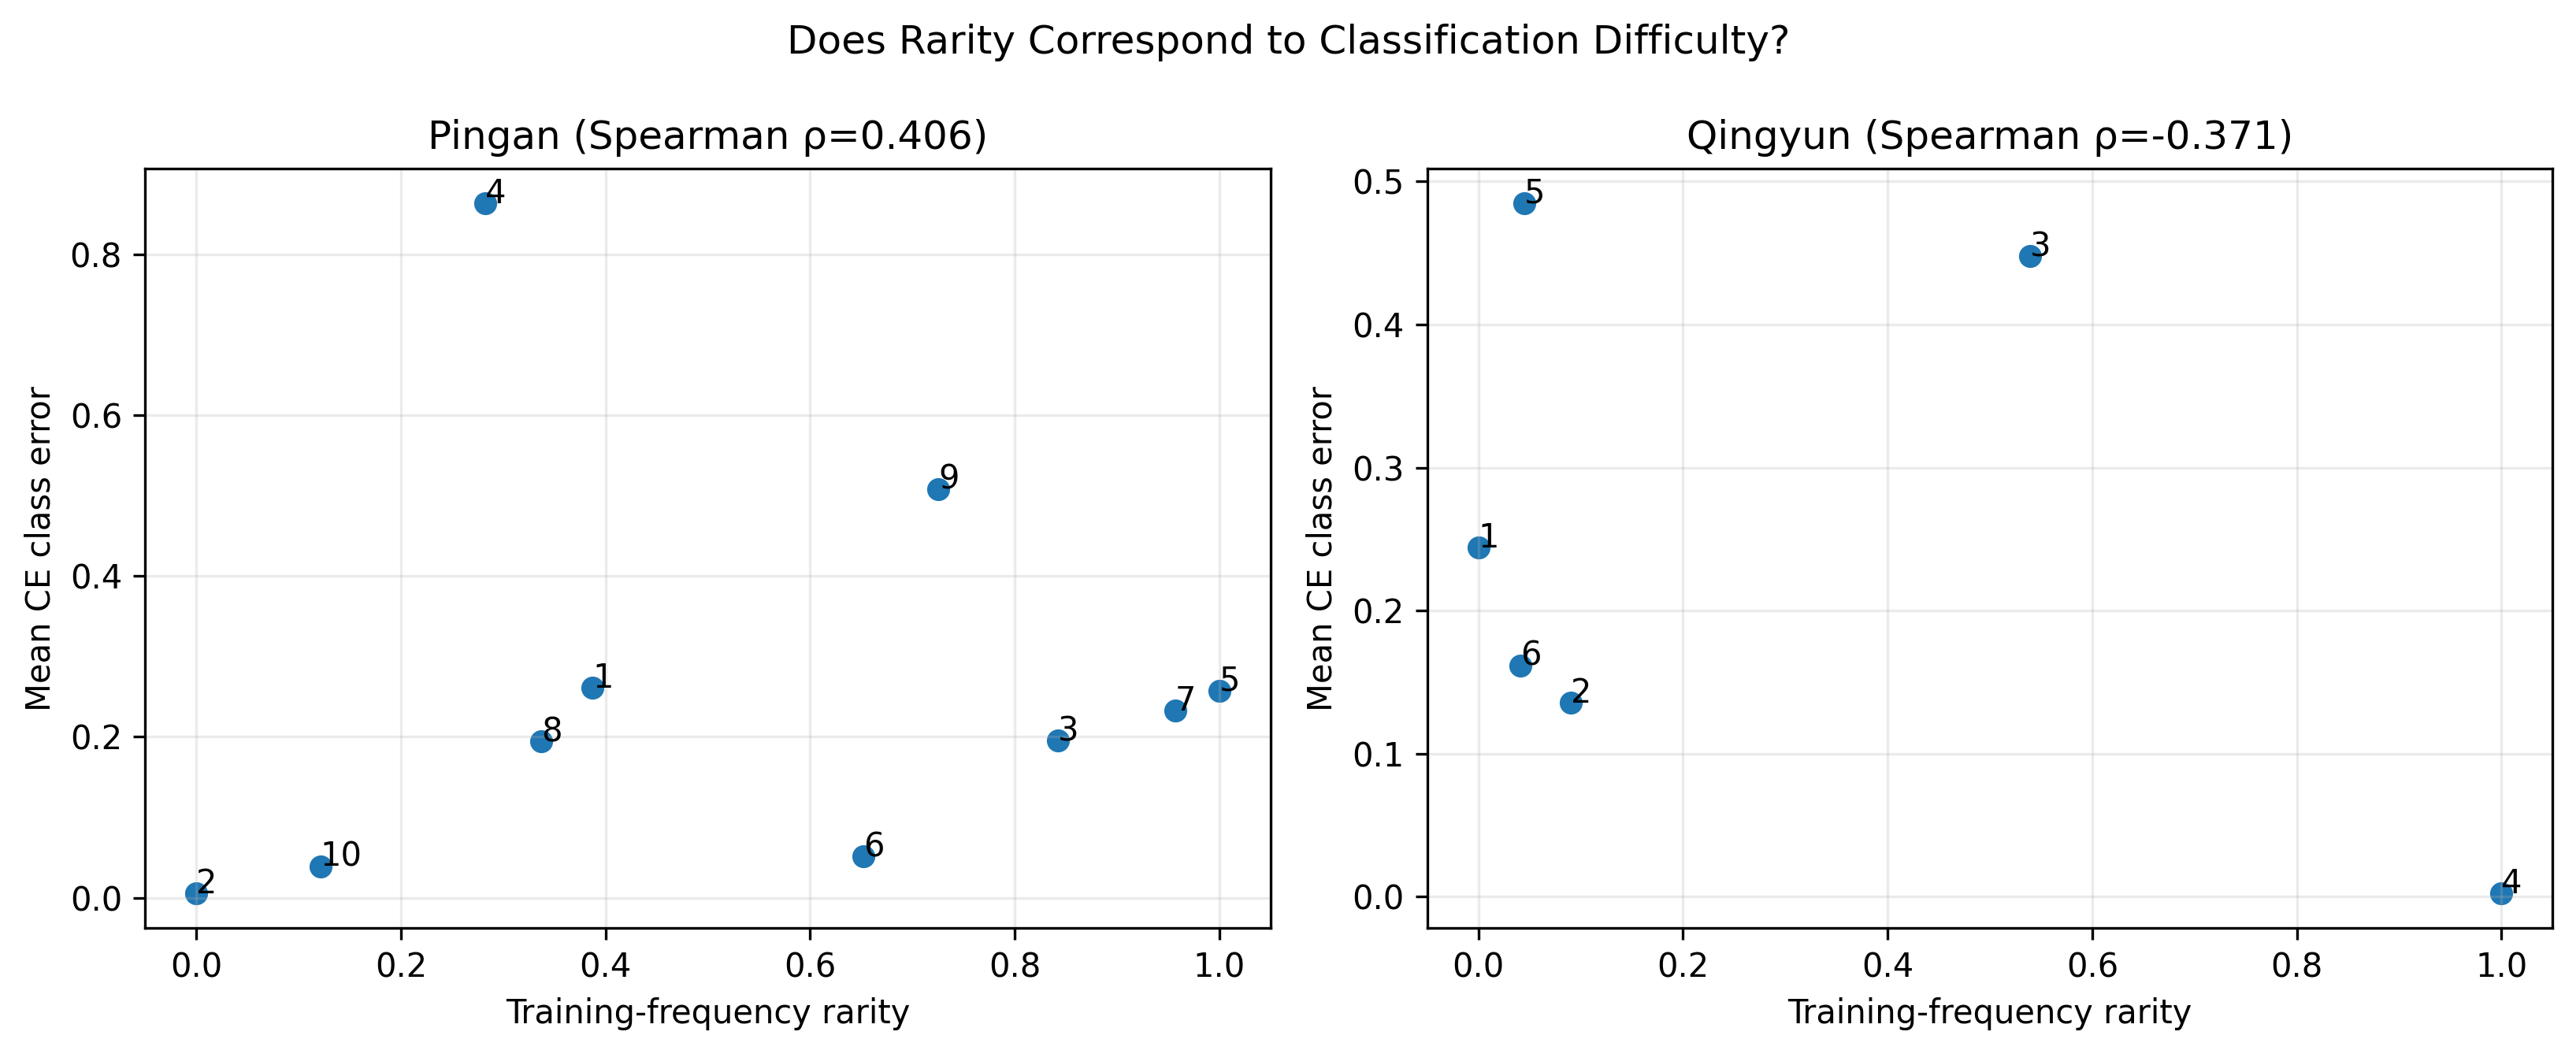

## Figure N2 — Rarity vs Adaptive LTLC Gain

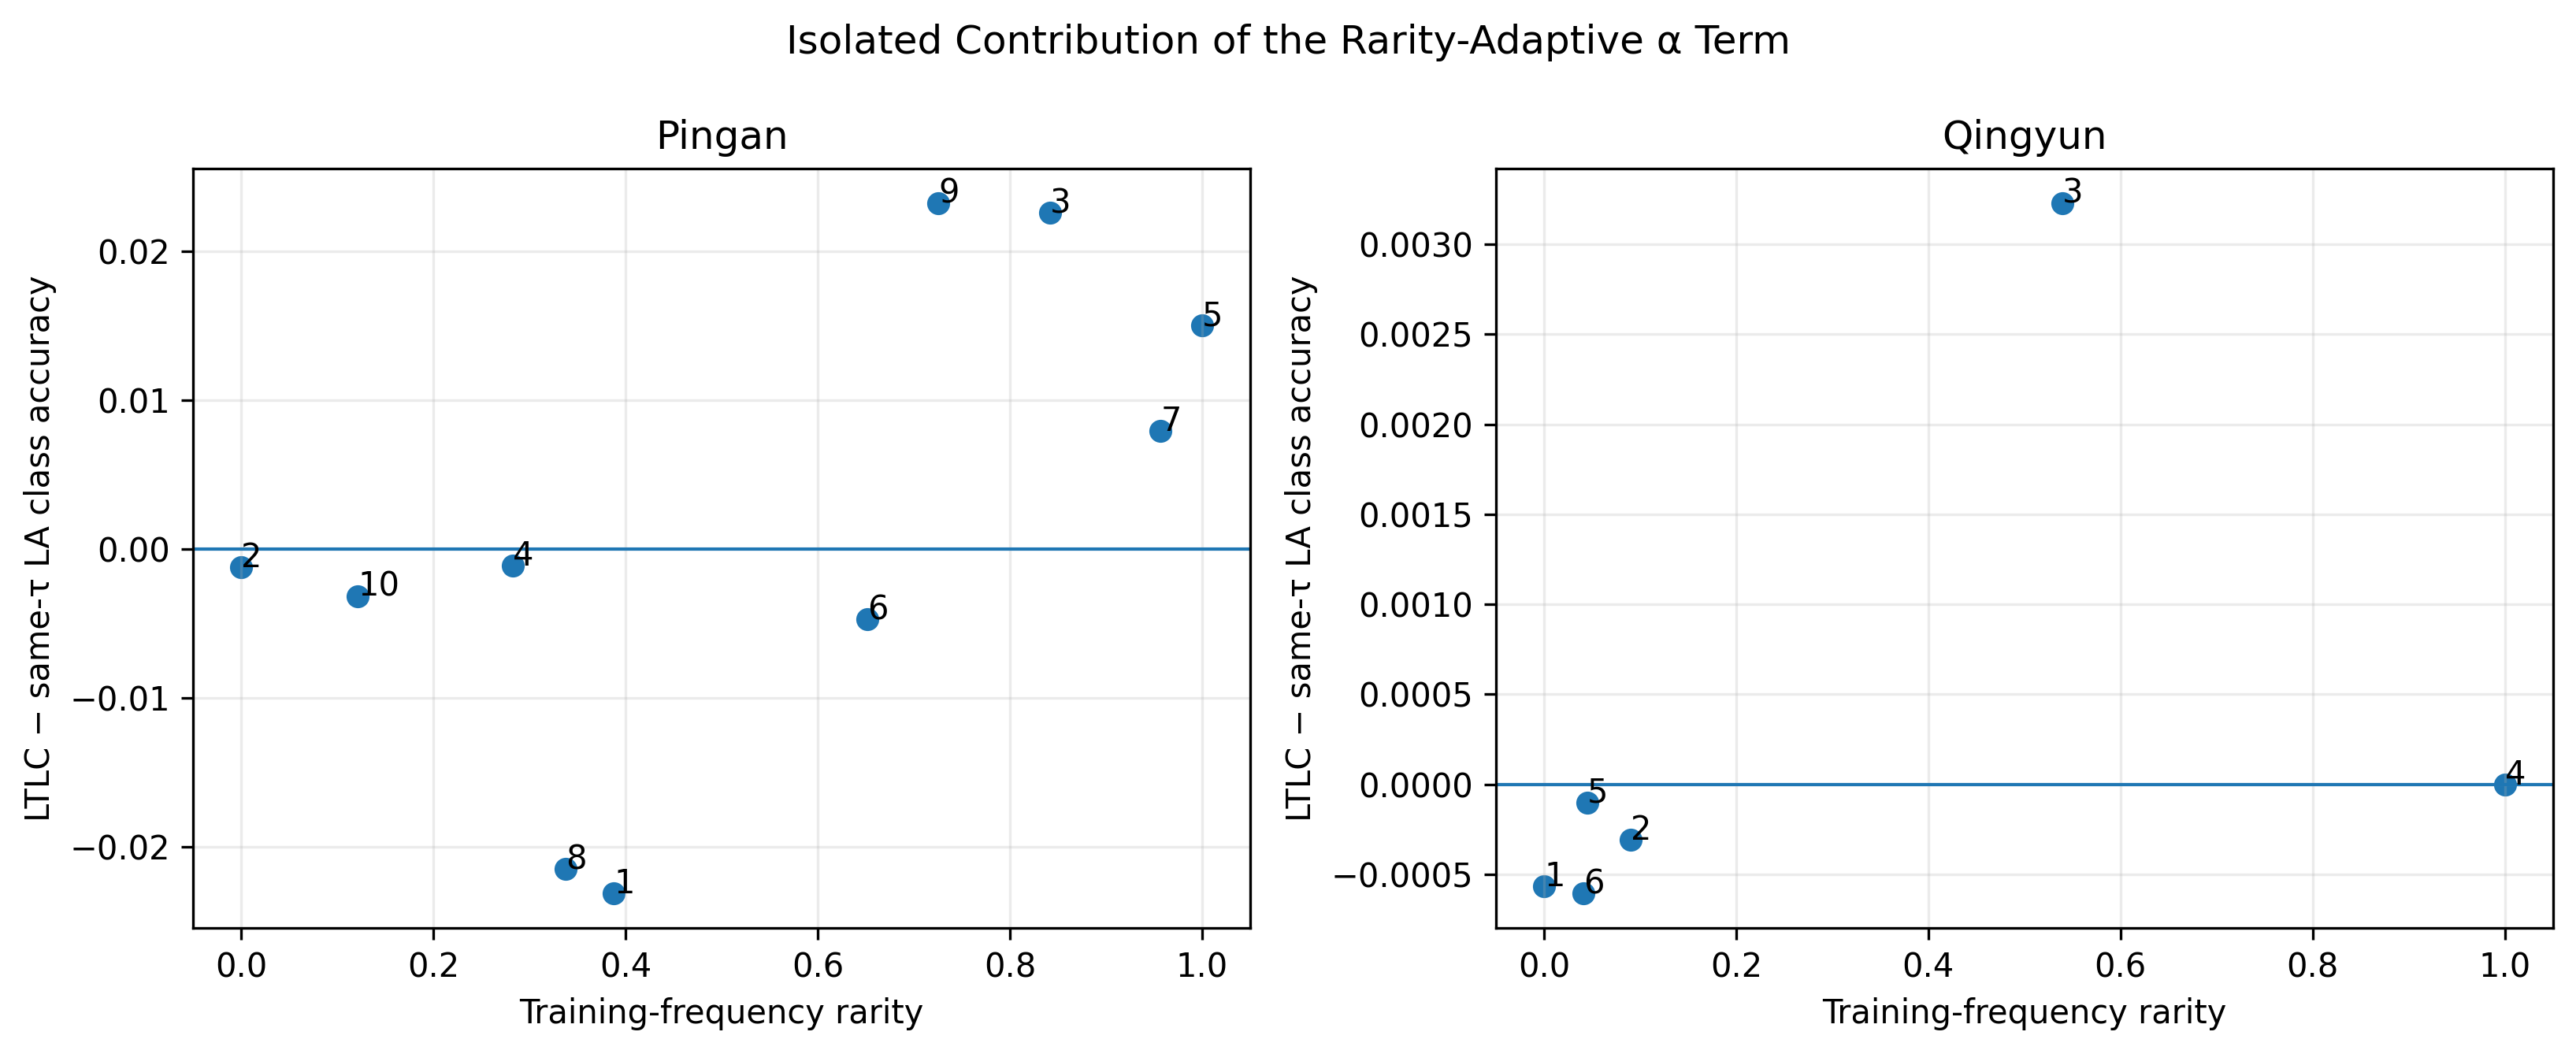

## Figure N3 — LTLC Parameter Landscape

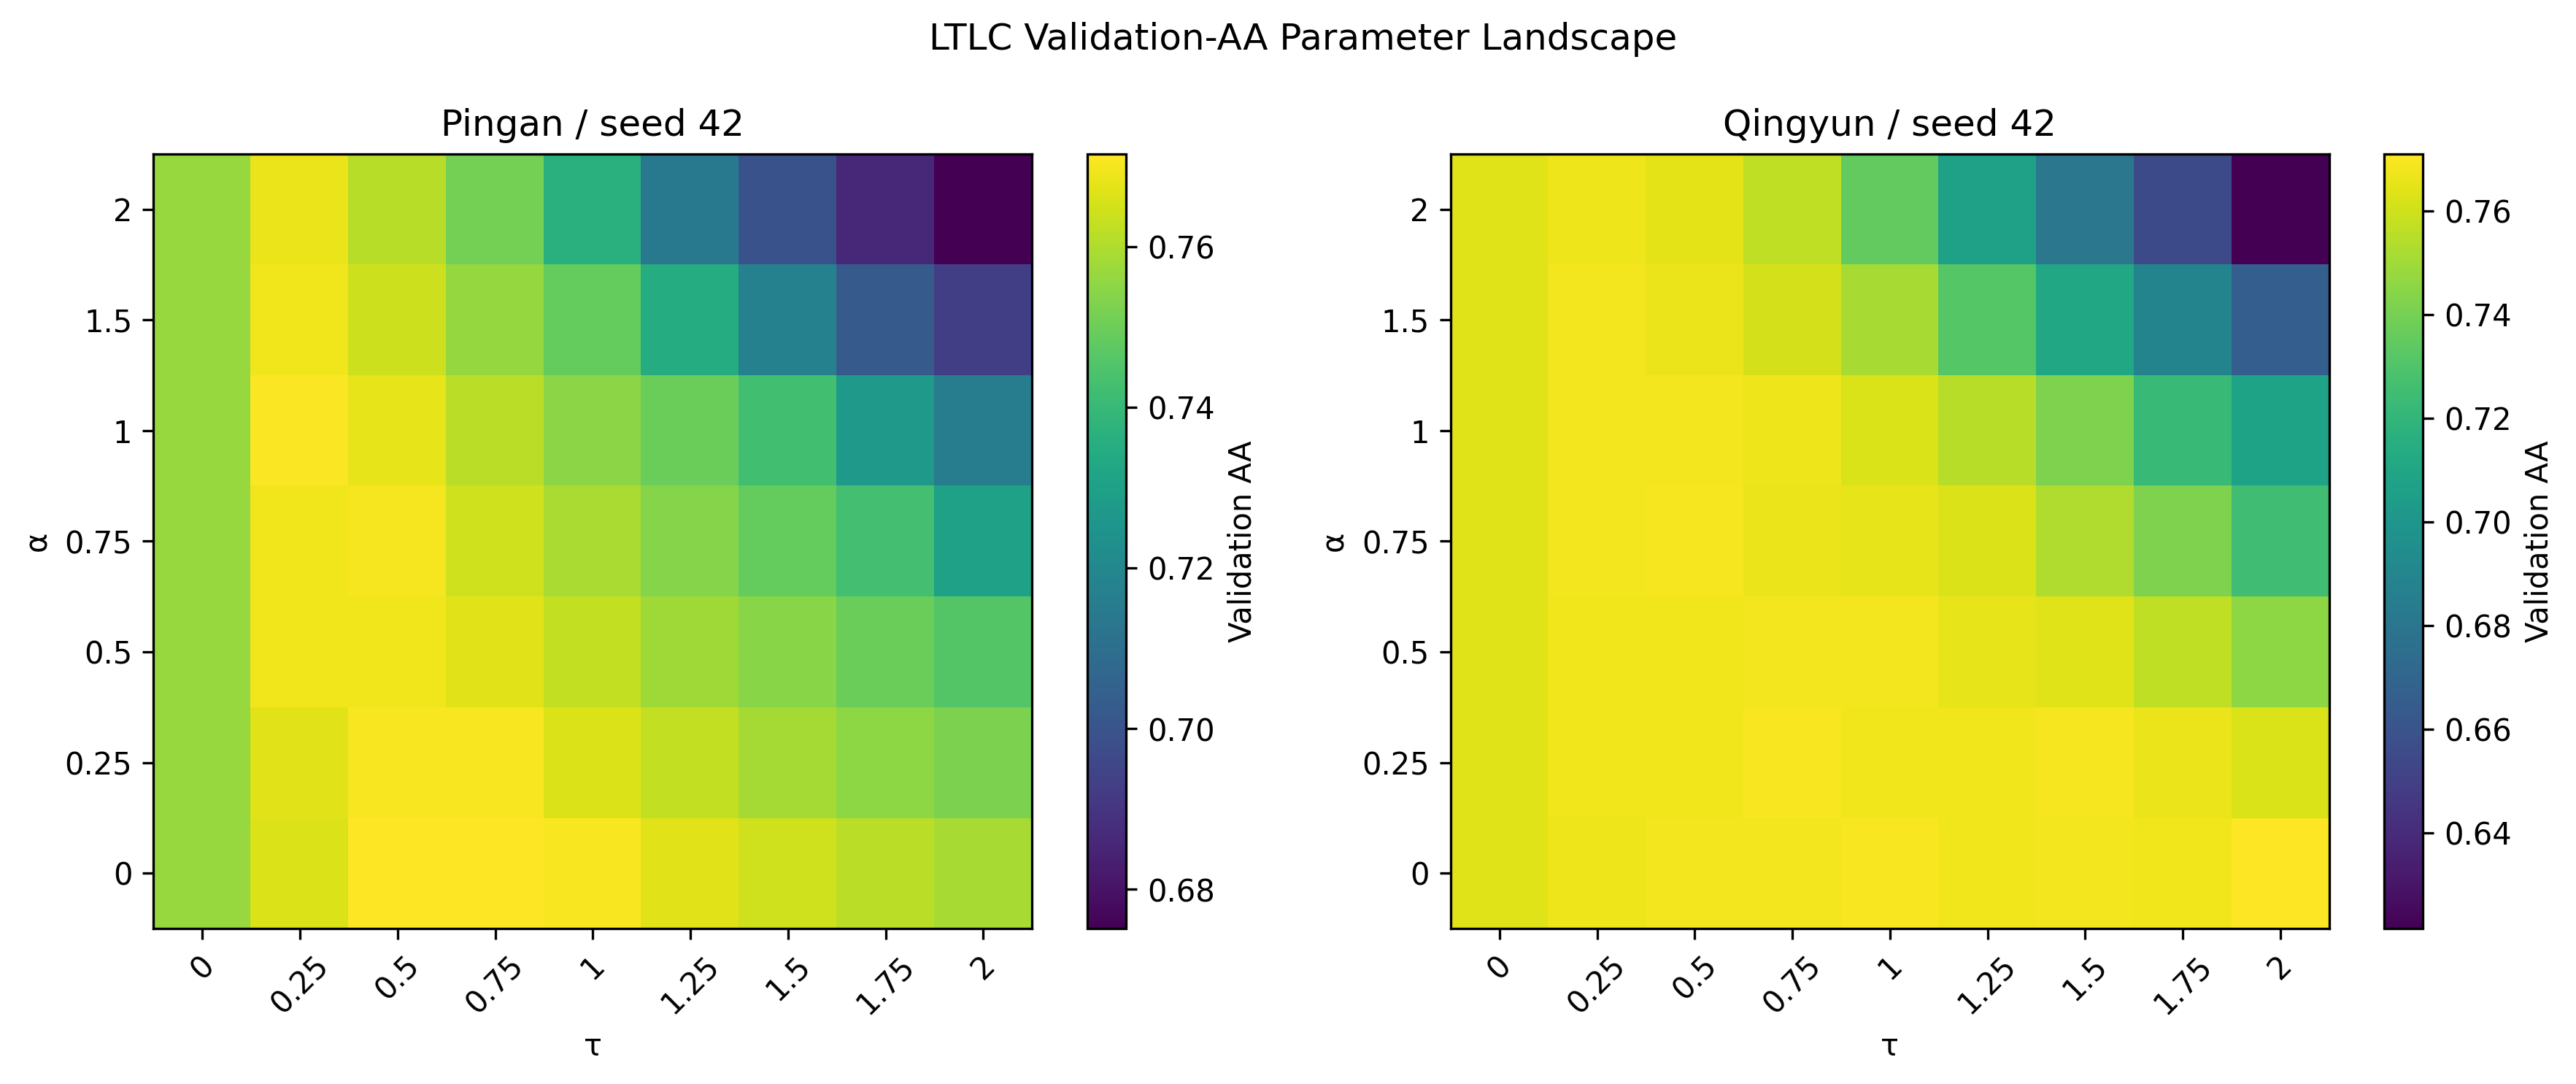

## Figure N4 — R1 Beta Profile

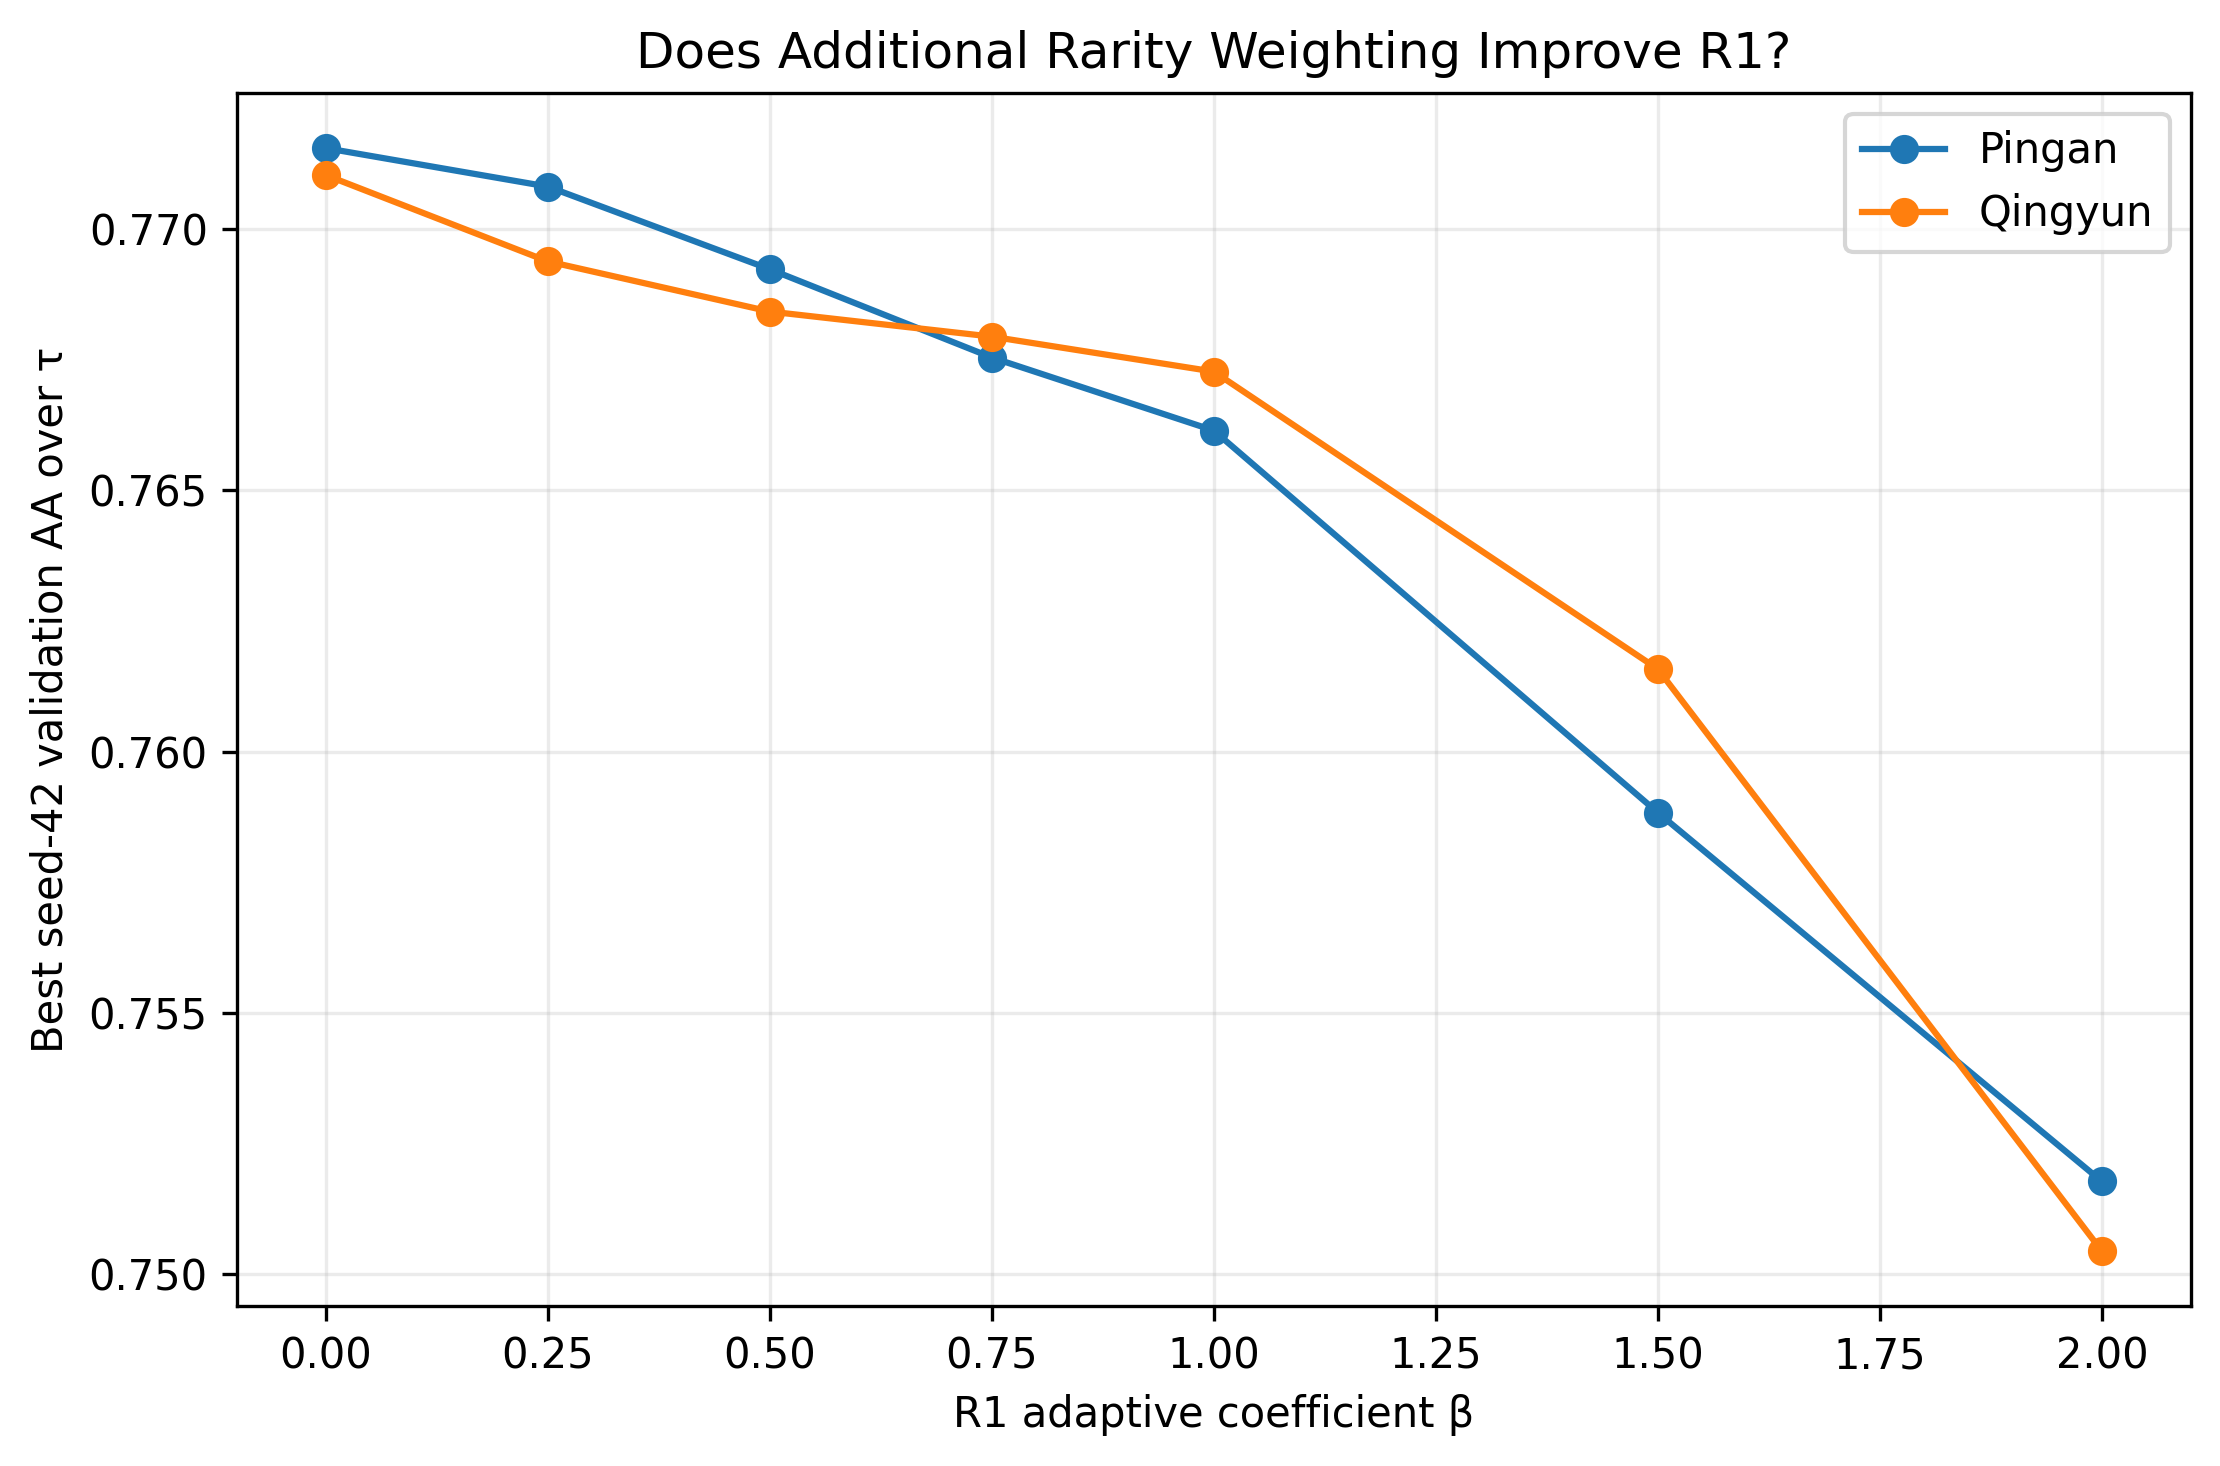

## Figure N5 — Calibration NLL vs Tail-ECE

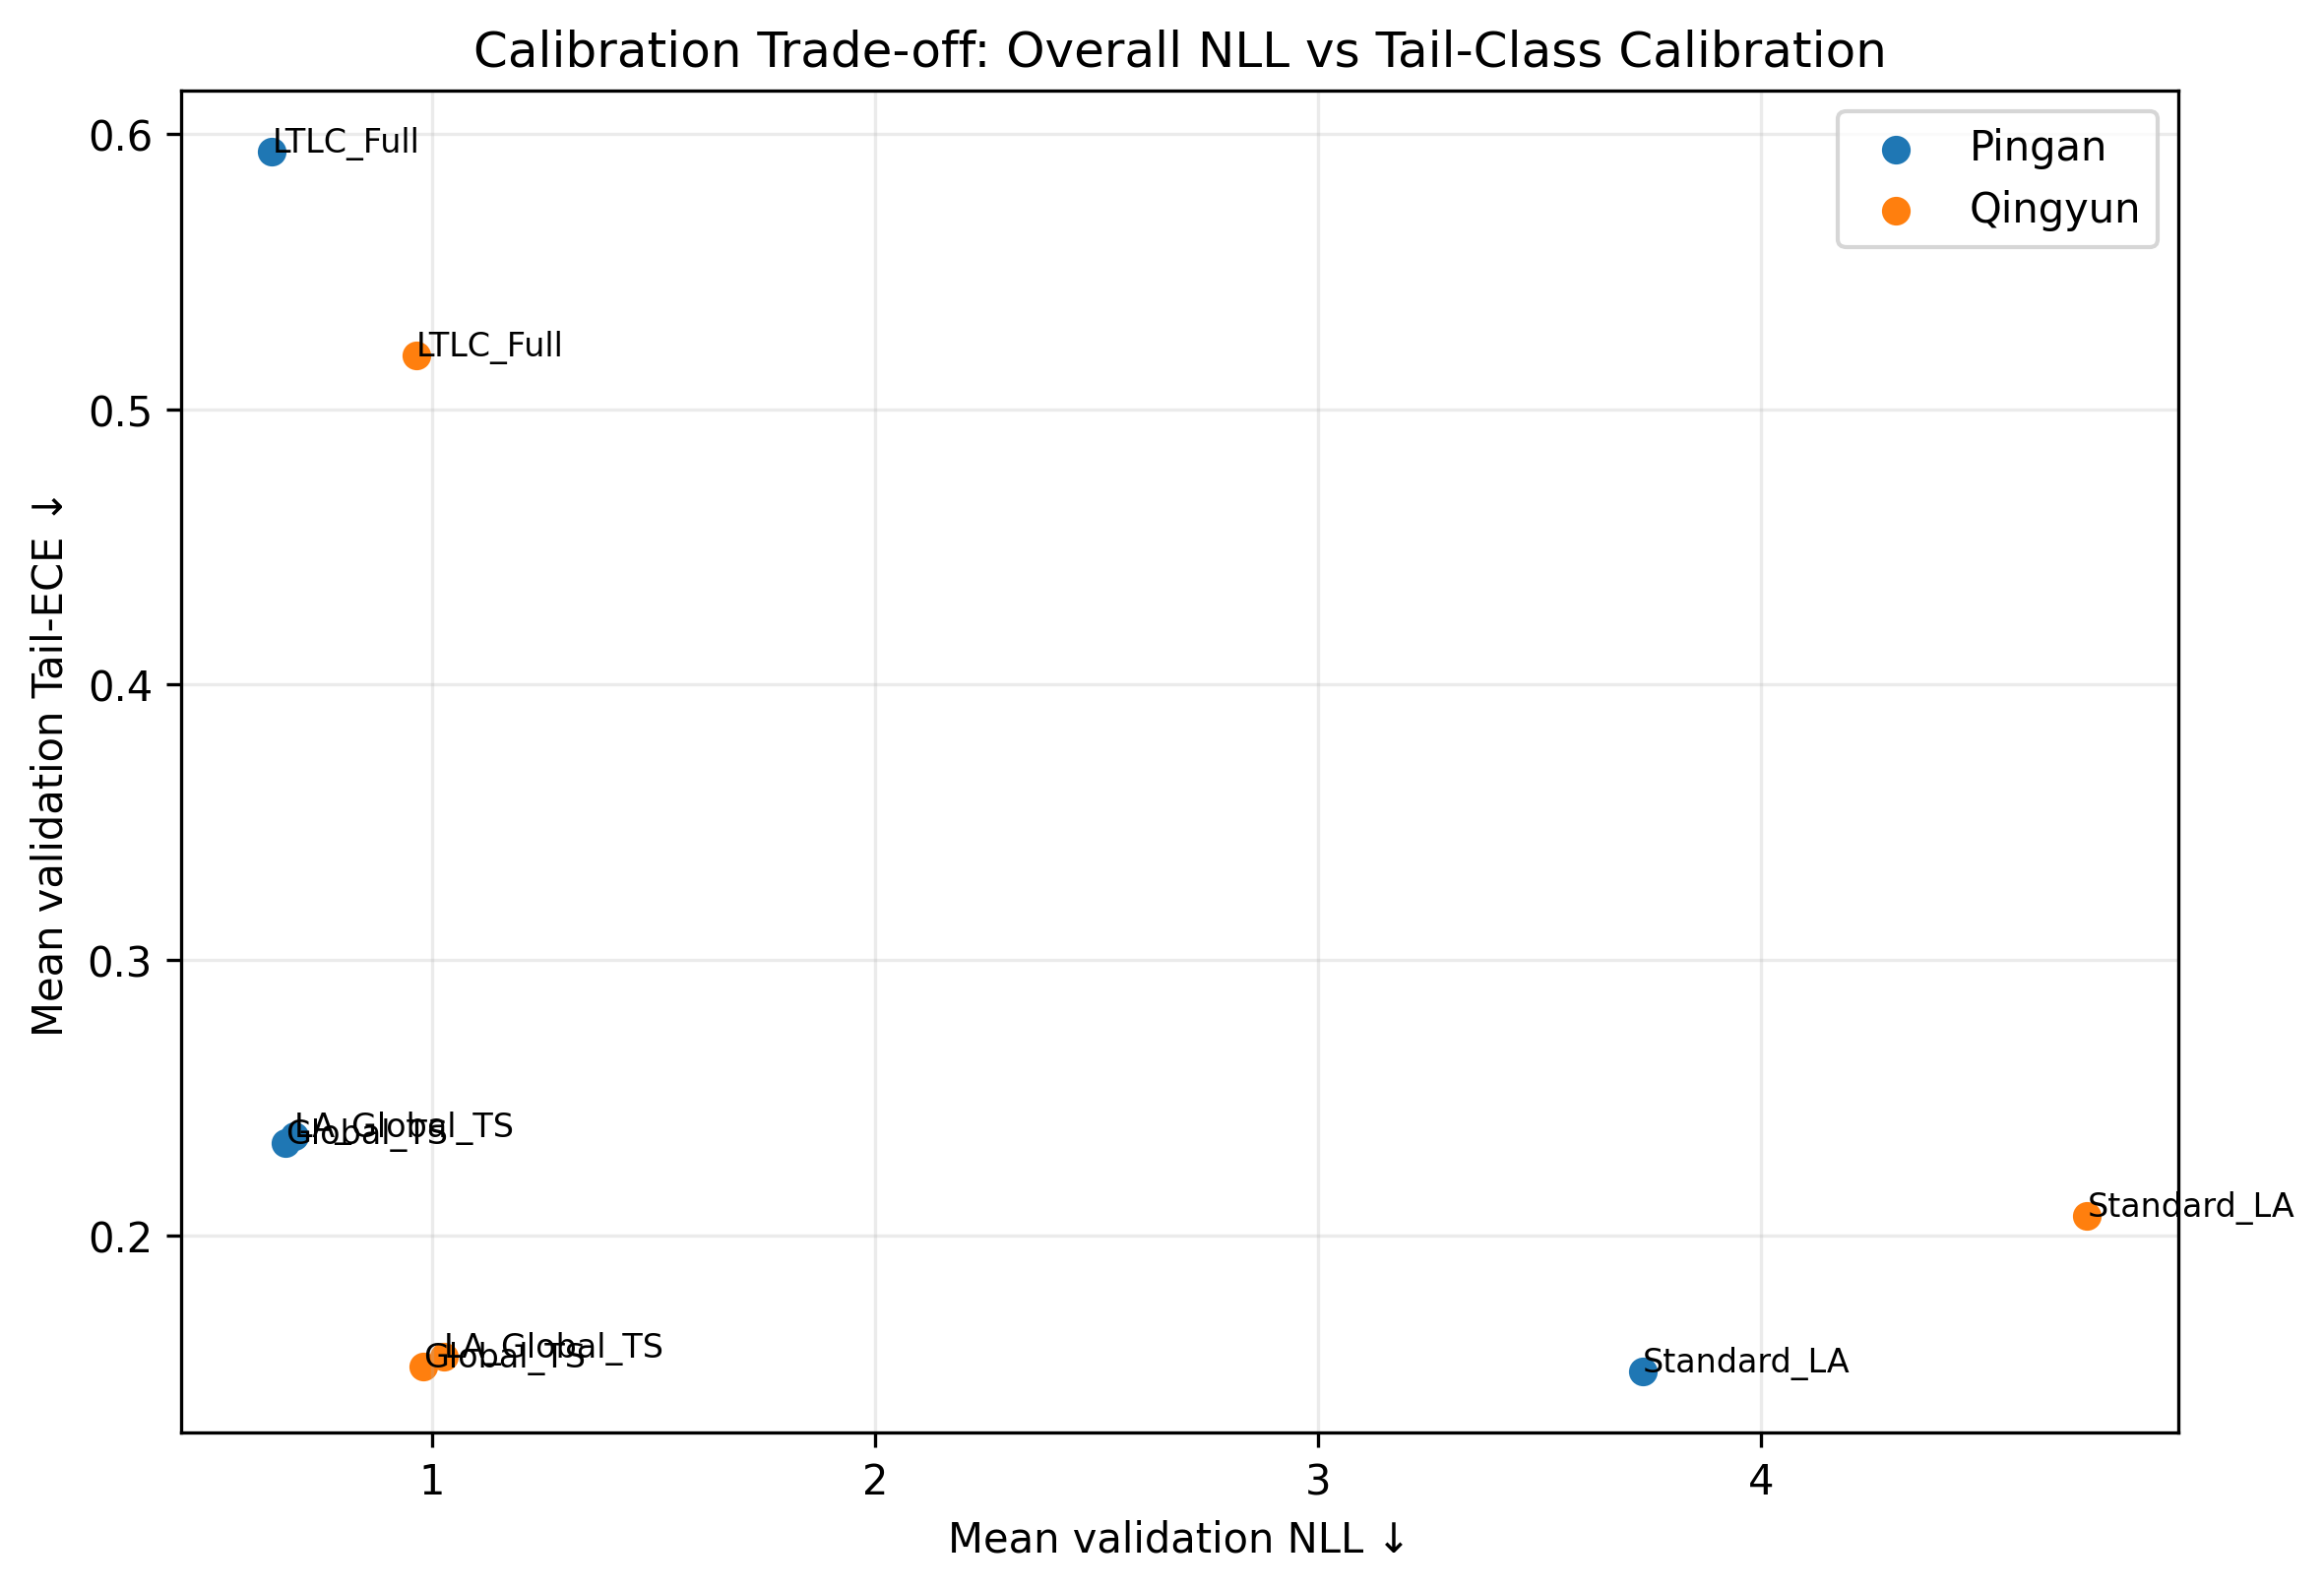

FINAL THESIS FIGURES DISPLAYED: 5/5
Scientific artifacts modified: False


In [4]:
# ==================================================================================================
# LTLC NOTEBOOK 06B — VISUALIZATION-ONLY CELL
# DISPLAY ALL FINAL THESIS FIGURES
#
# NO COMPUTATION
# NO FITTING
# NO INFERENCE
# NO SCIENTIFIC ARTIFACT MODIFICATION
# ==================================================================================================

from pathlib import Path
from IPython.display import display, Image, Markdown

FIG_DIR = Path(
    "/content/drive/MyDrive/CSE498/LTLC/results/"
    "notebook06b_experiment_b_thesis_ready_v2"
)

FIGURES = [
    (
        "Figure N1 — Rarity vs CE Difficulty",
        "Fig_N1_Rarity_vs_CE_Difficulty_v2.png",
    ),
    (
        "Figure N2 — Rarity vs Adaptive LTLC Gain",
        "Fig_N2_Rarity_vs_Adaptive_LTLC_Gain_v2.png",
    ),
    (
        "Figure N3 — LTLC Parameter Landscape",
        "Fig_N3_LTLC_Seed42_Parameter_Landscape_v2.png",
    ),
    (
        "Figure N4 — R1 Beta Profile",
        "Fig_N4_R1_Beta_Profile_v2.png",
    ),
    (
        "Figure N5 — Calibration NLL vs Tail-ECE",
        "Fig_N5_Calibration_NLL_vs_TailECE_v2.png",
    ),
]

print("=" * 120)
print("LTLC NOTEBOOK 06B — FINAL THESIS FIGURE VIEWER")
print("=" * 120)

for title, filename in FIGURES:

    path = FIG_DIR / filename

    if not path.is_file():
        raise FileNotFoundError(f"Missing figure: {path}")

    display(Markdown(f"## {title}"))
    display(Image(filename=str(path), width=950))

print("=" * 120)
print("FINAL THESIS FIGURES DISPLAYED: 5/5")
print("Scientific artifacts modified: False")
print("=" * 120)